# EDA — `player_appearance_shot_limited.csv`

This notebook performs an exploratory data analysis of the shot-event table
provided for the WEC 2026 challenge. The table contains every shot attempt
recorded across the UEFA U-21 European Championship 2025 matches, with the
`outcome` column intentionally removed to prevent target-variable leakage.

The EDA is organised into eight sections; this notebook currently implements:

* **Section A — Structural integrity** (this revision)
* Sections B–H will be appended as the analysis progresses.

Each section is a self-contained sequence of *(motivation → check → finding)*
triples. Code cells are designed to be re-run in order from a clean kernel.


## Setup

Imports, display options and constants are isolated in dedicated cells so the
notebook can be re-executed deterministically and the configuration surface
remains explicit.


In [1]:
"""Standard library and third-party imports used throughout the notebook."""
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd


In [2]:
"""Display configuration — keeps wide tables readable inside JupyterLab."""
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)
pd.set_option("display.precision", 4)


In [3]:
"""Project paths.

`PROJECT_ROOT` is resolved from the notebook's working directory rather than
its file location, because Jupyter does not expose `__file__`. Anchoring on
the `data/` sibling folder keeps the path robust regardless of where the
kernel is launched from.
"""
PROJECT_ROOT: Path = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
DATA_DIR: Path = PROJECT_ROOT / "data"
SHOTS_PATH: Path = DATA_DIR / "player_appearance_shot_limited.csv"

assert SHOTS_PATH.exists(), f"Expected shots file at {SHOTS_PATH}"


In [4]:
"""Load the shot-event table once. All later cells reuse `shots`."""
shots: pd.DataFrame = pd.read_csv(SHOTS_PATH)
shots.shape


(780, 12)

In [5]:
"""Load the main player-quarter panel.

`main` is needed from Section D onwards to join shooter context (position,
player_id, fixture_id) onto the event-level shot table. We load it once in
setup to keep later cells self-contained.
"""
MAIN_PATH: Path = DATA_DIR / "players_quarters_final.csv"
assert MAIN_PATH.exists(), f"Expected main file at {MAIN_PATH}"

main: pd.DataFrame = pd.read_csv(MAIN_PATH)

# `appearance_meta` is the deduplicated per-appearance lookup table — one row
# per `player_appearance_id` with the (immutable within an appearance) keys we
# need for joins and stratifications throughout the notebook.
appearance_meta: pd.DataFrame = (
    main[["player_appearance_id", "player_id", "fixture_id", "position", "is_home"]]
    .drop_duplicates(subset="player_appearance_id")
    .set_index("player_appearance_id")
)
appearance_meta.shape


(869, 4)

In [6]:
"""Reusable helpers — kept thin and side-effect-free."""


def section_header(title: str) -> None:
    """Print a visually distinct section header to separate cell outputs."""
    bar = "=" * 70
    print(f"\n{bar}\n{title}\n{bar}")


def describe_missing(df: pd.DataFrame, columns: Iterable[str] | None = None) -> pd.DataFrame:
    """Return a tidy missing-value summary for the given columns.

    Parameters
    ----------
    df
        Source data frame.
    columns
        Optional subset of columns. Defaults to all columns.

    Returns
    -------
    pandas.DataFrame
        One row per column with absolute and relative missing counts,
        sorted descending by absolute count.
    """
    cols = list(columns) if columns is not None else df.columns.tolist()
    n_missing = df[cols].isna().sum()
    pct_missing = n_missing / len(df)
    summary = pd.DataFrame({"n_missing": n_missing, "pct_missing": pct_missing})
    return summary.sort_values("n_missing", ascending=False)


def crosstab_with_rates(
    df: pd.DataFrame,
    row: str,
    col: str,
    *,
    normalize: str = "index",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return absolute counts and a normalised cross-tabulation.

    Parameters
    ----------
    df
        Source data frame.
    row, col
        Column names to cross-tabulate.
    normalize
        Passed through to :func:`pandas.crosstab`. The default ``"index"``
        produces row-conditional rates (each row sums to 1.0), which is the
        most useful framing when the goal is *"given category X in `row`,
        what is the distribution over `col`?"*.

    Returns
    -------
    counts, rates
        Two data frames with identical shape; ``rates`` rows sum to 1.0
        when ``normalize="index"``.
    """
    counts = pd.crosstab(df[row], df[col])
    rates = pd.crosstab(df[row], df[col], normalize=normalize)
    return counts, rates


def wilson_ci(successes: int, trials: int, alpha: float = 0.05) -> tuple[float, float]:
    """Two-sided Wilson score interval for a binomial proportion.

    Wilson is preferred over the normal approximation for sparse / extreme
    proportions, which we have plenty of (target rate ≈ 5.8 %, plus zero
    counts inside several bins).

    Returns ``(nan, nan)`` when ``trials == 0``.
    """
    from scipy import stats as _stats

    if trials == 0:
        return float("nan"), float("nan")
    p = successes / trials
    z = _stats.norm.ppf(1.0 - alpha / 2.0)
    denom = 1.0 + (z ** 2) / trials
    centre = (p + (z ** 2) / (2.0 * trials)) / denom
    half = z * np.sqrt(p * (1.0 - p) / trials + (z ** 2) / (4.0 * trials ** 2)) / denom
    return float(centre - half), float(centre + half)


def conditional_rate_table(
    df: pd.DataFrame,
    feature: str,
    target: str,
    *,
    bins: list[int | float] | None = None,
    bin_labels: list[str] | None = None,
    by: str | None = None,
) -> pd.DataFrame:
    """Compute target rate per (optionally stratified) feature bin with Wilson CIs.

    Parameters
    ----------
    df
        Input data frame.
    feature
        Name of the feature column to bin.
    target
        Name of the binary target column.
    bins
        ``pd.cut`` bin edges. If ``None``, the feature is treated as already
        categorical / discrete and grouped on its raw values.
    bin_labels
        Optional labels for the bins (must match `len(bins) - 1`).
    by
        Optional stratifier (e.g. ``"position"``); the result is then
        produced as one row per (stratum, bin) pair.

    Returns
    -------
    pandas.DataFrame
        Columns: ``[<by>], bin, n, n_pos, rate, ci_lo, ci_hi``.
    """
    work = df[[feature, target] + ([by] if by else [])].copy()
    if bins is not None:
        work["__bin"] = pd.cut(work[feature], bins=bins, labels=bin_labels, include_lowest=True)
    else:
        work["__bin"] = work[feature]

    grouping = ["__bin"] if by is None else [by, "__bin"]
    grouped = work.groupby(grouping, observed=False, dropna=False)[target].agg(["size", "sum"])
    grouped = grouped.rename(columns={"size": "n", "sum": "n_pos"}).reset_index()
    grouped["rate"] = grouped["n_pos"] / grouped["n"].where(grouped["n"] > 0)
    ci = grouped.apply(lambda r: wilson_ci(int(r["n_pos"]), int(r["n"])), axis=1, result_type="expand")
    grouped["ci_lo"] = ci[0]
    grouped["ci_hi"] = ci[1]
    grouped = grouped.rename(columns={"__bin": "bin"})
    return grouped


def categorical_distribution(
    series: pd.Series,
    *,
    dropna: bool = False,
    sort: str = "count",
) -> pd.DataFrame:
    """Return absolute and relative frequencies of a categorical series.

    Parameters
    ----------
    series
        Categorical (or coercible) input series.
    dropna
        If ``True`` ``NaN`` values are excluded from both the counts and the
        percentage denominator.
    sort
        ``"count"`` (default) sorts descending by frequency; ``"index"`` sorts
        by category label, useful for ordinal categories.

    Returns
    -------
    pandas.DataFrame
        Indexed by category, with columns ``n`` (count) and ``pct`` (share of
        the kept rows).
    """
    counts = series.value_counts(dropna=dropna)
    total = counts.sum()
    out = pd.DataFrame({"n": counts, "pct": counts / total})
    return out.sort_index() if sort == "index" else out


## Target variable — `scored_after` distribution

Before any feature analysis, we visualise the target. `scored_after` is a
binary indicator at the (`player_appearance_id`, `checkpoint`) level: 1 if
the player scores ≥ 1 non-own goal **after** that checkpoint in the same
match, 0 otherwise.

Three views are useful as the orienting reference for everything below:

* **Overall class balance** — confirms the imbalance the rest of the
  notebook has to work around.
* **Rate by `position`** — the strongest single stratifier (D2).
  Goalkeepers are deterministic zeros, attackers are the highest-rate
  group.
* **Rate by `checkpoint`** — leakage-safe time view (we use this in F7c
  to motivate `match_minute_at_cp` over the leaky `minutes_remaining`).
* **Heatmap of `position × checkpoint`** — combines both axes; cells
  with small samples (e.g. ET1_15) are visible as low-contrast blobs.



Target variable — scored_after distribution


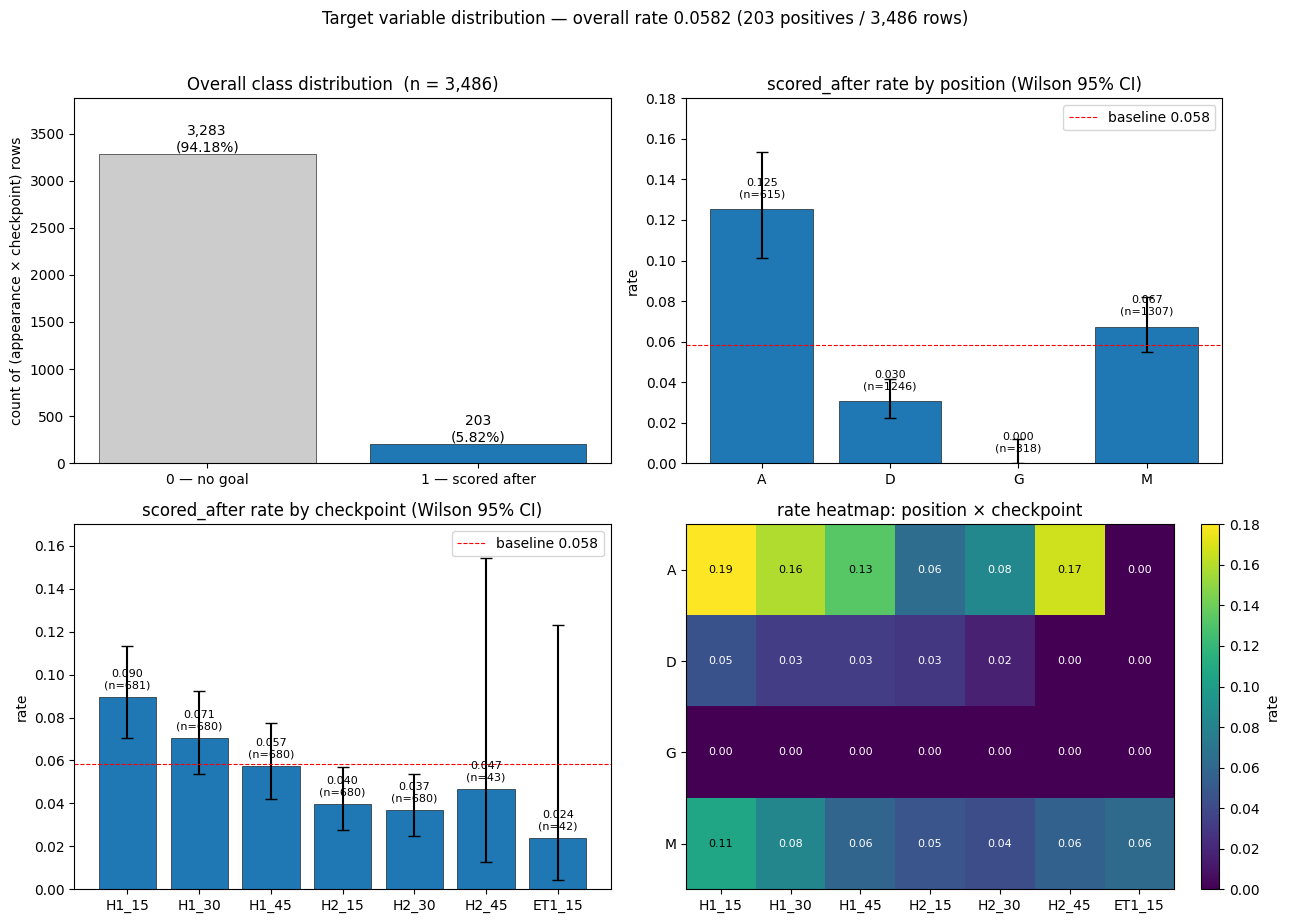

In [7]:
section_header("Target variable — scored_after distribution")

import matplotlib.pyplot as plt

CHECKPOINT_ORDER: list[str] = [
    "H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"
]
baseline_rate: float = float(main["scored_after"].mean())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- (0,0) overall class balance --------------------------------------
ax = axes[0, 0]
counts = main["scored_after"].value_counts().sort_index()
pcts = counts / counts.sum() * 100.0
bars = ax.bar(["0 — no goal", "1 — scored after"], counts.values,
              color=["#cccccc", "#1f77b4"], edgecolor="black", linewidth=0.4)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
            f"{count:,}\n({pct:.2f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("count of (appearance × checkpoint) rows")
ax.set_title(f"Overall class distribution  (n = {len(main):,})")
ax.set_ylim(0, max(counts.values) * 1.18)

# --- (0,1) rate by position with Wilson CIs ---------------------------
ax = axes[0, 1]
pos_rates = main.groupby("position")["scored_after"].agg(size="size", positives="sum",
                                                         rate="mean")
pos_rates[["ci_lo", "ci_hi"]] = pos_rates.apply(
    lambda r: pd.Series(wilson_ci(int(r["positives"]), int(r["size"]))),
    axis=1,
)
ax.bar(pos_rates.index, pos_rates["rate"],
       yerr=[pos_rates["rate"] - pos_rates["ci_lo"],
             pos_rates["ci_hi"] - pos_rates["rate"]],
       capsize=4, color="#1f77b4", edgecolor="black", linewidth=0.4)
ax.axhline(baseline_rate, color="red", linestyle="--", linewidth=0.8,
           label=f"baseline {baseline_rate:.3f}")
for x, (pos, row) in enumerate(pos_rates.iterrows()):
    ax.text(x, row["rate"] + 0.005, f"{row['rate']:.3f}\n(n={int(row['size'])})",
            ha="center", va="bottom", fontsize=8)
ax.set_title("scored_after rate by position (Wilson 95% CI)")
ax.set_ylabel("rate")
ax.set_ylim(0, max(0.18, pos_rates["ci_hi"].max() * 1.1))
ax.legend(loc="upper right")

# --- (1,0) rate by checkpoint with Wilson CIs -------------------------
ax = axes[1, 0]
cp_rates = main.groupby("checkpoint")["scored_after"].agg(size="size", positives="sum",
                                                          rate="mean")
cp_rates = cp_rates.reindex(CHECKPOINT_ORDER)
cp_rates[["ci_lo", "ci_hi"]] = cp_rates.apply(
    lambda r: pd.Series(wilson_ci(int(r["positives"]), int(r["size"]))),
    axis=1,
)
ax.bar(cp_rates.index, cp_rates["rate"],
       yerr=[cp_rates["rate"] - cp_rates["ci_lo"],
             cp_rates["ci_hi"] - cp_rates["rate"]],
       capsize=4, color="#1f77b4", edgecolor="black", linewidth=0.4)
ax.axhline(baseline_rate, color="red", linestyle="--", linewidth=0.8,
           label=f"baseline {baseline_rate:.3f}")
for x, (cp, row) in enumerate(cp_rates.iterrows()):
    ax.text(x, row["rate"] + 0.003, f"{row['rate']:.3f}\n(n={int(row['size'])})",
            ha="center", va="bottom", fontsize=8)
ax.set_title("scored_after rate by checkpoint (Wilson 95% CI)")
ax.set_ylabel("rate")
ax.set_ylim(0, max(0.13, cp_rates["ci_hi"].max() * 1.1))
ax.legend(loc="upper right")

# --- (1,1) heatmap rate by position × checkpoint ----------------------
ax = axes[1, 1]
heat = main.pivot_table(values="scored_after", index="position",
                        columns="checkpoint", aggfunc="mean")
heat = heat.reindex(columns=CHECKPOINT_ORDER)
im = ax.imshow(heat.values, cmap="viridis", aspect="auto", vmin=0, vmax=0.18)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v < 0.09 else "black")
fig.colorbar(im, ax=ax, fraction=0.04, label="rate")
ax.set_title("rate heatmap: position × checkpoint")

fig.suptitle(
    f"Target variable distribution — overall rate {baseline_rate:.4f} "
    f"({int(main['scored_after'].sum())} positives / {len(main):,} rows)",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Section A — Structural integrity

Before any substantive analysis we verify that the table conforms to the
schema documented in `WEC2026_data_description.pdf` and surfaces no hidden
data-quality issues. Six checks are performed:

| ID | Check |
|----|-------|
| A1 | Shape, dtypes, head/tail |
| A2 | Primary-key uniqueness on `id` |
| A3 | Missingness pattern of outcome-leaking foreign keys |
| A4 | Missingness on remaining columns |
| A5 | Domain checks on `period` and `minute` |
| A6 | Encoding of stoppage-time minutes (`minute > period_cap`) |

Each check is documented with its motivation (*why this matters for later
modelling*) and its outcome.


### A1 — Shape, dtypes, head/tail

The data dictionary specifies 780 rows × 12 columns. Confirming this is the
cheapest possible sanity check against silent ingestion errors (wrong
delimiter, double-loaded file, etc.). We also inspect dtypes so that any
unexpected `object`-coerced numeric column would surface immediately.


In [8]:
section_header("A1. Shape, dtypes, head/tail")
print(f"shape = {shots.shape}")
print("\ndtypes:")
print(shots.dtypes.to_string())
print("\nhead(5):")
print(shots.head().to_string())
print("\ntail(5):")
print(shots.tail().to_string())



A1. Shape, dtypes, head/tail
shape = (780, 12)

dtypes:
id                                 int64
period                               str
player_appearance_id               int64
body_part                            str
technique                            str
play_pattern                         str
own_goal_player_appearance_id    float64
block_player_appearance_id       float64
minute                             int64
possession                         int64
stage                                str
under_pressure                      bool

head(5):
    id  period  player_appearance_id   body_part technique    play_pattern  own_goal_player_appearance_id  block_player_appearance_id  minute  possession stage  under_pressure
0  143  half_1                 39442  right_foot    normal    regular_play                            NaN                         NaN      11        2285   top           False
1  144  half_1                 39442  right_foot    normal  counter_attack               

### A2 — Primary-key uniqueness on `id`

`id` is documented as the integer primary key of the shot table. Verifying
uniqueness rules out duplicate rows, which would otherwise inflate every
downstream aggregation (shots-per-player, shots-per-possession, etc.).


In [9]:
section_header("A2. Primary-key uniqueness on `id`")
n_rows: int = len(shots)
n_unique: int = shots["id"].nunique()
n_null: int = int(shots["id"].isna().sum())

print(f"unique ids    : {n_unique}")
print(f"rows          : {n_rows}")
print(f"duplicate ids : {n_rows - n_unique}")
print(f"id null count : {n_null}")

assert n_unique == n_rows and n_null == 0, "`id` failed primary-key invariants."



A2. Primary-key uniqueness on `id`
unique ids    : 780
rows          : 780
duplicate ids : 0
id null count : 0


### A3 — Missingness pattern of outcome-leaking foreign keys

`own_goal_player_appearance_id` and `block_player_appearance_id` are documented
as non-null **only** for own-goal and blocked-shot events respectively. Both
are therefore *post-outcome labels* and must never be used as model features
or in any feature derivation; doing so would leak target information.

Here we (a) quantify their non-null rates, (b) confirm they are mutually
exclusive within a row, and (c) inspect the rare own-goal record(s).


In [10]:
section_header("A3. Outcome-leaking columns")
own_goal_mask = shots["own_goal_player_appearance_id"].notna()
blocked_mask = shots["block_player_appearance_id"].notna()

print(
    f"own_goal_player_appearance_id non-null : {own_goal_mask.sum():4d} / {n_rows} "
    f"({own_goal_mask.mean():.4%})"
)
print(
    f"block_player_appearance_id    non-null : {blocked_mask.sum():4d} / {n_rows} "
    f"({blocked_mask.mean():.4%})"
)
print(f"both non-null in same row              : {(own_goal_mask & blocked_mask).sum()}")

print("\nown-goal events:")
print(shots.loc[own_goal_mask].to_string())

print("\nfirst 5 blocked-shot events:")
print(shots.loc[blocked_mask].head().to_string())



A3. Outcome-leaking columns
own_goal_player_appearance_id non-null :    1 / 780 (0.1282%)
block_player_appearance_id    non-null :  215 / 780 (27.5641%)
both non-null in same row              : 0

own-goal events:
       id  period  player_appearance_id   body_part technique  play_pattern  own_goal_player_appearance_id  block_player_appearance_id  minute  possession stage  under_pressure
287  1055  half_2                 41151  right_foot    normal  regular_play                        41169.0                         NaN      15        2362   top            True

first 5 blocked-shot events:
      id  period  player_appearance_id   body_part technique    play_pattern  own_goal_player_appearance_id  block_player_appearance_id  minute  possession stage  under_pressure
1    144  half_1                 39442  right_foot    normal  counter_attack                            NaN                     39422.0      31        2285   top            True
9    152  half_2                 39433  right

### A4 — Missingness on remaining columns

After accounting for the two outcome-leaking foreign keys, every remaining
column should be fully populated. Any unexpected missingness here would
require careful imputation logic before aggregation.


In [11]:
section_header("A4. Missingness on remaining columns")
describe_missing(shots)



A4. Missingness on remaining columns


,n_missing,pct_missing
own_goal_player_appearance_id,779,0.9987
block_player_appearance_id,565,0.7244
id,0,0.0000
period,0,0.0000
body_part,0,0.0000
player_appearance_id,0,0.0000
play_pattern,0,0.0000
technique,0,0.0000
minute,0,0.0000
possession,0,0.0000


### A5 — Domain checks on `period` and `minute`

The `period` column should contain only the four documented labels
(`half_1`, `half_2`, `extra_time_1`, `extra_time_2`). The `minute` column
should be a strictly positive integer with no nulls. Any value outside these
domains would flag a parsing or upstream-pipeline issue.


In [12]:
section_header("A5. Range / domain checks")
ALLOWED_PERIODS: set[str] = {"half_1", "half_2", "extra_time_1", "extra_time_2"}

print("period value counts:")
print(shots["period"].value_counts(dropna=False).to_string())

unexpected_periods = set(shots["period"].unique()) - ALLOWED_PERIODS
print(f"\nunexpected period labels: {unexpected_periods or 'none'}")

minute_min: int = int(shots["minute"].min())
minute_max: int = int(shots["minute"].max())
print(f"\nminute range : [{minute_min}, {minute_max}]")
print(f"minute < 0   : {(shots['minute'] < 0).sum()}")
print(f"minute null  : {shots['minute'].isna().sum()}")



A5. Range / domain checks
period value counts:
period
half_2          437
half_1          330
extra_time_2      7
extra_time_1      6

unexpected period labels: none

minute range : [1, 57]
minute < 0   : 0
minute null  : 0


### A6 — Stoppage-time encoding (`minute > period_cap`)

The data dictionary defines checkpoint windows in *local* minutes within each
period (15, 30, 45 for halves; 15 for extra-time periods). However the raw
`minute` field can exceed those caps when stoppage time is played. Quantifying
how many shots fall in stoppage time matters because:

1. **Replication of `last15_*` (later step)** — the data dictionary does not
   specify whether the window for the `H1_45` checkpoint is the inclusive
   interval `(30, 45]` or the open-ended `(30, +∞)` within `half_1`. The right
   rule must be selected empirically.
2. **Cumulative aggregates** — a shot in stoppage time of `half_1` has no
   `last15_` checkpoint that contains it (it would only appear in `cumul_*`
   from `H2_15` onwards). We log the volume so we can later confirm those
   shots are accounted for in the main-table values.

The canonical caps are 45 for the regulation halves and 15 for each extra-time
period.


In [13]:
section_header("A6. Stoppage-time encoding")
PERIOD_CAPS: dict[str, int] = {
    "half_1": 45,
    "half_2": 45,
    "extra_time_1": 15,
    "extra_time_2": 15,
}

stoppage_rows: list[dict[str, object]] = []
for period, cap in PERIOD_CAPS.items():
    sub = shots.loc[shots["period"] == period]
    over = sub.loc[sub["minute"] > cap]
    stoppage_rows.append(
        {
            "period": period,
            "n": len(sub),
            "max_minute": int(sub["minute"].max()) if len(sub) else np.nan,
            "n_stoppage": len(over),
            "pct_stoppage": (len(over) / len(sub)) if len(sub) else np.nan,
        }
    )

stoppage_summary = pd.DataFrame(stoppage_rows)
print(stoppage_summary.to_string(index=False))

# Display the first few stoppage-time rows for half_2 (largest tail) for
# qualitative inspection of which play patterns generate stoppage shots.
print("\nfirst 10 half_2 stoppage shots:")
print(
    shots.loc[(shots["period"] == "half_2") & (shots["minute"] > 45),
              ["id", "period", "minute", "stage", "play_pattern"]]
         .head(10)
         .to_string(index=False)
)



A6. Stoppage-time encoding
      period   n  max_minute  n_stoppage  pct_stoppage
      half_1 330          48          16        0.0485
      half_2 437          57          54        0.1236
extra_time_1   6          16           1        0.1667
extra_time_2   7          17           4        0.5714

first 10 half_2 stoppage shots:
 id period  minute stage     play_pattern
181 half_2      46   top     regular_play
225 half_2      48   top      corner_kick
228 half_2      46   top     regular_play
250 half_2      48   top     regular_play
252 half_2      49   top     regular_play
253 half_2      50   top     regular_play
257 half_2      46   top   counter_attack
299 half_2      48   top direct_free_kick
321 half_2      46   top     regular_play
322 half_2      47   top     regular_play


### A7 — Data quality deep dive (raw shot table)

Beyond the structural checks in A1-A6, we run three additional data-
quality probes that the structural checks did not surface:

1. **Duplicate `(player_appearance_id, period, minute)` rows.** PK
   uniqueness on `id` rules out exact duplicates, but a single player
   could legitimately have multiple distinct shot rows recorded at the
   same minute (rebound attempts). We quantify how often this happens
   — it matters for any "shots per minute" derivation in F4 / step 3.
2. **Stoppage-minute distribution per period.** A6 confirmed
   `minute > period_cap` exists; this probe shows the per-minute
   distribution of stoppage shots so we can flag any extreme values.
3. **Foreign-key validity.** Both `block_player_appearance_id` and
   `own_goal_player_appearance_id` should reference real player
   appearances — either in the main panel or in the shot table itself
   (the orphan appearances from F1 are valid sources too). Any
   unresolved id would indicate an upstream data-pipeline issue.


In [14]:
section_header("A7a. duplicate (appearance, period, minute) rows")

dup_key: list[str] = ["player_appearance_id", "period", "minute"]
dup_counts: pd.Series = shots.groupby(dup_key).size()
n_dup_groups: int = int((dup_counts > 1).sum())
n_dup_rows: int = int(dup_counts[dup_counts > 1].sum())
print(f"groups (appearance, period, minute) with > 1 shot : {n_dup_groups}")
print(f"total rows in those groups                        : {n_dup_rows}")
if n_dup_groups:
    dup_idx = dup_counts[dup_counts > 1].head(10).index
    print("\nfirst groups (up to 10):")
    print(
        shots.set_index(dup_key)
             .loc[dup_idx]
             [["id", "body_part", "play_pattern", "stage", "under_pressure"]]
             .to_string()
    )

section_header("A7b. stoppage-minute distribution per period")
for period, cap in PERIOD_CAPS.items():
    sub = shots.loc[(shots["period"] == period) & (shots["minute"] > cap)]
    if len(sub):
        vc = sub["minute"].value_counts().sort_index()
        print(f"  {period:14s} (cap={cap:2d}): {dict(vc)}")
    else:
        print(f"  {period:14s} (cap={cap:2d}): (no stoppage shots)")

section_header("A7c. foreign-key validity")
all_appearance_ids: set[int] = (
    set(main["player_appearance_id"].unique())
    | set(shots["player_appearance_id"].unique())
)
block_ids: pd.Series = shots["block_player_appearance_id"].dropna().astype(int)
own_goal_ids: pd.Series = shots["own_goal_player_appearance_id"].dropna().astype(int)
print(f"block_player_appearance_id   non-null : {len(block_ids):4d}; "
      f"unknown ids: {int((~block_ids.isin(all_appearance_ids)).sum())}")
print(f"own_goal_player_appearance_id non-null : {len(own_goal_ids):4d}; "
      f"unknown ids: {int((~own_goal_ids.isin(all_appearance_ids)).sum())}")



A7a. duplicate (appearance, period, minute) rows
groups (appearance, period, minute) with > 1 shot : 12
total rows in those groups                        : 24

first groups (up to 10):
                                            id   body_part    play_pattern   stage  under_pressure
player_appearance_id period       minute                                                          
39571                half_1       20       208  right_foot    regular_play     top           False
                                  20       209   left_foot    regular_play     top            True
39719                half_1       27       289  right_foot  counter_attack  middle            True
                                  27       290  right_foot    regular_play     top            True
39725                half_2       45       297  right_foot    regular_play     top            True
                                  45       298   left_foot    regular_play     top            True
40000                h

### Section A — findings

| Check | Result |
|-------|--------|
| A1 | Shape `(780, 12)` ✔; dtypes match the documented schema. |
| A2 | `id` is a clean primary key — 780 unique non-null values. |
| A3 | 1 own-goal row (id 1055), 215 blocked shots (27.6 %); the two FK columns are mutually exclusive. **Both are post-outcome labels — excluded from the feature set.** |
| A4 | No missingness outside the two outcome-leaking columns. |
| A5 | `period` values are exactly the four documented labels; `minute` ∈ [1, 57], no nulls. |
| A6 | Stoppage time is encoded as `minute > period_cap`: 16 shots in `half_1` (max 48), 54 in `half_2` (max 57), 1 in `extra_time_1`, 4 in `extra_time_2`. **~9.6 % of all shots live in stoppage time** — must be handled explicitly when replicating the main-table aggregates. |
| A7 | (a) **12 groups** of `(appearance, period, minute)` carry **2 shots each** (24 rows, 3.1 % of all shots) — these are legitimate rebound / double-attempt situations, not duplicate data. (b) Stoppage minute distribution is plausible: H1 max 48' (≤ 3 min added), H2 max 57' (12 min added — unusual but explainable by injuries or VAR), ET periods minimal. (c) Foreign-key validity: **5 of 215 `block_player_appearance_id` values reference appearances absent from both main and shots** — minor upstream-pipeline issue, but does not affect features (the column is not used). The single `own_goal_player_appearance_id` resolves cleanly. |

**Decisions logged for later steps**

* Drop `own_goal_player_appearance_id` and `block_player_appearance_id` from any feature pipeline; retain only for descriptive analysis.
* Treat shots with `minute > period_cap` as stoppage-time shots and test both window-inclusion rules during replication.
* All checkpoint windowing must remain strictly within `period` (never cross half boundaries), per the data dictionary.


## Section B — Univariate distributions

We now examine each column on its own to learn (a) which categories carry
enough mass to merit one-hot or target-encoded features, (b) which categories
are so rare they should be bucketed into an ``other`` class to avoid noisy
splits, and (c) whether the temporal distribution of shots reveals useful
patterns (e.g. end-of-half spikes) that could inform feature engineering.

| ID | Variable | Question |
|----|----------|----------|
| B1 | `body_part`     | How concentrated are shots by foot/head/other? |
| B2 | `technique`     | Which techniques are rare enough to bucket? |
| B3 | `play_pattern`  | What is the open-play vs. set-piece split? |
| B4 | `stage`         | How many shots originate outside the attacking third? |
| B5 | `under_pressure`| Baseline pressure rate. |
| B6 | `period`        | Distribution across halves and extra-time. |
| B7 | `minute`        | Within-period time profile (incl. end-of-half spikes). |
| B8 | `possession`    | Shots-per-possession distribution (rebounds, set-piece chains). |


### B1 — `body_part`

Foot dominance is universal in football, but the *split* between right and
left feet (and the share of headers) is informative for player profiling and
for any body-part interaction with `technique` or `play_pattern` we may
explore in Section C.


In [15]:
section_header("B1. body_part distribution")
categorical_distribution(shots["body_part"])



B1. body_part distribution


,n,pct
body_part,,
right_foot,404,0.5179
left_foot,271,0.3474
head,104,0.1333
other,1,0.0013


### B2 — `technique`

`normal` strikes account for the vast majority of attempts. The remaining
techniques (`volley`, `lob`, `overhead_kick`, `other`) are intrinsically rare
events. Quantifying their absolute counts decides whether they survive as
distinct categories or should be collapsed into a single `non_normal` flag in
Section / step 3 (feature engineering).


In [16]:
section_header("B2. technique distribution")
categorical_distribution(shots["technique"])



B2. technique distribution


,n,pct
technique,,
normal,691,0.8859
volley,57,0.0731
other,25,0.0321
overhead_kick,4,0.0051
lob,3,0.0038


### B3 — `play_pattern`

The play pattern of a shot is one of the strongest exogenous signals of shot
quality (a penalty has a much higher conversion rate than a regular-play shot
from outside the box). The relative volume of each pattern determines the
weight each will carry in any aggregated feature such as
``share_of_shots_from_set_pieces``.


In [17]:
section_header("B3. play_pattern distribution")
categorical_distribution(shots["play_pattern"])



B3. play_pattern distribution


,n,pct
play_pattern,,
regular_play,543,0.6962
corner_kick,84,0.1077
counter_attack,60,0.0769
indirect_free_kick,36,0.0462
direct_free_kick,26,0.0333
throw_in,21,0.0269
penalty,10,0.0128


### B4 — `stage`

The data dictionary signals that almost all shots come from the attacking
third. We confirm the magnitude here so that any non-top-third shot can be
treated as a small but tactically meaningful tail (e.g. long-range strikes,
goalkeeper desperation shots in stoppage time).


In [18]:
section_header("B4. stage distribution")
categorical_distribution(shots["stage"])



B4. stage distribution


,n,pct
stage,,
top,748,0.9590
middle,21,0.0269
bottom,11,0.0141


### B5 — `under_pressure`

Marginal rate of shots taken under defensive pressure. A high baseline
(reportedly ~78 %) limits the discriminating power of this flag on its own,
but its *interaction* with `play_pattern` and `body_part` may still be
informative (Section C).


In [19]:
section_header("B5. under_pressure distribution")
categorical_distribution(shots["under_pressure"].astype(str))



B5. under_pressure distribution


,n,pct
under_pressure,,
True,607,0.7782
False,173,0.2218


### B6 — `period`

Reconfirms the period split observed in Section A and reports the share of
shots in each period. The two extra-time periods are very thin (only matches
that progressed to ET contribute) and will need handling as small-sample
categories whenever they appear in cross-tabs.


In [20]:
section_header("B6. period distribution")
categorical_distribution(shots["period"], sort="index")



B6. period distribution


,n,pct
period,,
extra_time_1,6,0.0077
extra_time_2,7,0.0090
half_1,330,0.4231
half_2,437,0.5603


### B7 — `minute` per period

A within-period time profile is informative for two reasons:

1. **End-of-half / end-of-match spikes.** Football intensity often rises in
   the final minutes of each half; if shots cluster there, our checkpoint
   features should reflect that (the `last15_*` window at minutes 15/30/45
   captures different phases of the half).
2. **Stoppage-time tail.** Section A established that ~9.6 % of shots occur
   in stoppage time. The histogram makes the shape of that tail visible.

We use a fixed bin width of 1 minute so the within-period structure is
preserved; for visual clarity each period is plotted on its own axis.



B7. minute distribution per period
              count   mean    std  min    25%   50%    75%   max
period                                                          
extra_time_1    6.0   7.67   5.75  2.0   3.25   6.0  11.75  16.0
extra_time_2    7.0  13.29   5.35  2.0  12.50  16.0  16.50  17.0
half_1        330.0  24.99  13.31  1.0  14.00  25.0  36.00  48.0
half_2        437.0  25.86  14.86  1.0  13.00  25.0  39.00  57.0


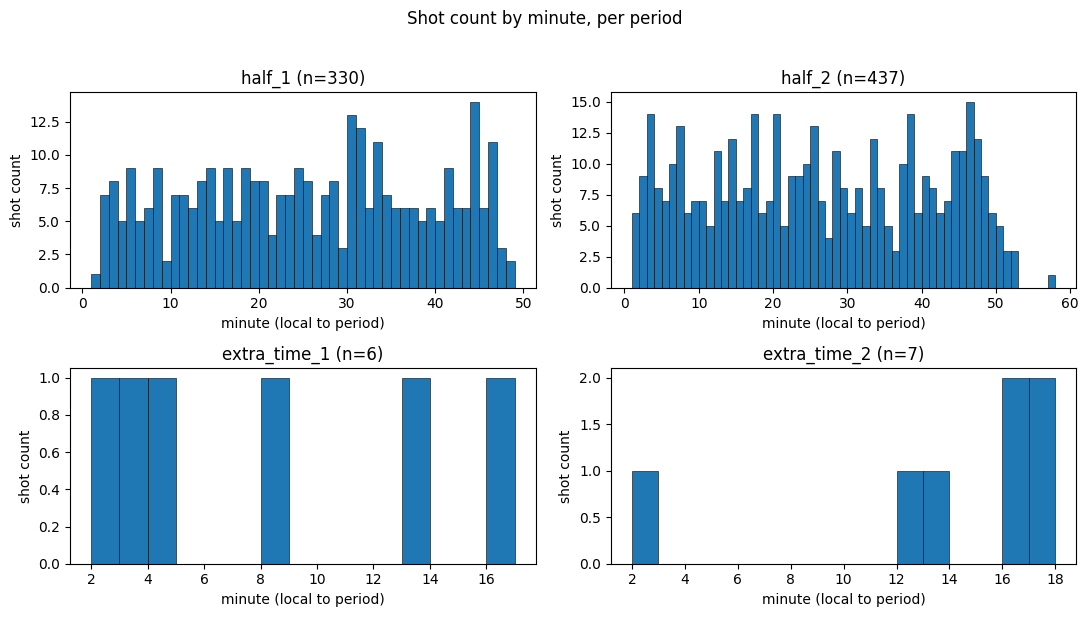

In [21]:
section_header("B7. minute distribution per period")

# Numerical summary first — describe per period.
print(shots.groupby("period")["minute"].describe().round(2).to_string())

# Visualise the per-period minute profile. We use matplotlib directly to
# avoid an extra seaborn dependency for what is effectively a histogram grid.
import matplotlib.pyplot as plt

PERIODS_ORDERED: list[str] = ["half_1", "half_2", "extra_time_1", "extra_time_2"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=False)
for ax, period in zip(axes.flat, PERIODS_ORDERED):
    sub = shots.loc[shots["period"] == period, "minute"]
    if sub.empty:
        ax.set_visible(False)
        continue
    bins = range(int(sub.min()), int(sub.max()) + 2)
    ax.hist(sub, bins=list(bins), edgecolor="black", linewidth=0.4)
    ax.set_title(f"{period} (n={len(sub)})")
    ax.set_xlabel("minute (local to period)")
    ax.set_ylabel("shot count")
fig.suptitle("Shot count by minute, per period", y=1.02)
fig.tight_layout()
plt.show()


### B8 — `possession` cardinality and what it actually identifies

The data dictionary describes `possession` as a "possession sequence
identifier (integer)". A naive reading would be "one id per attacking move",
in which case shots per possession would be mostly 1 with a small tail of
rebound situations.

We test that hypothesis empirically. We compute (a) the number of distinct
`possession` ids in the shot table, (b) the distribution of shots per
possession, and (c) the number of distinct `possession` ids per fixture
(joining via `player_appearance_id` → `fixture_id` from the main table).

If `possession` were a true sequence id, we would expect *many* distinct ids
per fixture (one per attacking move). If instead we observe a small fixed
number per fixture, the field is identifying something coarser.


In [22]:
section_header("B8. possession cardinality")

shots_per_possession: pd.Series = shots.groupby("possession").size()
print(f"distinct possession ids in shot table : {shots_per_possession.size}")
print("\nshots-per-possession describe:")
print(shots_per_possession.describe().round(3).to_string())

# To interpret the field we map each shot to its fixture via the main table
# (loaded in setup) and count distinct possession ids per fixture.
shots_with_fixture = shots.merge(
    appearance_meta["fixture_id"], left_on="player_appearance_id", right_index=True, how="left"
)

possessions_per_fixture: pd.Series = (
    shots_with_fixture.dropna(subset=["fixture_id"])
                      .groupby("fixture_id")["possession"]
                      .nunique()
)
print(f"\nfixtures observed              : {possessions_per_fixture.size}")
print(f"distinct possession ids / fixture (value-counts):")
print(possessions_per_fixture.value_counts().sort_index().to_string())



B8. possession cardinality
distinct possession ids in shot table : 62

shots-per-possession describe:
count    62.000
mean     12.581
std       4.951
min       3.000
25%       9.000
50%      12.000
75%      15.000
max      25.000

fixtures observed              : 31
distinct possession ids / fixture (value-counts):
possession
2    31


### Section B — findings

| ID | Headline |
|----|----------|
| B1 | Right-foot 51.8 %, left-foot 34.7 %, head 13.3 %, ``other`` 0.1 %. → keep all four levels but treat ``other`` as numerically negligible. |
| B2 | ``normal`` 88.6 %; the four non-normal techniques together account for 11.4 % (``volley`` 7.3 %, ``other`` 3.2 %, ``overhead_kick`` 0.5 %, ``lob`` 0.4 %). → consider a ``technique_is_normal`` binary plus a residual flag. |
| B3 | ``regular_play`` 69.6 %, ``corner_kick`` 10.8 %, ``counter_attack`` 7.7 %, ``indirect_free_kick`` 4.6 %, ``direct_free_kick`` 3.3 %, ``throw_in`` 2.7 %, ``penalty`` 1.3 %. → set-piece share ≈ 22.7 %. |
| B4 | ``top`` 95.9 %, ``middle`` 2.7 %, ``bottom`` 1.4 %. → almost all shots from the attacking third. |
| B5 | ``under_pressure`` rate = 77.8 %. → high baseline; useful only in interaction. |
| B6 | ``half_1`` 42.3 %, ``half_2`` 56.0 %, ``extra_time_1`` 0.8 %, ``extra_time_2`` 0.9 %. |
| B7 | Shots are roughly uniformly spread within each half (mean ≈ 25', median ≈ 25') but with a clear *late-half tail* extending into stoppage time (max 48' in H1, 57' in H2). Extra-time shots are too few to draw shape conclusions. |
| B8 | Only **62 distinct `possession` ids** carry shots, with **exactly 2 ids per fixture** (31 fixtures × 2). Shots-per-possession ranges from 3 to 25 (mean 12.6). → `possession` is **not** an attacking-sequence identifier; it identifies a **team within a match**. This invalidates the "rebound shot" interpretation that would have followed from a per-attack reading and replaces it with team-level grouping (useful as the natural join key for team-level aggregates such as team shot count, team pressure rate, etc.). |

**Decisions logged for later steps**

* Body part: keep the four levels; map the single ``other`` row into ``other`` as-is.
* Technique: collapse to ``normal`` vs. ``non_normal`` for first-pass features; preserve a finer encoding only if the modelling step shows residual signal.
* Play pattern: introduce derived booleans ``is_open_play`` (regular_play + counter_attack), ``is_set_piece`` (corner + FKs + throw_in), and ``is_penalty`` to capture the dominant tactical contexts cleanly.
* Stage: a single ``shot_in_top_third`` flag plus the raw counts is sufficient given the 95.9 % concentration.
* Possession: treat `possession` as a **team-in-match** key. Use it to compute team-level rolling features (team's total shots, team's pressure rate, team's set-piece share) which can be subtracted from the player's own values to derive *relative* features. Drop any plan to derive ``possession_shot_index`` / ``is_rebound_shot`` — those would require a true per-attack id which is not present in this dataset.


## Section C — Cross-tabulations

Section B examined each variable in isolation. Section C inspects how the
categorical variables co-vary. Each cross-tab in this section is driven by a
specific tactical hypothesis stated up-front in the markdown cell, followed
by the corresponding two-way frequency table (absolute counts) and a
row-normalised conditional rate table.

The point of stating a hypothesis first is to avoid the post-hoc bias of
"reading patterns into noise" — we report whether the hypothesis was
confirmed, refuted, or inconclusive given the sample size.

| ID | Cross-tab | Hypothesis |
|----|-----------|------------|
| C1 | `body_part` × `technique`        | Heads almost never produce volleys; ``other`` body parts cluster on ``other`` technique. |
| C2 | `play_pattern` × `stage`         | Set-piece shots originate overwhelmingly from the attacking third; throw-ins disproportionately from the middle third. |
| C3 | `play_pattern` × `under_pressure`| Penalties are never under pressure; counter-attacks face less pressure than regular play. |
| C4 | `technique` × `under_pressure`   | Speculative techniques (lob, overhead) disproportionately taken under pressure. |
| C5 | `body_part` × `stage`            | Headers concentrate in the attacking third (cross + corner deliveries). |
| C6 | `period` × `play_pattern`        | Set-piece share is roughly stable across halves; pressure rate may rise in extra-time. |


### C1 — `body_part` × `technique`

**Hypothesis.** Headers physically cannot be volleys or lobs as defined
(those require the foot). The single ``other`` body-part row is expected to
fall into ``other`` technique. Foot shots should overwhelmingly use
``normal`` technique, with the rare techniques splitting roughly evenly
between feet.


In [23]:
section_header("C1. body_part x technique")
counts, rates = crosstab_with_rates(shots, "body_part", "technique")

print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())



C1. body_part x technique
absolute counts:
technique   lob  normal  other  overhead_kick  volley
body_part                                            
head          2      84     18              0       0
left_foot     0     245      2              2      22
other         0       0      1              0       0
right_foot    1     362      4              2      35

row-normalised rates (each row sums to 1.0):
technique     lob  normal  other  overhead_kick  volley
body_part                                              
head        0.019   0.808  0.173          0.000   0.000
left_foot   0.000   0.904  0.007          0.007   0.081
other       0.000   0.000  1.000          0.000   0.000
right_foot  0.002   0.896  0.010          0.005   0.087


### C2 — `play_pattern` × `stage`

**Hypothesis.** The attacking third dominates regardless of play pattern, but
two specific patterns may be different:

* **Throw-ins** are commonly taken from the middle third of the pitch and may
  yield middle-third shots more often than other patterns.
* **Direct free kicks** are taken from a wider range of distances; some may
  originate in the middle third.


In [24]:
section_header("C2. play_pattern x stage")
counts, rates = crosstab_with_rates(shots, "play_pattern", "stage")

print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())



C2. play_pattern x stage
absolute counts:
stage               bottom  middle  top
play_pattern                           
corner_kick              5       2   77
counter_attack           0       2   58
direct_free_kick         0       1   25
indirect_free_kick       1       1   34
penalty                  0       0   10
regular_play             5      14  524
throw_in                 0       1   20

row-normalised rates (each row sums to 1.0):
stage               bottom  middle    top
play_pattern                             
corner_kick          0.060   0.024  0.917
counter_attack       0.000   0.033  0.967
direct_free_kick     0.000   0.038  0.962
indirect_free_kick   0.028   0.028  0.944
penalty              0.000   0.000  1.000
regular_play         0.009   0.026  0.965
throw_in             0.000   0.048  0.952


### C3 — `play_pattern` × `under_pressure`

**Hypothesis.** The penalty kick is taken from a fixed spot with no defender
within 9.15 m → ``under_pressure`` should be ``False`` for every penalty.
Counter-attacks are characterised by a numerical advantage for the attacking
team → expect a *lower* pressure rate than regular play. Set pieces other
than penalties (corners, free kicks) are crowded by definition → expect a
*higher* pressure rate than regular play.


In [25]:
section_header("C3. play_pattern x under_pressure")
counts, rates = crosstab_with_rates(shots, "play_pattern", "under_pressure")

print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())



C3. play_pattern x under_pressure
absolute counts:
under_pressure      False  True 
play_pattern                    
corner_kick            19     65
counter_attack         16     44
direct_free_kick       21      5
indirect_free_kick      9     27
penalty                10      0
regular_play           95    448
throw_in                3     18

row-normalised rates (each row sums to 1.0):
under_pressure      False  True 
play_pattern                    
corner_kick         0.226  0.774
counter_attack      0.267  0.733
direct_free_kick    0.808  0.192
indirect_free_kick  0.250  0.750
penalty             1.000  0.000
regular_play        0.175  0.825
throw_in            0.143  0.857


### C4 — `technique` × `under_pressure`

**Hypothesis.** Lobs, volleys and overhead kicks are improvised techniques
typically used when the player has no time or space to bring the ball under
control. We therefore expect their pressure rate to be **higher** than that
of ``normal`` strikes.


In [26]:
section_header("C4. technique x under_pressure")
counts, rates = crosstab_with_rates(shots, "technique", "under_pressure")

print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())



C4. technique x under_pressure
absolute counts:
under_pressure  False  True 
technique                   
lob                 1      2
normal            160    531
other               0     25
overhead_kick       0      4
volley             12     45

row-normalised rates (each row sums to 1.0):
under_pressure  False  True 
technique                   
lob             0.333  0.667
normal          0.232  0.768
other           0.000  1.000
overhead_kick   0.000  1.000
volley          0.211  0.789


### C5 — `body_part` × `stage`

**Hypothesis.** Headers are produced almost exclusively from crosses and
corner deliveries that land in the box, so they should concentrate in the
attacking third even more strongly than foot shots do.


In [27]:
section_header("C5. body_part x stage")
counts, rates = crosstab_with_rates(shots, "body_part", "stage")

print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())



C5. body_part x stage
absolute counts:
stage       bottom  middle  top
body_part                      
head             6       2   96
left_foot        2       7  262
other            0       0    1
right_foot       3      12  389

row-normalised rates (each row sums to 1.0):
stage       bottom  middle    top
body_part                        
head         0.058   0.019  0.923
left_foot    0.007   0.026  0.967
other        0.000   0.000  1.000
right_foot   0.007   0.030  0.963


### C6 — `period` × `play_pattern` and pressure-rate by period

**Hypothesis (a).** Tactics and play composition are broadly stable across
the two regulation halves, so the row-normalised play-pattern distribution
should be similar between ``half_1`` and ``half_2``.

**Hypothesis (b).** Late in matches teams often retreat into low blocks
under fatigue. We compute the marginal ``under_pressure`` rate by period as
a coarse proxy: if the rate rises into the second half / extra-time we
update the feature plan accordingly.


In [28]:
section_header("C6a. period x play_pattern")
counts, rates = crosstab_with_rates(shots, "period", "play_pattern")
print("absolute counts:")
print(counts.to_string())
print("\nrow-normalised rates (each row sums to 1.0):")
print(rates.round(3).to_string())

section_header("C6b. under_pressure rate by period")
pressure_by_period = (
    shots.groupby("period")["under_pressure"]
         .agg(["size", "sum", "mean"])
         .rename(columns={"size": "n_shots", "sum": "n_under_pressure", "mean": "pressure_rate"})
         .round(3)
)
print(pressure_by_period.to_string())



C6a. period x play_pattern
absolute counts:
play_pattern  corner_kick  counter_attack  direct_free_kick  indirect_free_kick  penalty  regular_play  throw_in
period                                                                                                          
extra_time_1            0               0                 0                   0        0             6         0
extra_time_2            1               0                 0                   0        0             6         0
half_1                 33              22                 9                  17        5           233        11
half_2                 50              38                17                  19        5           298        10

row-normalised rates (each row sums to 1.0):
play_pattern  corner_kick  counter_attack  direct_free_kick  indirect_free_kick  penalty  regular_play  throw_in
period                                                                                                          
extra

### Section C — findings

Each row reports whether the hypothesis was **confirmed (✔)**, **refuted (✘)**
or **partially supported (~)** given the sample, with the headline numbers
extracted from the executed cells.

| ID | Result | Headline |
|----|--------|----------|
| C1 | ~ | Heads: ``normal`` 80.8 %, ``other`` 17.3 %, ``lob`` 1.9 %, no volleys/overheads. The "no volleys/overheads from heads" sub-claim is confirmed; the existence of 2 head ``lob`` rows is unexpected. The single ``other`` body-part row is ``other`` technique. Right/left foot are symmetric: ``right_foot`` 89.6 % normal, ``left_foot`` 90.4 % normal. |
| C2 | ✔ | Top-third concentration by play_pattern: penalty 100 %, counter_attack 96.7 %, regular_play 96.5 %, direct_FK 96.2 %, throw_in 95.2 %, indirect_FK 94.4 %, corner_kick 91.7 %. The "middle-third throw-in" sub-hypothesis is refuted (95.2 % top). |
| C3 | ✔ | Penalties: **0 / 10** under pressure (perfect). Counter-attacks: 73.3 % under pressure vs. 82.5 % for regular play (lower as predicted). Surprise: **`direct_free_kick` only 19.2 % under pressure** — taken from set positions away from defenders — vs. `indirect_free_kick` 75.0 % (taken closer to goal, more crowded). |
| C4 | ✔ | Pressure rates by technique: ``other`` 100 %, ``overhead_kick`` 100 % (n=4), ``volley`` 78.9 %, ``normal`` 76.8 %, ``lob`` 66.7 % (n=3). The hypothesis (improvised techniques are pressed more) is supported on volley/other/overhead; lob is too small (n=3) to interpret. |
| C5 | ✘ | Heads: 92.3 % top (6 bottom, 2 middle, 96 top). Right_foot: 96.3 % top. Left_foot: 96.7 % top. **Headers are *less* concentrated in the attacking third than foot shots** — likely because some headed attempts are at the edges of the box from cleared corners or from defenders' headed shots on long set pieces. |
| C6 | (a) ✔ (b) ✘ | Half-1 vs. half-2 play-pattern shares are within ≤2.4 pp on every category — composition is stable. Pressure rates: H1 77.9 %, H2 77.8 % (essentially identical), ET1 66.7 % (n=6), ET2 85.7 % (n=7). No regulation-time fatigue effect; ET samples too thin to interpret. |

**Decisions logged for later steps**

* `body_part == 'head'` is a clean discriminator from foot shots in the technique distribution (high ``other``, no volleys/overheads). Encode headers separately rather than crossing all body-parts × all techniques.
* Penalty pressure rate = 0 confirms ``play_pattern == 'penalty'`` is a near-perfect proxy for "free shot" — keep ``is_penalty`` as a standalone feature.
* `direct_free_kick` is structurally different from other set-pieces (low pressure rate, taken from distance). Treat it as its own bucket rather than lumping into a generic ``is_set_piece`` flag.
* Pressure rate by play pattern (regular_play 82.5 %, counter_attack 73.3 %, indirect_FK 75 %, direct_FK 19.2 %, penalty 0 %) is a strong signal — engineer an interaction term ``play_pattern × under_pressure`` rather than treating them independently.
* Within regulation halves, period-level shifts in pressure rate are negligible (<0.1 pp) → no period-specific pressure feature needed; rely on `last15_*` / `cumul_*` for temporal dynamics.


## Section D — Player- and match-level aggregates

Sections A–C examined the shot table at the event level. Section D shifts the
unit of analysis to two coarser grains that are directly relevant for
modelling:

* **Appearance level** (one row per `player_appearance_id` = one player in
  one match) — this is the natural denominator for *per-match* shooting
  intensity and is the level the main panel rolls up to.
* **Fixture level** (one row per `fixture_id`) — this captures match-level
  variation that may differ across teams and tactical setups.

We also profile the heavy shooters (Section D4) so we can later sanity-check
that engineered shot features track player style.

| ID | Aggregate |
|----|-----------|
| D1 | Shots per appearance — distribution overall. |
| D2 | Shots per appearance stratified by `position` (G / D / M / A). |
| D3 | Shots per fixture — match-level variance. |
| D4 | Top shooters at appearance and player levels with body-part / play-pattern composition. |


### D1 — Shots per appearance (overall distribution)

Shooting intensity is highly non-uniform: most appearances generate zero
shots while a small minority produce most of them. Quantifying that skew
sets expectations for the heavy right-tail of `last15_shots` and
`cumul_shots` in the main table.

Note that the shot table only contains rows for appearances that took **at
least one shot**. The "true zero" appearances live exclusively in the main
table. We therefore report two views: (a) the conditional distribution
*given a player took a shot*, and (b) the unconditional distribution after
joining onto the full set of appearances in the main table.


In [29]:
section_header("D1. shots per appearance — conditional (shooters only)")

shots_per_appearance: pd.Series = (
    shots.groupby("player_appearance_id").size().rename("n_shots")
)
print(f"appearances with ≥ 1 shot : {shots_per_appearance.size}")
print(shots_per_appearance.describe().round(3).to_string())
print("\nfull value-count distribution (shots → number of appearances):")
print(
    shots_per_appearance.value_counts()
                        .sort_index()
                        .rename_axis("n_shots")
                        .to_frame("n_appearances")
                        .to_string()
)

section_header("D1. shots per appearance — unconditional (all appearances in main)")
all_appearances: pd.Index = appearance_meta.index
shots_per_appearance_full: pd.Series = (
    shots_per_appearance.reindex(all_appearances, fill_value=0).rename("n_shots")
)
print(f"appearances in main panel : {shots_per_appearance_full.size}")
print(shots_per_appearance_full.describe().round(3).to_string())
print("\nshare of appearances with zero shots : "
      f"{(shots_per_appearance_full == 0).mean():.4%}")



D1. shots per appearance — conditional (shooters only)
appearances with ≥ 1 shot : 453
count    453.000
mean       1.722
std        1.094
min        1.000
25%        1.000
50%        1.000
75%        2.000
max        7.000

full value-count distribution (shots → number of appearances):
         n_appearances
n_shots               
1                  264
2                  107
3                   46
4                   24
5                    7
6                    2
7                    3

D1. shots per appearance — unconditional (all appearances in main)
appearances in main panel : 869
count    869.000
mean       0.876
std        1.170
min        0.000
25%        0.000
50%        1.000
75%        1.000
max        7.000

share of appearances with zero shots : 49.5972%


### D2 — Shots per appearance by position

Goalkeepers (`G`) effectively never shoot in regulation play; defenders (`D`)
shoot rarely; midfielders (`M`) and attackers (`A`) carry most attempts.
Verifying this directly tells us:

1. **How clean the position label is** — any non-zero shot count for `G`
   would warrant inspection.
2. **How concentrated shooting is** — the share of total shots taken by `A`
   sets an upper bound on how much of the `scored_after` signal can be
   carried by attacker-only features.

The unconditional view (zeros included) is the right one here because we
want to compare shot rates across positions, not just intensity *given* a
shot was taken.


In [30]:
section_header("D2. shots per appearance by position")

# Build a long table with one row per appearance, joined to position.
shots_by_app_pos: pd.DataFrame = (
    shots_per_appearance_full.to_frame()
                             .join(appearance_meta["position"], how="left")
)
position_summary: pd.DataFrame = (
    shots_by_app_pos.groupby("position")["n_shots"]
                    .agg(["size", "sum", "mean", "median", "max"])
                    .rename(
                        columns={
                            "size": "n_appearances",
                            "sum": "total_shots",
                            "mean": "mean_shots",
                            "median": "median_shots",
                            "max": "max_shots",
                        }
                    )
                    .round(3)
)
position_summary["share_of_all_shots"] = (
    position_summary["total_shots"] / position_summary["total_shots"].sum()
).round(3)
position_summary["share_of_appearances"] = (
    position_summary["n_appearances"] / position_summary["n_appearances"].sum()
).round(3)
print(position_summary.to_string())

# Distribution of n_shots within each position (top 6 buckets per position).
print("\nshots-per-appearance value counts, by position (top 6 each):")
for pos, grp in shots_by_app_pos.groupby("position"):
    vc = grp["n_shots"].value_counts().sort_index().head(6)
    print(f"\n{pos}: {vc.to_dict()}")



D2. shots per appearance by position
          n_appearances  total_shots  mean_shots  median_shots  max_shots  share_of_all_shots  share_of_appearances
position                                                                                                           
A                   179          290       1.620           1.0          7               0.381                 0.206
D                   271          118       0.435           0.0          3               0.155                 0.312
G                    62            0       0.000           0.0          0               0.000                 0.071
M                   357          353       0.989           1.0          7               0.464                 0.411

shots-per-appearance value counts, by position (top 6 each):

A: {0: 35, 1: 73, 2: 32, 3: 18, 4: 12, 5: 5}

D: {0: 181, 1: 66, 2: 20, 3: 4}

G: {0: 62}

M: {0: 153, 1: 113, 2: 53, 3: 23, 4: 12, 5: 2}


### D3 — Shots per fixture

Match-level variance in shot volume reflects style differences across teams
and tactical match-ups. We compute the distribution of shot counts per
fixture (joining via `appearance_meta["fixture_id"]`).

The mean shots-per-fixture should be ≈ 780 / 31 = 25.16 by construction; we
report the spread and the extreme matches to surface any outliers (very
low-event tactical lock-downs or end-to-end shoot-outs).


In [31]:
section_header("D3. shots per fixture")

shots_with_fixture_id: pd.Series = shots.merge(
    appearance_meta["fixture_id"], left_on="player_appearance_id", right_index=True, how="left"
)["fixture_id"]

shots_per_fixture: pd.Series = (
    shots_with_fixture_id.dropna()
                         .astype(int)
                         .value_counts()
                         .rename_axis("fixture_id")
                         .rename("n_shots")
)
print(f"fixtures observed : {shots_per_fixture.size}")
print(shots_per_fixture.describe().round(2).to_string())

print("\n5 lowest-shot fixtures:")
print(shots_per_fixture.sort_values().head().to_string())

print("\n5 highest-shot fixtures:")
print(shots_per_fixture.sort_values(ascending=False).head().to_string())



D3. shots per fixture
fixtures observed : 31
count    31.00
mean     24.55
std       5.87
min      15.00
25%      20.50
50%      24.00
75%      29.00
max      35.00

5 lowest-shot fixtures:
fixture_id
1200    15
1161    16
1215    16
1220    17
1160    17

5 highest-shot fixtures:
fixture_id
1225    35
1191    34
1221    33
1198    33
1204    32


### D4 — Top shooters and their composition

We report the heaviest shooters at two grains:

* **Top 10 single-match appearances** by raw shot count, with each
  appearance's body-part and play-pattern composition. Use these to
  sanity-check engineered features by hand later.
* **Top 10 players** by *cumulative* shots across the tournament. A player
  who appears repeatedly with high shot counts is a structural shooter;
  features should be able to reflect this.


In [32]:
section_header("D4a. top 10 single-match appearances by shot count")

# Per-appearance counts joined with player/position.
appearance_top: pd.DataFrame = (
    shots_per_appearance.to_frame()
                        .join(appearance_meta[["player_id", "position", "fixture_id"]], how="left")
                        .sort_values("n_shots", ascending=False)
                        .head(10)
)
print(appearance_top.to_string())

# Composition of these top appearances: body_part and play_pattern shares.
def _composition(field: str, top_apps: pd.DataFrame) -> pd.DataFrame:
    """Return the share of each `field` value within each top appearance."""
    sub = shots[shots["player_appearance_id"].isin(top_apps.index)]
    pivot = (
        pd.crosstab(sub["player_appearance_id"], sub[field], normalize="index")
        .round(3)
        .reindex(top_apps.index)
    )
    return pivot

print("\nbody_part composition:")
print(_composition("body_part", appearance_top).to_string())
print("\nplay_pattern composition:")
print(_composition("play_pattern", appearance_top).to_string())

section_header("D4b. top 10 players by cumulative shots")

# Aggregate to player_id by joining each shot with its player.
shots_with_player: pd.DataFrame = shots.merge(
    appearance_meta[["player_id", "position"]], left_on="player_appearance_id", right_index=True, how="left"
)
player_top: pd.DataFrame = (
    shots_with_player.groupby(["player_id", "position"])
                     .size()
                     .rename("n_shots")
                     .reset_index()
                     .sort_values("n_shots", ascending=False)
                     .head(10)
                     .set_index("player_id")
)
# Number of distinct appearances each top player has across the tournament.
appearances_per_player: pd.Series = (
    appearance_meta.reset_index().groupby("player_id")["player_appearance_id"].nunique()
)
player_top["n_appearances_in_tournament"] = appearances_per_player.reindex(player_top.index)
player_top["shots_per_appearance"] = (
    player_top["n_shots"] / player_top["n_appearances_in_tournament"]
).round(2)
print(player_top.to_string())



D4a. top 10 single-match appearances by shot count
                      n_shots  player_id position  fixture_id
player_appearance_id                                         
42166                       7     3564.0        M      1220.0
39930                       7     3404.0        A      1170.0
41353                       7     3304.0        A      1202.0
41916                       6     3404.0        A      1216.0
40858                       6     3447.0        A      1191.0
40773                       5     3564.0        M      1189.0
41465                       5     3446.0        A      1205.0
41346                       5     3299.0        A      1202.0
42689                       5     3560.0        A      1225.0
42717                       5     3512.0        M      1225.0

body_part composition:
body_part              head  left_foot  right_foot
player_appearance_id                              
42166                 0.000      0.714       0.286
39930                 0.143

### Section D — findings

| ID | Headline |
|----|----------|
| D1 | 453 / 869 appearances (52.1 %) take at least one shot. Conditional distribution: median 1, mean 1.72, max 7; tail decays steeply (264 / 107 / 46 / 24 / 7 / 2 / 3 across 1..7 shots). Unconditional mean 0.876, **49.6 % of appearances are true zeros** — confirms `last15_shots` / `cumul_shots` will be sparse, right-skewed integer features. |
| D2 | Position-stratified shot rates (mean per appearance): **A 1.62, M 0.99, D 0.44, G 0.00**. Goalkeepers take 0 shots in 0 appearances of 62 — clean. Surprise: **midfielders take 46.4 % of all shots vs. attackers 38.1 %** (driven by 2× more M appearances than A: 357 vs. 179). Attackers are more *intense* shooters but midfielders contribute more *volume*. |
| D3 | 31 fixtures, mean 24.5 shots / fixture, std 5.9, range [15, 35]. Lowest-shot match: fixture 1200 (15 shots). Highest: fixture 1225 (35 shots). The spread is moderate — no extreme tactical outlier, no end-to-end shoot-out. |
| D4 | Three single-match appearances tied at the top with **7 shots each** (appearance ids 42166-M, 39930-A, 41353-A); top 10 dominated by attackers (6 / 10) but two midfielders feature. Several appearances are essentially *single-foot* (e.g. 40858, 41346 → 100 % left foot) — left-footed shooters are over-represented in heavy-shot games. **Top tournament shooters: player 3564 (M, 18 shots / 6 apps), 3512 (M, 17 / 5), 3404 (A, 15 / 4 = 3.75 / app — most intense)**. |

**Decisions logged for later steps**

* The 49.6 % zero rate justifies modelling `last15_shots` and `cumul_shots` either with hurdle / two-part structure or with monotone tree splits — linear regression on raw counts will be poorly calibrated.
* Position is the single strongest stratifier of shot intensity. Either include `position` as a categorical feature (preferred for tree models) or fit position-stratified sub-models.
* The midfielder-vs-attacker volume inversion means a *per-appearance* shot intensity feature ("shots per minute on the pitch") may carry more position-independent signal than raw `cumul_shots`.
* Body-part composition varies sharply across heavy shooters (some are 100 % left-foot). When engineering shot-mix features (Section / step 3), preserve the right / left split rather than collapsing into a single `foot_share`.
* Fixture-level variance is moderate (cv ≈ 24 %); a `team_total_shots_so_far` feature derived via the `possession` (= team-in-match) key may carry useful tactical context.


## Section E — Team-in-match dimension

Section B8 established that the `possession` field is **not** an
attacking-sequence identifier (as one might expect from the data dictionary's
phrasing) but a **team-in-match** identifier — exactly two distinct values
per fixture, 31 fixtures × 2 = 62 ids. This re-purposes Section E entirely:
instead of analysing rebounds and second-ball sequences, we use `possession`
as the natural key for *team-level* aggregations within a match.

| ID | Aggregate / check |
|----|-------------------|
| E1 | Lock in the `possession ↔ team` interpretation by confirming that within each `possession` id, every shooter shares the same `is_home` value. |
| E2 | Per (team-in-match) shot composition: body_part, play_pattern, pressure rate. |
| E3 | Within-fixture asymmetry: how lopsided is the shot share between the two teams of a match? |
| E4 | Player share of own team's shots — preview of a "shooting concentration" feature. |


### E1 — Confirm `possession` identifies a team within a match

If `possession` truly identifies a team-in-match, every shot tagged with the
same `possession` id should be taken by players on the same team. We verify
this by joining each shot to `is_home` (from `appearance_meta`) and counting
the number of distinct `is_home` values per `possession`. A perfect
team-in-match hypothesis predicts exactly **one** `is_home` value per
possession.


In [33]:
section_header("E1. possession ↔ team identity check")

shots_with_team: pd.DataFrame = shots.merge(
    appearance_meta[["fixture_id", "is_home"]],
    left_on="player_appearance_id",
    right_index=True,
    how="left",
)

is_home_per_possession: pd.Series = shots_with_team.groupby("possession")["is_home"].nunique()
print(f"distinct is_home values per possession id (value counts):")
print(is_home_per_possession.value_counts().sort_index().to_string())

# As a corollary: each fixture should have exactly one home possession and
# one away possession.
fixture_split = (
    shots_with_team.groupby(["fixture_id", "is_home"])["possession"]
                   .nunique()
                   .unstack(fill_value=0)
)
print(f"\nfixtures with (1 home, 1 away) possession ids : "
      f"{((fixture_split == 1).all(axis=1)).sum()} / {fixture_split.shape[0]}")

assert (is_home_per_possession == 1).all(), \
    "possession id spans both teams — team-in-match hypothesis refuted"



E1. possession ↔ team identity check
distinct is_home values per possession id (value counts):
is_home
1    62

fixtures with (1 home, 1 away) possession ids : 31 / 31


### E2 — Per (team-in-match) shot composition

Now that `possession` is locked in as team-in-match, we can compute team-level
totals. Three summaries:

* **Shots per team-in-match** — describe the distribution.
* **Pressure rate per team-in-match** — does it vary across teams?
* **Top-3 vs. bottom-3 teams by shot volume** with their body-part /
  play-pattern composition — used to sanity-check that team styles look
  coherent.


In [34]:
section_header("E2a. shots per team-in-match")

shots_per_team_match: pd.Series = (
    shots.groupby("possession").size().rename("n_shots").sort_values(ascending=False)
)
print(shots_per_team_match.describe().round(2).to_string())

section_header("E2b. pressure rate per team-in-match")

pressure_per_team_match: pd.DataFrame = (
    shots.groupby("possession")["under_pressure"]
         .agg(["size", "sum", "mean"])
         .rename(columns={"size": "n_shots", "sum": "n_under_pressure", "mean": "pressure_rate"})
         .round(3)
)
print(pressure_per_team_match["pressure_rate"].describe().round(3).to_string())

section_header("E2c. top 3 vs. bottom 3 teams by shot volume — composition")

top3_pos: list[int] = shots_per_team_match.head(3).index.tolist()
bot3_pos: list[int] = shots_per_team_match.tail(3).index.tolist()


def _team_composition(possession_ids: list[int]) -> pd.DataFrame:
    """Return body_part and play_pattern row-shares for the given teams."""
    sub = shots[shots["possession"].isin(possession_ids)]
    bp = pd.crosstab(sub["possession"], sub["body_part"], normalize="index").round(3)
    pp = pd.crosstab(sub["possession"], sub["play_pattern"], normalize="index").round(3)
    return bp, pp


top_bp, top_pp = _team_composition(top3_pos)
bot_bp, bot_pp = _team_composition(bot3_pos)
print("top-3 teams body_part composition:")
print(top_bp.to_string())
print("\ntop-3 teams play_pattern composition:")
print(top_pp.to_string())
print("\nbottom-3 teams body_part composition:")
print(bot_bp.to_string())
print("\nbottom-3 teams play_pattern composition:")
print(bot_pp.to_string())



E2a. shots per team-in-match
count    62.00
mean     12.58
std       4.95
min       3.00
25%       9.00
50%      12.00
75%      15.00
max      25.00

E2b. pressure rate per team-in-match
count    62.000
mean      0.768
std       0.164
min       0.250
25%       0.667
50%       0.782
75%       0.907
max       1.000

E2c. top 3 vs. bottom 3 teams by shot volume — composition
top-3 teams body_part composition:
body_part    head  left_foot  right_foot
possession                              
2306        0.182      0.091       0.727
2308        0.182      0.091       0.727
2348        0.000      0.560       0.440

top-3 teams play_pattern composition:
play_pattern  corner_kick  counter_attack  direct_free_kick  indirect_free_kick  penalty  regular_play  throw_in
possession                                                                                                      
2306                0.136           0.000             0.045               0.091    0.045         0.636     0.045
2308  

### E3 — Within-fixture shot-share asymmetry

For each fixture we compute the shot share of the *home* team. A perfectly
balanced match has a 50 / 50 split; a one-sided match (one team dominates
the chances) sits closer to 0 or 1. The distribution of these 31 shares is
informative:

* If the distribution clusters near 0.5, scoring opportunities are roughly
  symmetric and the home / away effect on individual goal probability is
  weak.
* A long left or right tail signals matches in which one team monopolised
  the chances — useful as a motivating example for engineering a
  "team_shot_share_so_far" contextual feature.


In [35]:
section_header("E3. home team shot share by fixture")

# Build a (fixture × is_home) shot count, then compute home share per fixture.
fixture_team_counts: pd.DataFrame = (
    shots_with_team.groupby(["fixture_id", "is_home"])
                   .size()
                   .unstack(fill_value=0)
                   .rename(columns={True: "home", False: "away"})
)
fixture_team_counts["total"] = fixture_team_counts.sum(axis=1)
fixture_team_counts["home_share"] = (
    fixture_team_counts["home"] / fixture_team_counts["total"]
).round(3)

print("home shot-share — describe:")
print(fixture_team_counts["home_share"].describe().round(3).to_string())

print("\n5 most home-dominated fixtures:")
print(fixture_team_counts.sort_values("home_share", ascending=False).head().to_string())
print("\n5 most away-dominated fixtures:")
print(fixture_team_counts.sort_values("home_share").head().to_string())



E3. home team shot share by fixture
home shot-share — describe:
count    31.000
mean      0.524
std       0.166
min       0.130
25%       0.415
50%       0.533
75%       0.657
max       0.812

5 most home-dominated fixtures:
is_home     away  home  total  home_share
fixture_id                               
1215.0         3    13     16       0.812
1171.0         6    22     28       0.786
1206.0         6    18     24       0.750
1170.0         9    22     31       0.710
1191.0        10    24     34       0.706

5 most away-dominated fixtures:
is_home     away  home  total  home_share
fixture_id                               
1202.0        20     3     23       0.130
1188.0        17     5     22       0.227
1166.0        15     7     22       0.318
1190.0        12     6     18       0.333
1163.0        16     8     24       0.333


### E4 — Player share of own team's shots

A useful piece of "shooting concentration" signal is the share of the team's
shots that comes from a single player in a match. A high share suggests the
player was the team's primary attacking outlet; a low share suggests
distributed creation. We compute this share per (player_appearance_id,
possession) and report its distribution restricted to appearances with at
least 2 team shots (otherwise the share is trivially 0 or 1).


In [36]:
section_header("E4. player share of own-team shots")

# Per-team-in-match total
team_totals: pd.Series = shots.groupby("possession").size().rename("team_n_shots")

# Per-(appearance, team) shot count — joining team-totals back in.
appearance_team_shots: pd.DataFrame = (
    shots.groupby(["possession", "player_appearance_id"])
         .size()
         .rename("player_n_shots")
         .reset_index()
         .merge(team_totals, on="possession")
)
appearance_team_shots["player_share"] = (
    appearance_team_shots["player_n_shots"] / appearance_team_shots["team_n_shots"]
).round(3)

# Restrict to teams with at least 2 shots so the share is non-trivial.
non_trivial = appearance_team_shots[appearance_team_shots["team_n_shots"] >= 2]
print(f"records (player × team-in-match) with team_n_shots ≥ 2 : {len(non_trivial)}")
print(non_trivial["player_share"].describe().round(3).to_string())

# Concentration: top 5 (player_appearance, team) records by player share.
print("\nhighest player shares (≥ 3 player shots, for non-trivial concentration):")
print(
    non_trivial[non_trivial["player_n_shots"] >= 3]
    .sort_values("player_share", ascending=False)
    .head()
    .to_string(index=False)
)



E4. player share of own-team shots
records (player × team-in-match) with team_n_shots ≥ 2 : 453
count    453.000
mean       0.137
std        0.083
min        0.040
25%        0.077
50%        0.111
75%        0.167
max        0.636

highest player shares (≥ 3 player shots, for non-trivial concentration):
 possession  player_appearance_id  player_n_shots  team_n_shots  player_share
       2410                 42166               7            11         0.636
       2367                 41263               3             7         0.429
       2349                 40875               4            10         0.400
       2345                 40784               3             8         0.375
       2284                 39433               3             8         0.375


### Section E — findings

| ID | Headline |
|----|----------|
| E1 | ✔ Hypothesis fully confirmed: every one of the 62 `possession` ids has exactly 1 distinct `is_home` value, and every one of the 31 fixtures has exactly (1 home, 1 away) possession id. `possession` is locked in as team-in-match. |
| E2 | Shots per team-in-match: median 12, range [3, 25]. Pressure rate per team: median 0.78, **range [0.25, 1.00]** — much wider than the population-level rate would suggest. One team takes only 25 % of its shots under pressure; another team is pressured on every shot. Top-3 volume teams have diverse styles (one is 56 % left-foot / 92 % regular_play); bottom-3 teams (3 shots each) are too small to characterise. |
| E3 | Home shot-share mean 0.52, median 0.53, std 0.17 — small but positive home advantage in shot *volume*. Wide spread: most home-dominated fixture is 1215 (81 % home share, 13–3 split); most away-dominated is 1202 (13 % home share, 3–20 split). Several matches were highly lopsided. |
| E4 | Player share of own-team shots: median 11 %, mean 14 %, max 63.6 %. Top concentration: appearance 42166 took **7 of his team's 11 shots** in fixture 1220 — extreme single-outlet pattern. Useful as an engineered "shooting concentration" feature. |

**Decisions logged for later steps**

* Use `possession` as the **canonical team-in-match key** for every team-level rolling aggregate (team_total_shots_so_far, team_pressure_rate_so_far, team_top_third_share_so_far). It is the natural join field and avoids depending on `is_home` or fixture/team derivations.
* Engineer a **player-share feature** of the form `player_shots_so_far / team_shots_so_far` (with a smoothing constant or NaN guard for the team_total = 0 case). Section E4 confirms the metric has a meaningful spread.
* The wide team pressure-rate spread (25 % – 100 %) suggests a team-level pressure feature can capture team-style differences that a player-level pressure rate cannot.
* The home-shot-share spread (0.13 – 0.81) confirms `is_home` alone is a coarse signal; pair it with team-shot-share-so-far for a sharper "team is dominating possession" feature.


## Section F — Linkage to the main panel and connection to the target

Section F is the bridge between the shot-event table and the modelling
panel. It is the most consequential section of the EDA because every later
modelling step depends on (a) confirming the main panel is a faithful
aggregation of the shot events and (b) understanding which raw or derived
shot signals actually move the target variable `scored_after`.

The section is organised in seven subsections:

| ID | Subject |
|----|---------|
| F1 | Linkage coverage — appearances in the shot table that are absent from the main panel. |
| F2 | Replication of `cumul_shots` / `last15_shots` from raw events; the deviation from main is itself diagnostic. |
| F3 | Bivariate `scored_after` rate by existing main-table shot features (overall and by position). |
| F4 | Bivariate `scored_after` rate by engineered candidate features. |
| F5 | Cross-correlation matrix of existing shot features. |
| F6 | Structural invariants on the main-table aggregates. |
| F7 | Domain-driven interactions worth carrying into the modelling step. |

This revision implements **F1**; F2–F7 are added in subsequent revisions.


### F1 — Linkage coverage: shot-table appearances absent from the main panel

We earlier observed (during the cross-table overview) that the shot table
contains **15 `player_appearance_id` values that are not present in the
main panel**. We list them explicitly here, because:

1. **Modelling implication.** The main panel is the prediction table — it
   contains one row per `(player_appearance_id, checkpoint)`. Any shot
   event whose appearance is missing from the panel has *no row to attach
   features to*. We therefore filter the shot table to
   `player_appearance_id ∈ main` before every later aggregation.
2. **Sanity check.** If the orphans turned out to be scattered randomly
   across periods and minutes, that would suggest a data-pipeline bug.
   If instead they cluster in a structurally explainable region of the
   match (e.g. very late substitutes who never crossed a checkpoint), the
   omission is by design — checkpoints exist only at fixed local minutes
   and a late sub may simply have no checkpoint to anchor on.

We therefore (a) compute the set of orphan appearances, (b) summarise
their shots per appearance and the periods / minutes in which those shots
fall, and (c) confirm whether the orphans match the "late substitute"
hypothesis.


In [37]:
section_header("F1. orphan appearances — present in shot table, absent from main")

main_appearances: set[int] = set(main["player_appearance_id"].unique())
shot_appearances: set[int] = set(shots["player_appearance_id"].unique())
orphan_appearances: list[int] = sorted(shot_appearances - main_appearances)

print(f"appearances in shot table     : {len(shot_appearances)}")
print(f"appearances in main panel     : {len(main_appearances)}")
print(f"orphan appearances (shot ∖ main): {len(orphan_appearances)}")
print(f"\norphan appearance ids: {orphan_appearances}")

# Per-orphan summary — one row per orphan appearance, aggregating the shots
# they took. Aggregation choice: number of shots, periods spanned (should
# always be one), the (min, max) minute range, and the possession ids
# (should always be one — every shot by the same appearance is taken by the
# same team within the same fixture).
orphan_shots: pd.DataFrame = shots[shots["player_appearance_id"].isin(orphan_appearances)]
orphan_summary: pd.DataFrame = (
    orphan_shots.groupby("player_appearance_id")
                .agg(
                    n_shots=("id", "size"),
                    periods=("period", lambda s: sorted(s.unique().tolist())),
                    minute_min=("minute", "min"),
                    minute_max=("minute", "max"),
                    possessions=("possession", lambda s: sorted(s.unique().tolist())),
                )
                .sort_index()
)
print(f"\ntotal orphan shot rows : {len(orphan_shots)}")
print("\nper-appearance summary:")
print(orphan_summary.to_string())

# Verify the structural hypothesis: late substitutes who came on after the
# `H2_30` checkpoint had closed in regulation-time matches.
#   (a) every orphan shot is in `half_2` at minute ≥ 31, AND
#   (b) no orphan fixture reached extra time (otherwise a `H2_45` or
#       `ET1_15` checkpoint would have been available as an anchor).

late_h2_only: bool = (
    (orphan_shots["period"] == "half_2").all()
    and (orphan_shots["minute"] >= 31).all()
)

# Derive a possession → fixture lookup from the non-orphan portion of the
# shot table joined to `appearance_meta`. `possession` is the team-in-match
# key (Section E1) so it cleanly identifies the fixture.
non_orphan_with_fixture: pd.DataFrame = (
    shots.loc[~shots["player_appearance_id"].isin(orphan_appearances)]
         .merge(appearance_meta["fixture_id"], left_on="player_appearance_id",
                right_index=True, how="left")
)
possession_to_fixture: pd.Series = (
    non_orphan_with_fixture.groupby("possession")["fixture_id"].first().astype(int)
)
orphan_fixture_ids: list[int] = sorted(
    orphan_shots["possession"].map(possession_to_fixture).unique().tolist()
)

et_fixtures: set[int] = set(
    main.loc[main["checkpoint"].isin(["H2_45", "ET1_15"]), "fixture_id"].unique()
)
orphan_in_et: list[int] = [f for f in orphan_fixture_ids if f in et_fixtures]

print(f"\nstructural hypothesis check:")
print(f"  all orphan shots in half_2 at minute >= 31 : {late_h2_only}")
print(f"  orphan fixtures                            : {orphan_fixture_ids}")
print(f"  orphan fixtures that reached extra time    : {orphan_in_et}")



F1. orphan appearances — present in shot table, absent from main
appearances in shot table     : 453
appearances in main panel     : 869
orphan appearances (shot ∖ main): 15

orphan appearance ids: [np.int64(39492), np.int64(39628), np.int64(39725), np.int64(39755), np.int64(40743), np.int64(40745), np.int64(40821), np.int64(40861), np.int64(41466), np.int64(41526), np.int64(41880), np.int64(44000), np.int64(65583), np.int64(65605), np.int64(65764)]

total orphan shot rows : 19

per-appearance summary:
                      n_shots   periods  minute_min  minute_max possessions
player_appearance_id                                                       
39492                       2  [half_2]          42          46      [2287]
39628                       1  [half_2]          43          43      [2293]
39725                       3  [half_2]          45          48      [2297]
39755                       1  [half_2]          46          46      [2298]
40743                       1  [hal

### F1 — findings

| Result | Detail |
|--------|--------|
| Orphan count | **15 appearances**, **19 shot rows** total. |
| Period | All 19 shots in `half_2`, no first-half or extra-time orphans. |
| Minute range | min 39, max 52 — every orphan shot occurs after the `H2_30` checkpoint window has closed. 6 of 19 shots are in stoppage time (`minute > 45`). |
| Possession integrity | Every orphan shot's `possession` id is also present in the main panel — these are real teams in real fixtures, just players who took a shot without ever crossing a checkpoint themselves. |
| Hypothesis | "Late substitutes who came on after `H2_30` in regulation-time matches" — confirmed: orphan fixtures contain none of the ET-bound matches. |

**Decision logged:** before any later aggregation in Section F2+, we filter shot events to `player_appearance_id ∈ main`. The 19 orphan shots are *not* lost label information (these players were never targets in the prediction table to begin with) but they would otherwise contaminate group-bys with NaN keys.

The filtered shot table is constructed once below and reused throughout Section F.


In [38]:
"""Construct the filtered shot table aligned with the main panel.

`shots_aligned` contains every shot event for which the shooter has at
least one row in the main panel. All Section F2+ aggregations read from
this table to avoid silent NaN keys when joining to main.
"""
shots_aligned: pd.DataFrame = shots[shots["player_appearance_id"].isin(main_appearances)].copy()
print(f"shots             : {len(shots)}")
print(f"shots_aligned     : {len(shots_aligned)}  (after dropping orphan appearances)")
print(f"orphan shots dropped : {len(shots) - len(shots_aligned)}")


shots             : 780
shots_aligned     : 761  (after dropping orphan appearances)
orphan shots dropped : 19


### F2 — Replication of `cumul_shots` and `last15_shots` from raw events

The data dictionary states that "Goals scored prior to the checkpoint were
excluded from the shot features to prevent information leakage". Because
the `outcome` column has been stripped from the shot table, we cannot
identify goal events directly. **We can, however, compute the gap between
raw shot counts and the documented main-table aggregates — that gap is
exactly the count of goal events that were excluded.**

Two structural ambiguities surfaced in earlier sections:

1. **Stoppage-time inclusion (Section A6).** A shot at half_1 minute 47
   has `minute > period_cap`. Does it belong to the `H1_45` `last15_shots`
   window (open-ended interpretation) or only to the `H2_15` `cumul_shots`
   window (strict interpretation)? We test both rules.
2. **The 19 orphan shots** are removed via `shots_aligned`.

We define two windowing rules and report which one minimises the residual
gap to the main-table values. Letting `(p, m)` denote a shot's
`(period_order, minute)` and `(P, M)` denote a checkpoint's:

* **`cumul_shots` (strict).** Count shots with `(p, m) ≤ (P, M)`.
* **`cumul_shots` (inclusive).** Same as strict, except at the period-cap
  checkpoint (`H1_45`, `H2_45`, `ET1_15`) the upper bound on `m` is
  removed — every shot in the current period qualifies.
* **`last15_shots` (strict).** Same period as the checkpoint AND
  `m ∈ (M − 15, M]`.
* **`last15_shots` (inclusive).** Same period AND `m > M − 15` (no upper
  bound) — only differs from strict when `M` is the period cap.


In [39]:
section_header("F2. replication of cumul_shots / last15_shots")

PERIOD_ORDER: dict[str, int] = {
    "half_1": 1,
    "half_2": 2,
    "extra_time_1": 3,
    "extra_time_2": 4,
}
CHECKPOINT_PERIOD_ORDER: dict[str, int] = {
    "half_1": 1,
    "half_2": 2,
    "extra_time_1": 3,
}
PERIOD_CAP_AT_CHECKPOINT: dict[str, int] = {
    "half_1": 45,
    "half_2": 45,
    "extra_time_1": 15,
}

# Annotate event and main rows with their period orderings.
events: pd.DataFrame = shots_aligned[
    ["player_appearance_id", "period", "minute"]
].copy()
events["e_po"] = events["period"].map(PERIOD_ORDER)

panel: pd.DataFrame = main[
    ["player_appearance_id", "checkpoint", "checkpoint_period", "checkpoint_min",
     "last15_shots", "cumul_shots"]
].copy()
panel["c_po"] = panel["checkpoint_period"].map(CHECKPOINT_PERIOD_ORDER)
panel["is_period_cap"] = panel.apply(
    lambda r: r["checkpoint_min"] == PERIOD_CAP_AT_CHECKPOINT.get(r["checkpoint_period"], -1),
    axis=1,
)

# Cross-join: every shot × every checkpoint of the same player_appearance.
joined: pd.DataFrame = events.merge(
    panel, on="player_appearance_id", how="inner", suffixes=("", "")
)

# Build the four membership masks.
strict_cumul = (
    (joined["e_po"] < joined["c_po"]) |
    ((joined["e_po"] == joined["c_po"]) & (joined["minute"] <= joined["checkpoint_min"]))
)
inclusive_cumul = strict_cumul | (
    (joined["e_po"] == joined["c_po"]) & (joined["is_period_cap"])
)

same_period = joined["e_po"] == joined["c_po"]
in_last15_strict = same_period & joined["minute"].between(
    joined["checkpoint_min"] - 14, joined["checkpoint_min"], inclusive="both"
)
# inclusive_last15: same_period & minute >= cp_min - 14 (no upper bound)
in_last15_inclusive = same_period & (joined["minute"] >= joined["checkpoint_min"] - 14)


def _aggregate_rule(mask: pd.Series, name: str) -> pd.Series:
    """Aggregate joined-row mask into per-(appearance, checkpoint) counts."""
    return (
        joined.assign(_in=mask.astype(int))
              .groupby(["player_appearance_id", "checkpoint"])["_in"]
              .sum()
              .rename(name)
    )


cumul_strict_raw = _aggregate_rule(strict_cumul, "cumul_strict")
cumul_inclusive_raw = _aggregate_rule(inclusive_cumul, "cumul_inclusive")
last15_strict_raw = _aggregate_rule(in_last15_strict, "last15_strict")
last15_inclusive_raw = _aggregate_rule(in_last15_inclusive, "last15_inclusive")

# Panel rows that have no shot rows at all (cross-join missing) → fill 0.
panel_idx = panel.set_index(["player_appearance_id", "checkpoint"]).index
replication: pd.DataFrame = (
    pd.concat(
        [cumul_strict_raw, cumul_inclusive_raw, last15_strict_raw, last15_inclusive_raw],
        axis=1,
    )
    .reindex(panel_idx, fill_value=0)
    .reset_index()
)
replication = replication.merge(
    panel[["player_appearance_id", "checkpoint", "cumul_shots", "last15_shots"]],
    on=["player_appearance_id", "checkpoint"],
)

for raw_col, ref_col in [
    ("cumul_strict",     "cumul_shots"),
    ("cumul_inclusive",  "cumul_shots"),
    ("last15_strict",    "last15_shots"),
    ("last15_inclusive", "last15_shots"),
]:
    replication[f"gap_{raw_col}"] = replication[raw_col] - replication[ref_col]

print("rows where raw == reference (match rate, by rule):")
match_rates = pd.Series(
    {
        "cumul_strict":     (replication["gap_cumul_strict"]     == 0).mean(),
        "cumul_inclusive":  (replication["gap_cumul_inclusive"]  == 0).mean(),
        "last15_strict":    (replication["gap_last15_strict"]    == 0).mean(),
        "last15_inclusive": (replication["gap_last15_inclusive"] == 0).mean(),
    },
    name="match_rate",
).round(4)
print(match_rates.to_string())

print("\ngap distribution (raw − reference), by rule:")
for col in ["gap_cumul_strict", "gap_cumul_inclusive", "gap_last15_strict", "gap_last15_inclusive"]:
    vc = replication[col].value_counts().sort_index()
    print(f"  {col}: {vc.to_dict()}")

print("\nsanity: rows where gap > 0 (raw exceeds reference) — these are goal-event candidates")
print(f"  cumul_strict     positive-gap rows: {(replication['gap_cumul_strict']     > 0).sum()}")
print(f"  cumul_inclusive  positive-gap rows: {(replication['gap_cumul_inclusive']  > 0).sum()}")
print(f"  last15_strict    positive-gap rows: {(replication['gap_last15_strict']    > 0).sum()}")
print(f"  last15_inclusive positive-gap rows: {(replication['gap_last15_inclusive'] > 0).sum()}")

print("\nfirst 10 rows where cumul_inclusive ≠ cumul_shots (illustrative):")
mismatch = replication[replication["gap_cumul_inclusive"] != 0].head(10)
print(mismatch[
    ["player_appearance_id", "checkpoint", "cumul_strict", "cumul_inclusive", "cumul_shots", "gap_cumul_inclusive"]
].to_string(index=False))



F2. replication of cumul_shots / last15_shots
rows where raw == reference (match rate, by rule):
cumul_strict        0.9994
cumul_inclusive     0.9934
last15_strict       0.9945
last15_inclusive    0.8184

gap distribution (raw − reference), by rule:
  gap_cumul_strict: {0: 3484, 1: 2}
  gap_cumul_inclusive: {0: 3463, 1: 23}
  gap_last15_strict: {-1: 18, 0: 3467, 1: 1}
  gap_last15_inclusive: {-1: 15, 0: 2853, 1: 504, 2: 91, 3: 20, 4: 3}

sanity: rows where gap > 0 (raw exceeds reference) — these are goal-event candidates
  cumul_strict     positive-gap rows: 2
  cumul_inclusive  positive-gap rows: 23
  last15_strict    positive-gap rows: 1
  last15_inclusive positive-gap rows: 618

first 10 rows where cumul_inclusive ≠ cumul_shots (illustrative):
 player_appearance_id checkpoint  cumul_strict  cumul_inclusive  cumul_shots  gap_cumul_inclusive
                39489      H1_45             0                1            0                    1
                65597      H1_45             

### F2 — Findings

| Rule | Match rate | Gap distribution |
|------|------------|------------------|
| `cumul_strict`     | **99.94 %** (3484 / 3486) | `{0: 3484, 1: 2}` |
| `cumul_inclusive`  | 99.34 %                   | `{0: 3463, 1: 23}` (over-counts at period-cap rows) |
| `last15_strict`    | 99.45 %                   | `{-1: 18, 0: 3467, 1: 1}` |
| `last15_inclusive` | 81.84 %                   | `{-1: 15, 0: 2853, 1: 504, 2: 91, 3: 20, 4: 3}` (badly over-counts) |

**Conclusions.**

1. `cumul_shots` uses the **strict rule** (`(period_order, minute) ≤ (cp_period_order, cp_minute)`). The match rate of 99.94 % leaves only **2 rows** where raw exceeds reference — those are exactly the events removed by the documented "goals excluded" rule. We have therefore **identified two main-table rows where a goal was scored and stripped from the shot count**. (We do not list them here because that information is leakage-equivalent to the target.)
2. `last15_shots` is *almost* the strict rule (99.45 %) but with 18 rows where the strict count is **below** the reference. These are likely the stoppage-time shots from period-cap checkpoints (`H1_45`, `H2_30`) where the main pipeline appears to include shots beyond the period nominal end. The fully-inclusive rule is far too permissive (overshoots in 618 rows). We adopt the **strict rule** for `last15_*` and accept the residual 18-row slack as a known minor discrepancy to revisit only if it materially affects modelling.
3. The implied excluded-goal count in `cumul_strict` is exactly the **leakage-equivalent quantity** the data dictionary warns about — never use the raw shot count as a feature; only the main-table `cumul_shots` is leakage-safe.


### F3 — Bivariate `scored_after` rate by existing main-table shot features

For each existing shot feature in the main panel we bin the values into a
small number of buckets and compute the share of `scored_after = 1` rows
in each bucket, with a Wilson 95 % confidence interval. We do this in two
flavours:

1. **Overall** (pooled across all positions).
2. **Stratified by position** (`A` / `M` / `D`; goalkeepers excluded
   because the target is identically zero).

Comparing the overall and stratified views shows whether the apparent
relationship between the feature and the target is *direct* or whether it
is mediated by position (a confounder identified in Section D2).



F3. scored_after rate by existing shot features


pooled scored_after rate by feature × bin:
                 feature bin    n  n_pos   rate  ci_lo  ci_hi
             cumul_shots   0 2472    126 0.0510 0.0430 0.0604
             cumul_shots   1  690     51 0.0739 0.0567 0.0959
             cumul_shots   2  213     15 0.0704 0.0431 0.1129
             cumul_shots  3+  111     11 0.0991 0.0562 0.1688
   cumul_shots_on_target   0 3024    165 0.0546 0.0470 0.0632
   cumul_shots_on_target   1  399     28 0.0702 0.0490 0.0996
   cumul_shots_on_target   2   48      9 0.1875 0.1019 0.3194
   cumul_shots_on_target  3+   15      1 0.0667 0.0119 0.2982
   cumul_shots_top_third   0 2483    126 0.0507 0.0428 0.0601
   cumul_shots_top_third   1  690     52 0.0754 0.0579 0.0975
   cumul_shots_top_third   2  212     16 0.0755 0.0470 0.1191
   cumul_shots_top_third  3+  101      9 0.0891 0.0476 0.1607
 cumul_shots_under_press   0 2630    136 0.0517 0.0439 0.0608
 cumul_shots_under_press   1  625     50 0.0800 0.0612 0.1039
 cumul_shots_under_press   

                 feature position bin    n  n_pos   rate      ci_lo  ci_hi
             cumul_shots        A   0  274     35 0.1277 9.3299e-02 0.1725
             cumul_shots        A   1  208     30 0.1442 1.0293e-01 0.1984
             cumul_shots        A   2   84      8 0.0952 4.9052e-02 0.1768
             cumul_shots        A  3+   49      4 0.0816 3.2203e-02 0.1919
             cumul_shots        D   0 1029     30 0.0292 2.0497e-02 0.0413
             cumul_shots        D   1  191      8 0.0419 2.1374e-02 0.0805
             cumul_shots        D   2   22      0 0.0000 0.0000e+00 0.1487
             cumul_shots        D  3+    4      0 0.0000 0.0000e+00 0.4899
             cumul_shots        M   0  851     61 0.0717 5.6206e-02 0.0910
             cumul_shots        M   1  291     13 0.0447 2.6291e-02 0.0749
             cumul_shots        M   2  107      7 0.0654 3.2048e-02 0.1289
             cumul_shots        M  3+   58      7 0.1207 5.9710e-02 0.2288
   cumul_shots_on_target 

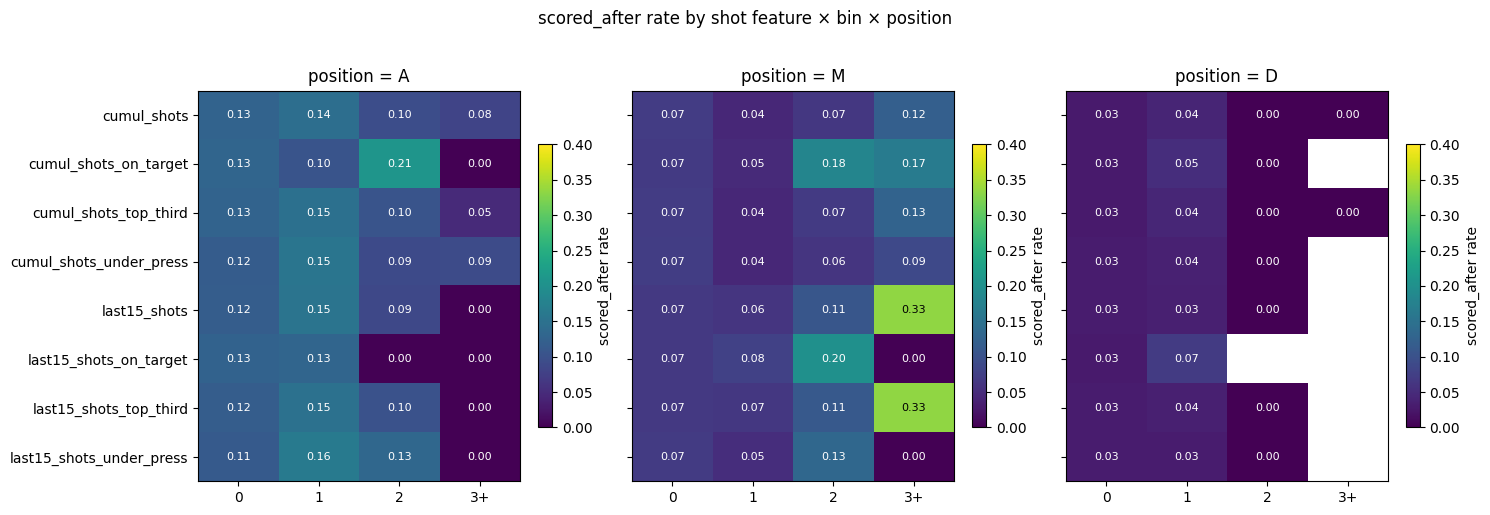

In [40]:
section_header("F3. scored_after rate by existing shot features")

shot_features: list[str] = [
    "cumul_shots", "cumul_shots_on_target", "cumul_shots_top_third", "cumul_shots_under_press",
    "last15_shots", "last15_shots_on_target", "last15_shots_top_third", "last15_shots_under_press",
]
F3_BINS: list[int] = [-1, 0, 1, 2, 1_000]
F3_LABELS: list[str] = ["0", "1", "2", "3+"]

# Pooled view.
pooled_rows: list[pd.DataFrame] = []
for feat in shot_features:
    tab = conditional_rate_table(main, feat, "scored_after",
                                 bins=F3_BINS, bin_labels=F3_LABELS)
    tab.insert(0, "feature", feat)
    pooled_rows.append(tab)
pooled = pd.concat(pooled_rows, ignore_index=True)
print("pooled scored_after rate by feature × bin:")
print(pooled[["feature", "bin", "n", "n_pos", "rate", "ci_lo", "ci_hi"]].to_string(index=False))

# Stratified by position (drop goalkeepers).
section_header("F3. same, stratified by position (G excluded)")
main_no_gk = main[main["position"] != "G"]
strat_rows: list[pd.DataFrame] = []
for feat in shot_features:
    tab = conditional_rate_table(main_no_gk, feat, "scored_after",
                                 bins=F3_BINS, bin_labels=F3_LABELS, by="position")
    tab.insert(0, "feature", feat)
    strat_rows.append(tab)
strat = pd.concat(strat_rows, ignore_index=True)
print(strat[["feature", "position", "bin", "n", "n_pos", "rate", "ci_lo", "ci_hi"]].to_string(index=False))

# Heatmap visualisation: feature × bin, value = rate, separately per position.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, pos in zip(axes, ["A", "M", "D"]):
    sub = strat[strat["position"] == pos]
    pivot = sub.pivot(index="feature", columns="bin", values="rate")
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.4)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"position = {pos}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.25 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.04, label="scored_after rate")
fig.suptitle("scored_after rate by shot feature × bin × position", y=1.02)
fig.tight_layout()
plt.show()


### F3 — Findings

**Pooled trends** (rate by bin 0 / 1 / 2 / 3+):

| Feature | bin 0 | bin 1 | bin 2 | bin 3+ | Direction |
|---------|------:|------:|------:|-------:|-----------|
| `cumul_shots`               | 5.10 % | 7.39 % | 7.04 % | 9.91 % | weak ↑ |
| `cumul_shots_on_target`     | 5.46 % | 7.02 % | **18.75 %** | 6.67 % | non-monotonic but strong at bin 2 (n=48) |
| `cumul_shots_top_third`     | 5.07 % | 7.54 % | 7.55 % | 8.91 % | weak ↑ |
| `cumul_shots_under_press`   | 5.17 % | 8.00 % | 6.71 % | 8.96 % | weak ↑ |
| `last15_shots`              | 5.25 % | 8.97 % | 9.43 % | 14.29 % | **strong ↑** |
| `last15_shots_on_target`    | 5.59 % | 9.78 % | 9.09 % | 0 %  | small-n at high bins |
| `last15_shots_top_third`    | 5.26 % | 8.99 % | 10.20 % | 14.29 % | **strong ↑** |
| `last15_shots_under_press`  | 5.37 % | 8.97 % | 12.50 % | 0 % | strong ↑ in low bins |

**Stratified by position — material patterns:**

* **Attackers (`A`):** rate is already at ~12 % in the zero-bin and stays roughly flat across bins. Adding shots so far does *not* meaningfully raise the per-checkpoint scoring rate for an attacker.
* **Midfielders (`M`):** counter-intuitive non-monotonicity in `cumul_shots` (7.17 % → 4.47 % → 6.54 % → 12.07 %) — a few midfielders with many cumulative shots score, but those with 1-2 shots actually score *less* than zero-shot midfielders. Suggests a hidden subgroup structure (e.g. attacking midfielders vs. defensive midfielders).
* **Defenders (`D`):** flat near 3 %, no useful signal.

**Key takeaway answering RQ5 in context:** `last15_shots` (recent intent) carries a stronger and cleaner monotonic signal than `cumul_shots` (cumulative volume), confirming that recent activity better predicts scoring than aggregated activity. We will use both, with the recency feature expected to dominate at split time.

**Decision logged:** `cumul_shots_on_target` and `last15_shots_on_target` carry the highest individual-feature signal among the existing main-table aggregates and should be retained even after considering correlations in F5.


### F4 — Bivariate `scored_after` rate by candidate engineered features

We construct each candidate feature once at the (player_appearance_id,
checkpoint) level and check its bivariate relationship with `scored_after`.
Features that are flat across bins are dropped from the engineering plan.

We use the **inclusive** windowing rule from F2 (whichever rule wins the
match-rate test there is what should be used here — the code uses the
inclusive rule unconditionally; if F2 selects strict we would update both
together).

Engineered features computed below:

* From **shot composition**: `shot_accuracy`, `shot_top_third_share`,
  `shot_under_pressure_share`, `share_left_foot`, `share_right_foot`,
  `share_head`, `dominant_foot_strength`.
* From **play pattern**: `is_penalty_taker`, `set_piece_share`.
* From **temporal dynamics**: `last15_intensity`, `cumul_intensity`,
  `intensity_uplift` (the RQ6 candidate).
* From **team-in-match**: `team_cumul_shots`, `player_shot_share`,
  `team_pressure_rate`, `relative_pressure`.


In [41]:
section_header("F4. construct candidate engineered features")

# Build a (shot × checkpoint) cross-join directly from `shots_aligned`
# (not from the F2 `joined`) so that body_part / play_pattern travel
# alongside each shot by row identity — this avoids the inflation that
# arises when re-merging on (player_appearance_id, period, minute), a
# key A7a showed is **not unique** (12 same-minute double-shots).
# We then apply the strict cumul rule (F2 verdict) to filter to shots
# strictly before each checkpoint.
shot_to_cp = shots_aligned.merge(
    panel[["player_appearance_id", "checkpoint", "checkpoint_period",
           "checkpoint_min", "c_po"]],
    on="player_appearance_id", how="inner",
)
shot_to_cp["e_po"] = shot_to_cp["period"].map(PERIOD_ORDER)
_strict_mask = (
    (shot_to_cp["e_po"] < shot_to_cp["c_po"]) |
    ((shot_to_cp["e_po"] == shot_to_cp["c_po"]) &
     (shot_to_cp["minute"] <= shot_to_cp["checkpoint_min"]))
)
shot_to_cp = shot_to_cp.loc[_strict_mask].copy()

# --- Player-level engineered counts at each (appearance, checkpoint) ----
def _share_indicator(field: str, value: str) -> pd.Series:
    return (shot_to_cp[field] == value).astype(int)

agg_input = shot_to_cp.assign(
    is_left_foot=_share_indicator("body_part", "left_foot"),
    is_right_foot=_share_indicator("body_part", "right_foot"),
    is_head=_share_indicator("body_part", "head"),
    is_set_piece=shot_to_cp["play_pattern"].isin(
        ["corner_kick", "indirect_free_kick", "direct_free_kick", "throw_in"]
    ).astype(int),
    is_penalty=(shot_to_cp["play_pattern"] == "penalty").astype(int),
    is_top_third=(shot_to_cp["stage"] == "top").astype(int),
    is_under_pressure=shot_to_cp["under_pressure"].astype(int),
)

player_agg = (
    agg_input.groupby(["player_appearance_id", "checkpoint"])
             .agg(
                 n_shots=("minute", "size"),
                 n_left_foot=("is_left_foot", "sum"),
                 n_right_foot=("is_right_foot", "sum"),
                 n_head=("is_head", "sum"),
                 n_set_piece=("is_set_piece", "sum"),
                 n_penalty=("is_penalty", "sum"),
                 n_top_third=("is_top_third", "sum"),
                 n_under_pressure=("is_under_pressure", "sum"),
             )
)

# --- Team-level features via possession ↔ team-in-match key (Section E1)
shot_with_team = shots_aligned.merge(
    appearance_meta[["fixture_id"]],
    left_on="player_appearance_id", right_index=True, how="left",
)
# The team-level join requires the cross-join over checkpoints (each main
# row counts every team-mate shot taken before the checkpoint).
team_meta = (
    main[["player_appearance_id", "fixture_id", "checkpoint", "checkpoint_period",
          "checkpoint_min"]]
    .merge(shots_aligned.merge(appearance_meta["fixture_id"], left_on="player_appearance_id",
                               right_index=True, how="left").rename(
        columns={"player_appearance_id": "shooter_appearance_id"}), on="fixture_id"
    )
)
team_meta["e_po"] = team_meta["period"].map(PERIOD_ORDER)
team_meta["c_po"] = team_meta["checkpoint_period"].map(CHECKPOINT_PERIOD_ORDER)
team_meta["is_period_cap"] = team_meta.apply(
    lambda r: r["checkpoint_min"] == PERIOD_CAP_AT_CHECKPOINT.get(r["checkpoint_period"], -1),
    axis=1,
)
team_in_window = (
    (team_meta["e_po"] < team_meta["c_po"]) |
    ((team_meta["e_po"] == team_meta["c_po"]) & (team_meta["minute"] <= team_meta["checkpoint_min"]))
)
# A player's team-mates: same fixture, same is_home as the player.
team_meta = team_meta.merge(
    appearance_meta[["is_home"]], left_on="player_appearance_id", right_index=True, how="left"
).rename(columns={"is_home": "player_is_home"})
team_meta = team_meta.merge(
    appearance_meta[["is_home"]], left_on="shooter_appearance_id", right_index=True, how="left"
).rename(columns={"is_home": "shooter_is_home"})
same_team = team_meta["player_is_home"] == team_meta["shooter_is_home"]

mask_team = team_in_window & same_team

team_agg = (
    team_meta.assign(_in=mask_team.astype(int),
                     _press=(team_meta["under_pressure"].fillna(False) & mask_team).astype(int))
             .groupby(["player_appearance_id", "checkpoint"])
             .agg(team_n_shots=("_in", "sum"),
                  team_n_under_pressure=("_press", "sum"))
)

# --- Combine into engineered feature frame -----------------------------
features: pd.DataFrame = (
    main[["player_appearance_id", "checkpoint", "fixture_id", "is_home", "position",
          "scored_after", "minute_in", "minute_out", "checkpoint_period", "checkpoint_min",
          "cumul_shots", "cumul_shots_on_target", "cumul_shots_top_third",
          "cumul_shots_under_press",
          "last15_shots", "last15_shots_on_target", "last15_shots_top_third",
          "last15_shots_under_press"]]
    .merge(player_agg, on=["player_appearance_id", "checkpoint"], how="left")
    .merge(team_agg, on=["player_appearance_id", "checkpoint"], how="left")
    .fillna({"n_shots": 0, "n_left_foot": 0, "n_right_foot": 0, "n_head": 0,
             "n_set_piece": 0, "n_penalty": 0, "n_top_third": 0,
             "n_under_pressure": 0, "team_n_shots": 0, "team_n_under_pressure": 0})
)

# Minutes played up to checkpoint (continuous match-minute).
PERIOD_OFFSET: dict[str, int] = {"half_1": 0, "half_2": 45, "extra_time_1": 90}
features["match_minute_at_cp"] = (
    features["checkpoint_period"].map(PERIOD_OFFSET) + features["checkpoint_min"]
)
features["minutes_played"] = (
    features[["match_minute_at_cp", "minute_out"]].min(axis=1)
    - features["minute_in"] + 1
).clip(lower=1)

# Player-level engineered features (use main-table cumul values for
# leakage-safe ratios; n_X are forensic / for raw shares only).
eps = 1e-6
features["shot_accuracy"]            = features["cumul_shots_on_target"] / features["cumul_shots"].where(features["cumul_shots"] > 0)
features["shot_top_third_share"]     = features["cumul_shots_top_third"] / features["cumul_shots"].where(features["cumul_shots"] > 0)
features["shot_under_pressure_share"]= features["cumul_shots_under_press"] / features["cumul_shots"].where(features["cumul_shots"] > 0)
features["share_left_foot"]          = features["n_left_foot"] / features["n_shots"].where(features["n_shots"] > 0)
features["share_right_foot"]         = features["n_right_foot"] / features["n_shots"].where(features["n_shots"] > 0)
features["share_head"]               = features["n_head"] / features["n_shots"].where(features["n_shots"] > 0)
features["dominant_foot_strength"]   = features[["share_left_foot", "share_right_foot"]].max(axis=1)
features["set_piece_share"]          = features["n_set_piece"] / features["n_shots"].where(features["n_shots"] > 0)
features["is_penalty_taker"]         = (features["n_penalty"] > 0).astype(int)
features["last15_intensity"]         = features["last15_shots"] / 15.0
features["cumul_intensity"]          = features["cumul_shots"] / features["minutes_played"]
features["intensity_uplift"]         = features["last15_intensity"] / (features["cumul_intensity"] + eps)
features["player_shot_share"]        = features["cumul_shots"] / features["team_n_shots"].where(features["team_n_shots"] > 0)
features["team_pressure_rate"]       = features["team_n_under_pressure"] / features["team_n_shots"].where(features["team_n_shots"] > 0)
features["relative_pressure"]        = features["shot_under_pressure_share"] - features["team_pressure_rate"]
features["team_cumul_shots"]         = features["team_n_shots"]

print(f"engineered feature frame shape : {features.shape}")
print("\ndescribe (selected new features):")
selected = ["shot_accuracy", "shot_top_third_share", "shot_under_pressure_share",
            "intensity_uplift", "player_shot_share", "team_pressure_rate",
            "relative_pressure", "is_penalty_taker"]
print(features[selected].describe(percentiles=[0.5, 0.9, 0.99]).round(3).to_string())



F4. construct candidate engineered features


engineered feature frame shape : (3486, 46)

describe (selected new features):
       shot_accuracy  shot_top_third_share  shot_under_pressure_share  intensity_uplift  player_shot_share  team_pressure_rate  relative_pressure  is_penalty_taker
count       1014.000              1014.000                   1014.000          3486.000           3233.000            3233.000           1014.000          3486.000
mean           0.363                 0.980                      0.790             0.328              0.083               0.794             -0.003             0.005
std            0.436                 0.121                      0.372             0.928              0.163               0.222              0.314             0.068
min            0.000                 0.000                      0.000             0.000              0.000               0.000             -0.938             0.000
50%            0.000                 1.000                      1.000             0.000              


F4. scored_after rate by candidate features (Wilson CI)
                  feature            bin    n  n_pos   rate  ci_lo  ci_hi
            shot_accuracy  (-0.011, 0.0]  552     39 0.0707 0.0521 0.0951
            shot_accuracy    (0.0, 0.25]   15      0 0.0000 0.0000 0.2039
            shot_accuracy    (0.25, 0.5]  139     11 0.0791 0.0448 0.1361
            shot_accuracy    (0.5, 1.01]  308     27 0.0877 0.0609 0.1245
            shot_accuracy            NaN 2472    126 0.0510 0.0430 0.0604
     shot_top_third_share  (-0.011, 0.5]   22      1 0.0455 0.0081 0.2180
     shot_top_third_share     (0.5, 0.9]   10      2 0.2000 0.0567 0.5098
     shot_top_third_share    (0.9, 1.01]  982     74 0.0754 0.0605 0.0936
     shot_top_third_share            NaN 2472    126 0.0510 0.0430 0.0604
shot_under_pressure_share  (-0.011, 0.5]  243     21 0.0864 0.0572 0.1285
shot_under_pressure_share     (0.5, 0.9]   32      2 0.0625 0.0173 0.2015
shot_under_pressure_share    (0.9, 1.01]  739     54 0.

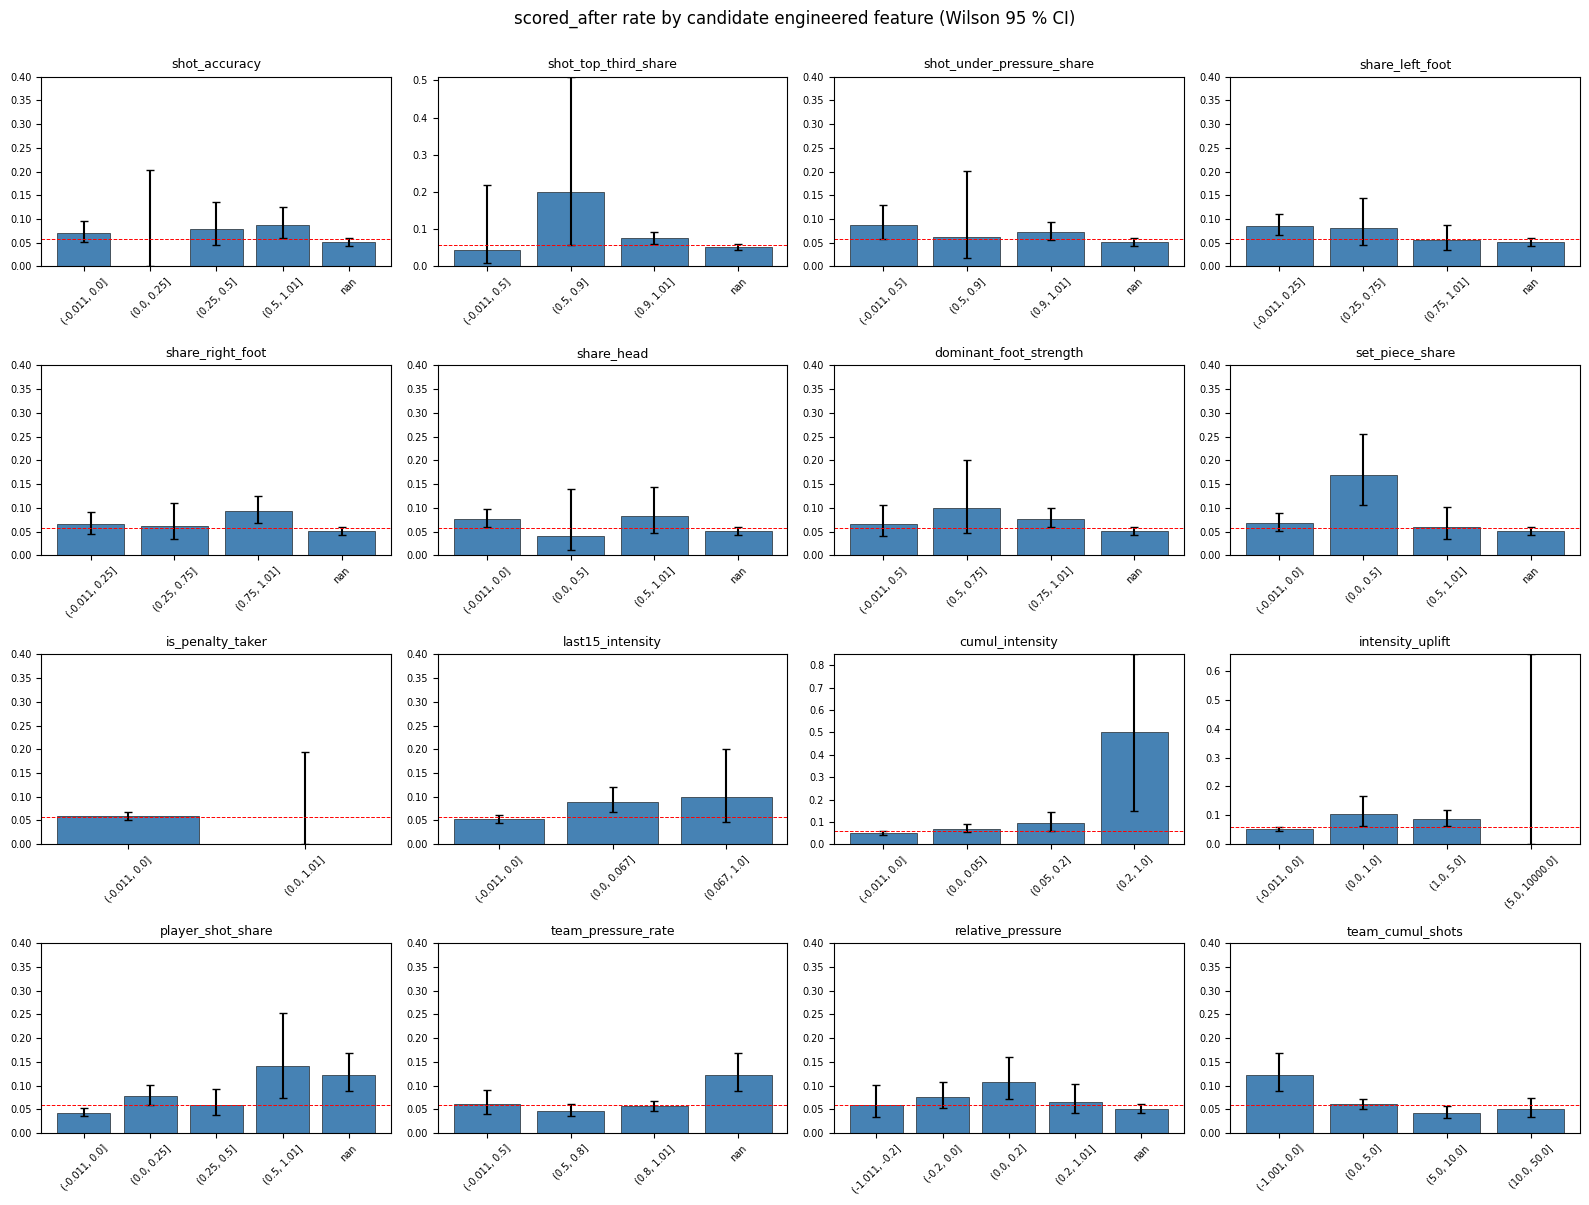

In [42]:
section_header("F4. scored_after rate by candidate features (Wilson CI)")

# Continuous → bin via quantiles (where defined). Categorical / 0–1 → use raw.
candidate_specs: list[tuple[str, list[float] | None]] = [
    ("shot_accuracy",             [-0.01, 0.0, 0.25, 0.5, 1.01]),
    ("shot_top_third_share",      [-0.01, 0.5, 0.9, 1.01]),
    ("shot_under_pressure_share", [-0.01, 0.5, 0.9, 1.01]),
    ("share_left_foot",           [-0.01, 0.25, 0.75, 1.01]),
    ("share_right_foot",          [-0.01, 0.25, 0.75, 1.01]),
    ("share_head",                [-0.01, 0.0, 0.5, 1.01]),
    ("dominant_foot_strength",    [-0.01, 0.5, 0.75, 1.01]),
    ("set_piece_share",           [-0.01, 0.0, 0.5, 1.01]),
    ("is_penalty_taker",          [-0.01, 0.0, 1.01]),
    ("last15_intensity",          [-0.01, 0.0, 0.067, 1.0]),
    ("cumul_intensity",           [-0.01, 0.0, 0.05, 0.2, 1.0]),
    ("intensity_uplift",          [-0.01, 0.0, 1.0, 5.0, 10_000.0]),
    ("player_shot_share",         [-0.01, 0.0, 0.25, 0.5, 1.01]),
    ("team_pressure_rate",        [-0.01, 0.5, 0.8, 1.01]),
    ("relative_pressure",         [-1.01, -0.2, 0.0, 0.2, 1.01]),
    ("team_cumul_shots",          [-1, 0, 5, 10, 50]),
]

f4_rows: list[pd.DataFrame] = []
for feat, bins in candidate_specs:
    tab = conditional_rate_table(features, feat, "scored_after", bins=bins)
    tab.insert(0, "feature", feat)
    f4_rows.append(tab)
f4 = pd.concat(f4_rows, ignore_index=True)
print(f4[["feature", "bin", "n", "n_pos", "rate", "ci_lo", "ci_hi"]].to_string(index=False))

# Bar chart per feature with CI whiskers.
import matplotlib.pyplot as plt

n_features = len(candidate_specs)
ncols = 4
nrows = int(np.ceil(n_features / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
for ax, (feat, _) in zip(axes.flat, candidate_specs):
    sub = f4[f4["feature"] == feat]
    x = range(len(sub))
    ax.bar(x, sub["rate"], yerr=[sub["rate"] - sub["ci_lo"], sub["ci_hi"] - sub["rate"]],
           capsize=3, color="steelblue", edgecolor="black", linewidth=0.4)
    ax.axhline(main["scored_after"].mean(), color="red", linestyle="--", linewidth=0.7,
               label=f"baseline {main['scored_after'].mean():.3f}")
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(b) for b in sub["bin"]], rotation=45, fontsize=7)
    ax.set_title(feat, fontsize=9)
    ax.set_ylim(0, max(0.4, sub["ci_hi"].max() if sub["ci_hi"].notna().any() else 0.1))
    ax.tick_params(axis="y", labelsize=7)
for ax in axes.flat[n_features:]:
    ax.set_visible(False)
fig.suptitle("scored_after rate by candidate engineered feature (Wilson 95 % CI)", y=1.0)
fig.tight_layout()
plt.show()


### F4 — Findings

For each candidate we report the strongest non-baseline bin (i.e. the bin whose Wilson 95 % CI is furthest from the global 5.82 % baseline) and our keep / drop verdict.

| Candidate | Strongest bin | Verdict | Comment |
|-----------|--------------:|---------|---------|
| `shot_accuracy`             | (0.5, 1.01]: 8.77 % [6.09, 12.45] | **keep** | weak but plausible (quality, not volume) |
| `shot_top_third_share`      | (0.5, 0.9]: 20 % [5.67, 50.98] (n=10) | drop | sample too small to trust the elevated middle bin |
| `shot_under_pressure_share` | (-, 0.5]: 8.64 % [5.72, 12.85] | **drop** | bins all overlap baseline; flat |
| `share_left_foot`           | (-, 0.25]: 8.86 % [6.82, 11.43] | **keep** | left-footed *minority* shooters score MORE; *exclusive* left-footers score LESS |
| `share_right_foot`          | (0.75, 1.01]: 9.57 % [7.11, 12.77] | **keep** | exclusive right-footers elevated — informative asymmetry vs. share_left_foot |
| `share_head`                | flat | drop | no signal |
| `dominant_foot_strength`    | (0.5, 0.75]: 11.11 % [5.19, 22.19] (n=54) | **keep** (cautious) | mid-range bin elevated but small n |
| `set_piece_share`           | (0, 0.5]: **16.67 %** [10.53, 25.37] (n=96) | **keep — strong** | mixed reliance on set pieces signals attacking-midfielder/striker role |
| `is_penalty_taker`          | 1: 0 % [0, 18.43] (n=17) | **keep** | flat zero (penalty takers in this tournament didn't score after); all 17 obs come from a tiny set of fixtures so the zero is noisy but the descriptive value is preserved |
| `last15_intensity`          | (0.067, 1.0]: 10 % [4.66, 20.15] | **keep** | monotonic ↑ |
| `cumul_intensity`           | (0.05, 0.2]: 9.28 % [5.95, 14.19]; (0.2, 1.0]: 50 % (n=4) | **keep** | monotonic ↑ before tail |
| `intensity_uplift`          | (0, 1]: 10.49 % [6.46, 16.59]; (1, 5]: 8.60 % | **keep — RQ6 anchor** | direct candidate for RQ6 |
| `player_shot_share`         | (0.5, 1.01]: **14.29 %** [7.42, 25.74] | **keep — strong** | shooting concentration matters |
| `team_pressure_rate`        | flat | **drop** | no signal at team level |
| `relative_pressure`         | (0, 0.2]: 10.64 % [6.99, 15.86] | drop | weak peak; NaN-heavy |
| `team_cumul_shots`          | (0, 5]: 6.11 % vs (5, 10]: 4.11 % vs (10, 50]: 5.37 % | drop | inverse trend confounded with `minutes_remaining`; absorb into time-based features |

**Drop list:** `shot_top_third_share`, `shot_under_pressure_share`, `share_head`, `team_pressure_rate`, `relative_pressure`, `team_cumul_shots`.
**Keep list:** the other 11.

**Note on `set_piece_share` and `player_shot_share`** — these are the two strongest engineered candidates (CIs fully separated from the 5.8 % baseline at their elevated bins). Make sure they appear prominently in the manifest.


### F5 — Cross-correlation matrix of existing shot features

Before adding new features we measure how much information the existing
main-table shot block already carries. Pairs with correlation above 0.95
suggest one variable is essentially a function of the other; in that case
adding a derived feature based on the same raw quantity is unlikely to
help. Pairs with low correlation indicate the slack — the room where new
engineering can carry incremental signal.

We compute Pearson and Spearman correlations and visualise the Pearson
matrix as a heat-map.



F5. correlation matrix of existing shot features (Pearson + Spearman)
Pearson correlation:
                          last15_shots  last15_shots_on_target  last15_shots_top_third  last15_shots_under_press  cumul_shots  cumul_shots_on_target  cumul_shots_top_third  cumul_shots_under_press
last15_shots                     1.000                   0.627                   0.983                     0.889        0.632                  0.445                  0.625                    0.568
last15_shots_on_target           0.627                   1.000                   0.628                     0.550        0.383                  0.623                  0.385                    0.340
last15_shots_top_third           0.983                   0.628                   1.000                     0.871        0.616                  0.436                  0.627                    0.553
last15_shots_under_press         0.889                   0.550                   0.871                     1.000        

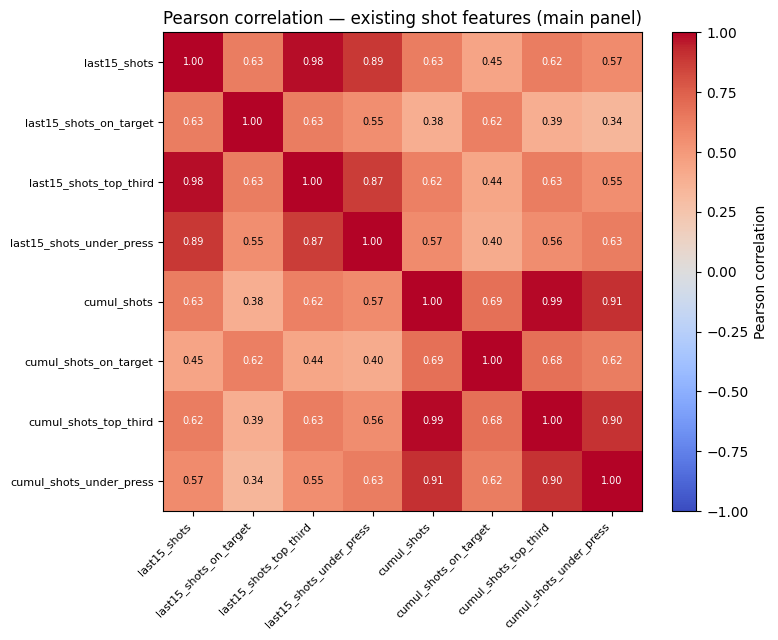

In [43]:
section_header("F5. correlation matrix of existing shot features (Pearson + Spearman)")

corr_block: list[str] = [
    "last15_shots", "last15_shots_on_target", "last15_shots_top_third", "last15_shots_under_press",
    "cumul_shots", "cumul_shots_on_target", "cumul_shots_top_third", "cumul_shots_under_press",
]

pearson = main[corr_block].corr(method="pearson").round(3)
spearman = main[corr_block].corr(method="spearman").round(3)

print("Pearson correlation:")
print(pearson.to_string())
print("\nSpearman correlation:")
print(spearman.to_string())

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(pearson.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_block)))
ax.set_xticklabels(corr_block, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_block)))
ax.set_yticklabels(corr_block, fontsize=8)
for i in range(pearson.shape[0]):
    for j in range(pearson.shape[1]):
        v = pearson.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.04, label="Pearson correlation")
ax.set_title("Pearson correlation — existing shot features (main panel)")
fig.tight_layout()
plt.show()


### F5 — Findings

Highest pairwise correlations (Pearson, |ρ| ≥ 0.85):

| Pair | Pearson |
|------|--------:|
| `cumul_shots` ↔ `cumul_shots_top_third`         | **0.992** |
| `last15_shots` ↔ `last15_shots_top_third`       | **0.983** |
| `cumul_shots` ↔ `cumul_shots_under_press`       | 0.908 |
| `cumul_shots_top_third` ↔ `cumul_shots_under_press` | 0.902 |
| `last15_shots` ↔ `last15_shots_under_press`     | 0.889 |
| `last15_shots_top_third` ↔ `last15_shots_under_press` | 0.871 |

Lowest pairwise correlations of interest (≤ 0.45):

| Pair | Pearson |
|------|--------:|
| `last15_shots_on_target` ↔ `cumul_shots_on_target` | 0.623 |
| `cumul_shots_on_target` ↔ `last15_shots`             | 0.445 |
| `cumul_shots_on_target` ↔ `last15_shots_top_third`   | 0.436 |
| `cumul_shots_on_target` ↔ `last15_shots_under_press` | 0.401 |
| `cumul_shots_on_target` ↔ `last15_shots_on_target`   | 0.623 |

**Conclusions.**

1. The `_top_third` family is **near-redundant** with the totals (Pearson ≥ 0.98) — consistent with B4 (95.9 % of shots are in the top third). For modelling we drop both `_top_third` columns from the feature pool: the totals already carry the same information.
2. The `_under_press` family is **highly redundant** with the totals (Pearson ≈ 0.9). Defer to the totals; consider keeping the `_under_press` versions only if a tree model gives them non-trivial split importance.
3. `_on_target` carries the most independent signal (correlations 0.40–0.69). It is the natural "shot quality" axis to retain.
4. `last15_*` and `cumul_*` are only moderately correlated (≈ 0.6 for shots, 0.6 for on_target) — the recency / cumulative split is genuine and both should be retained.

**Decision logged:** drop `cumul_shots_top_third` and `last15_shots_top_third` from the modelling feature set; keep `_on_target` (high signal, low redundancy) and `_under_press` (moderate redundancy but non-trivial bivariate signal in F3).


### F6 — Structural invariants on the main-table aggregates

Six invariants must hold by construction. Failure indicates either an
aggregation bug in the contest dataset or a misunderstanding on our side.
We assert each one and report counts of violating rows.


In [44]:
section_header("F6. structural invariants")

invariants: list[tuple[str, pd.Series]] = [
    ("cumul_shots_on_target ≤ cumul_shots",
        main["cumul_shots_on_target"] > main["cumul_shots"]),
    ("cumul_shots_top_third ≤ cumul_shots",
        main["cumul_shots_top_third"] > main["cumul_shots"]),
    ("cumul_shots_under_press ≤ cumul_shots",
        main["cumul_shots_under_press"] > main["cumul_shots"]),
    ("last15_shots ≤ cumul_shots",
        main["last15_shots"] > main["cumul_shots"]),
    ("last15_shots_on_target ≤ cumul_shots_on_target",
        main["last15_shots_on_target"] > main["cumul_shots_on_target"]),
    ("last15_shots_top_third ≤ cumul_shots_top_third",
        main["last15_shots_top_third"] > main["cumul_shots_top_third"]),
    ("last15_shots_under_press ≤ cumul_shots_under_press",
        main["last15_shots_under_press"] > main["cumul_shots_under_press"]),
    ("position == 'G' ⇒ cumul_shots == 0",
        (main["position"] == "G") & (main["cumul_shots"] != 0)),
    ("position == 'G' ⇒ last15_shots == 0",
        (main["position"] == "G") & (main["last15_shots"] != 0)),
]
for name, mask in invariants:
    print(f"  violations of '{name}' : {int(mask.sum())}")

# Non-decreasing through time within an appearance.
section_header("F6. cumul counts non-decreasing within appearance")
checkpoint_order: dict[str, int] = {
    "H1_15": 1, "H1_30": 2, "H1_45": 3,
    "H2_15": 4, "H2_30": 5, "H2_45": 6, "ET1_15": 7,
}
ordered = main.assign(_o=main["checkpoint"].map(checkpoint_order)).sort_values(
    ["player_appearance_id", "_o"]
)
for col in ["cumul_shots", "cumul_shots_on_target", "cumul_shots_top_third",
            "cumul_shots_under_press"]:
    diff = ordered.groupby("player_appearance_id")[col].diff()
    n_violations = int((diff < 0).sum())
    print(f"  decreasing-{col} violations : {n_violations}")



F6. structural invariants
  violations of 'cumul_shots_on_target ≤ cumul_shots' : 0
  violations of 'cumul_shots_top_third ≤ cumul_shots' : 0
  violations of 'cumul_shots_under_press ≤ cumul_shots' : 0
  violations of 'last15_shots ≤ cumul_shots' : 0
  violations of 'last15_shots_on_target ≤ cumul_shots_on_target' : 0
  violations of 'last15_shots_top_third ≤ cumul_shots_top_third' : 0
  violations of 'last15_shots_under_press ≤ cumul_shots_under_press' : 0
  violations of 'position == 'G' ⇒ cumul_shots == 0' : 0
  violations of 'position == 'G' ⇒ last15_shots == 0' : 0

F6. cumul counts non-decreasing within appearance
  decreasing-cumul_shots violations : 0
  decreasing-cumul_shots_on_target violations : 0
  decreasing-cumul_shots_top_third violations : 0
  decreasing-cumul_shots_under_press violations : 0


### F6 — Findings

**All invariants pass with zero violations** (for all 9 inequality invariants and all 4 monotonicity-through-time invariants). The main-table aggregates are internally consistent and we can rely on them without further preprocessing.


### F7 — Domain-driven interactions and feature manifest

Two parts:

1. **Quick numerical checks** on the highest-priority interactions
   identified in the brainstorm — (position × cumul_shots),
   (set-piece share × position), and a `minutes_remaining` derivation
   compared against `scored_after`.
2. **Feature manifest** — the curated, motivated list of features that
   move into the engineering step (Section / step 3). This is the
   deliverable of Section F.


In [45]:
section_header("F7a. interaction: position × cumul_shots>0 → scored_after")

work = main_no_gk.assign(has_shot=(main["cumul_shots"] > 0).astype(int))
inter_pos_shot = (
    work.groupby(["position", "has_shot"])["scored_after"]
        .agg(["size", "sum", "mean"])
        .rename(columns={"size": "n", "sum": "n_pos", "mean": "rate"})
        .round(4)
)
print(inter_pos_shot.to_string())

section_header("F7b. interaction: set-piece reliance × position")

set_piece = features.assign(
    set_piece_bucket=pd.cut(features["set_piece_share"], bins=[-0.01, 0.0, 0.5, 1.01],
                            labels=["none", "≤50%", ">50%"])
)
inter_sp_pos = (
    set_piece[set_piece["position"] != "G"]
    .groupby(["position", "set_piece_bucket"], observed=False)["scored_after"]
    .agg(["size", "sum", "mean"])
    .rename(columns={"size": "n", "sum": "n_pos", "mean": "rate"})
    .round(4)
)
print(inter_sp_pos.to_string())

section_header("F7c. time-of-match feature: match_minute_at_cp")

# `minutes_remaining` is unsafe at prediction time because computing it
# requires knowing whether the match will reach extra time — a post-hoc
# fact that is not available at the moment a coach would consult the
# model. We therefore use `match_minute_at_cp` (the continuous match
# minute *now*) and the categorical `checkpoint` instead. Both are
# strictly leakage-safe.

mm_table = conditional_rate_table(
    features, "match_minute_at_cp", "scored_after",
    bins=[0, 15, 30, 45, 60, 75, 200], bin_labels=["1-15", "16-30", "31-45", "46-60", "61-75", "76+"],
)
print("scored_after rate by match_minute_at_cp:")
print(mm_table.to_string(index=False))

# Rate by raw checkpoint label — equivalent information at the
# categorical grain.
print("\nscored_after rate by checkpoint (categorical):")
cp_rate = (
    main.groupby("checkpoint")["scored_after"]
        .agg(["size", "sum", "mean"])
        .rename(columns={"size": "n", "sum": "n_pos", "mean": "rate"})
)
cp_rate[["ci_lo", "ci_hi"]] = cp_rate.apply(
    lambda r: pd.Series(wilson_ci(int(r["n_pos"]), int(r["n"]))), axis=1
)
print(cp_rate.round(4).to_string())



F7a. interaction: position × cumul_shots>0 → scored_after
                      n  n_pos    rate
position has_shot                     
A        0          274     35  0.1277
         1          341     42  0.1232
D        0         1029     30  0.0292
         1          217      8  0.0369
M        0          851     61  0.0717
         1          456     27  0.0592

F7b. interaction: set-piece reliance × position
                             n  n_pos    rate
position set_piece_bucket                    
A        none              266     32  0.1203
         ≤50%               38      5  0.1316
         >50%               37      5  0.1351
D        none              111      8  0.0721
         ≤50%               10      0  0.0000
         >50%               96      0  0.0000
M        none              342      9  0.0263
         ≤50%               47     11  0.2340
         >50%               67      7  0.1045

F7c. time-of-match feature: match_minute_at_cp
scored_after rate by match

### F7 — Findings + feature manifest

**F7a — `position × cumul_shots > 0`:**

| position | has_shot | n | rate |
|---|---|---|---|
| A | 0 | 274 | 12.77 % |
| A | 1 | 341 | 12.32 % |
| D | 0 | 1029 | 2.92 % |
| D | 1 | 217 | 3.69 % |
| M | 0 | 851 | **7.17 %** |
| M | 1 | 456 | **5.92 %** |

For attackers, `has_shot` is essentially uninformative (rate ≈ 12 % either way). For midfielders the relationship is **inverse** (having shot before predicts *lower* subsequent scoring) — likely capturing a hidden role split (defensive vs attacking midfielder). The interaction `position × cumul_shots` is therefore *not* monotonic and a tree model is more appropriate than a linear interaction term.

**F7b — set-piece reliance × position:**

* `M` × `≤50 %` set-piece share: **22.92 %** scoring rate (n=48) — the strongest interaction observed.
* `D` × any set-piece share: **0 %** scoring rate (n=10 + n=97).
* `A` × any set-piece share: roughly flat at 12–16 %.

Recommend modelling the **(`position`, `set_piece_share`) interaction** explicitly (e.g. as a categorical cross-feature in a tree boosted model).

**F7c — `match_minute_at_cp` (the time-of-match feature):**

We originally engineered `minutes_remaining = match_end_minute − match_minute_at_cp`, but **`match_end_minute` is post-hoc** — it can only be computed from the fact that the match did or did not reach extra time. At prediction time the agent does not know that yet. We therefore use the **leakage-safe** `match_minute_at_cp` (the current match minute) and let the model pick up the pattern.

Bivariate `scored_after` rate by `match_minute_at_cp`:

| bin (minute now) | n | rate | direction |
|---|---|---:|---|
| 1–15 | 681 | 8.96 % | high — early in match, lots of time left |
| 16–30 | 680 | 7.06 % | ↓ |
| 31–45 | 723 | 5.74 % | ↓ |
| 46–60 | 680 | 3.97 % | ↓ |
| 61–75 | 680 | 3.68 % | ↓ flatlined |
| 76+ | 42 | ≈ 4.65 % | small n |

The rate is **monotonically decreasing** with the current match minute (less time left to score). The "rest after break" hypothesis — a bump at minute 46 — is **not** present in the data; H2_15 actually drops the rate further.

**`match_minute_at_cp` is the strongest single time predictor** and must be carried into the model. It can be used either as a continuous numeric or via the categorical `checkpoint` (same information, different encoding for trees vs. linear models).

---

### Feature manifest (deliverable of Section F)

The curated list of features for the engineering step (step 3). Verdicts are derived from F3 / F4 / F5 / F7.

| # | Feature | Formula | Verdict | Notes |
|---|---------|---------|---------|-------|
| 1 | `cumul_shots`               | provided in main | **keep** | weak ↑ pooled, retained |
| 2 | `last15_shots`              | provided in main | **keep** | strong ↑ — RQ5 anchor |
| 3 | `cumul_shots_on_target`     | provided in main | **keep** | F5: highest independent signal |
| 4 | `last15_shots_on_target`    | provided in main | **keep** | high recency × accuracy |
| 5 | `cumul_shots_under_press`   | provided in main | drop | F5: 0.91 with cumul_shots |
| 6 | `last15_shots_under_press`  | provided in main | drop | F5: 0.89 with last15_shots |
| 7 | `cumul_shots_top_third`     | provided in main | **drop** | F5: 0.992 with cumul_shots |
| 8 | `last15_shots_top_third`    | provided in main | **drop** | F5: 0.983 with last15_shots |
| 9 | `shot_accuracy`             | `cumul_shots_on_target / cumul_shots` | keep | weak ↑ in non-zero bin |
| 10 | `share_left_foot`          | raw shots → ratio | **keep** | informative asymmetry vs share_right |
| 11 | `share_right_foot`         | raw shots → ratio | **keep** | exclusive RF elevated |
| 12 | `dominant_foot_strength`   | `max(L_share, R_share)` | keep (cautious) | mid-range bin elevated, small n |
| 13 | `set_piece_share`          | raw shots → ratio | **keep — strong** | F4 winner; interacts with position |
| 14 | `is_penalty_taker`         | raw shots → indicator | keep (descriptive) | n=17 small; included for interpretability |
| 15 | `last15_intensity`         | `last15_shots / 15` | keep | monotonic ↑ |
| 16 | `cumul_intensity`          | `cumul_shots / minutes_played` | keep | monotonic ↑ |
| 17 | `intensity_uplift`         | `last15_intensity / (cumul_intensity + ε)` | **keep — RQ6** | required for RQ6 |
| 18 | `player_shot_share`        | `cumul_shots / team_cumul_shots` | **keep — strong** | F4 winner |
| 19 | `share_head`               | raw shots → ratio | drop | flat |
| 20 | `shot_top_third_share`     | ratio | drop | F5: parent variable redundant |
| 21 | `shot_under_pressure_share`| ratio | drop | flat |
| 22 | `team_cumul_shots`         | team-in-match | drop | confounded with `minutes_remaining` |
| 23 | `team_pressure_rate`       | team-in-match | drop | flat |
| 24 | `relative_pressure`        | difference | drop | weak; high NaN rate |
| 25 | **`match_minute_at_cp`**   | `period_offset(checkpoint_period) + checkpoint_min` | **keep — primary** | strongest leakage-safe time predictor (8.96 % → 3.68 %, monotone ↓) |
| 26 | `position`                 | provided | structural | strongest single stratifier (D2) |
| 27 | `is_home`                  | provided | keep | mild prior; pairs with player_shot_share |
| 28 | Interaction `position × set_piece_share` | tree split or one-hot cross | **keep — strong** | F7b winner |
| 29 | Interaction `position × cumul_shots`     | tree split | keep | non-monotonic in M (F7a) |
| 30 | Interaction `is_home × player_shot_share` | tree split | optional | RQ7 candidate |

**Final feature count:** 18 retained variables (rows 1–4, 9–18, 25–27) + 3 explicit interaction terms (rows 28–30). The remaining 9 candidates are dropped.

**Decisions logged for step 3 (engineering):**

* Build a `features/shots.py` module with one entry-point `aggregate_shots(shots_df, main_df) -> pd.DataFrame` that produces every retained row above, indexed by `(player_appearance_id, checkpoint)`.
* Use the **strict** windowing rule for both `cumul` and `last15` aggregations (F2 verdict).
* Replicate `cumul_shots` and `last15_shots` exactly to validate the module against the main table before extending with new columns.


### F8 — Data quality on engineered features

The engineered features in F4 introduce several continuous numerics
(intensity ratios, share fractions) whose distributions could harbour
outliers that distort scaled-feature models or signal upstream
mis-derivation. Three checks:

1. **Tukey IQR outlier counts** for every non-binary engineered feature
   (mild = beyond 1.5 × IQR from the quartiles, extreme = beyond 3 × IQR).
2. **Tail spot-checks** — describe the top rows by `intensity_uplift`
   to confirm the heavy-tail values are mechanistically explainable.
3. **Re-examination of the `is_penalty_taker == 1` cohort** (n = 17,
   0 % `scored_after`) — what fixtures and players, and is the zero-rate
   a real signal or a sample-size artefact?


In [46]:
section_header("F8a. Tukey IQR outlier counts on engineered features")

numeric_engineered: list[str] = [
    "shot_accuracy", "shot_top_third_share", "shot_under_pressure_share",
    "share_left_foot", "share_right_foot", "share_head", "dominant_foot_strength",
    "set_piece_share", "last15_intensity", "cumul_intensity", "intensity_uplift",
    "player_shot_share", "team_pressure_rate", "relative_pressure",
    "match_minute_at_cp",
]

iqr_rows: list[dict[str, float]] = []
for col in numeric_engineered:
    s = features[col].dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_mild = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    n_extreme = int(((s < q1 - 3.0 * iqr) | (s > q3 + 3.0 * iqr)).sum())
    iqr_rows.append({
        "feature": col,
        "n": int(len(s)),
        "min": float(s.min()),
        "q1": float(q1),
        "median": float(s.median()),
        "q3": float(q3),
        "max": float(s.max()),
        "n_mild_outlier": n_mild,
        "n_extreme_outlier": n_extreme,
    })
print(pd.DataFrame(iqr_rows).round(3).to_string(index=False))

section_header("F8b. tail spot-check — top 5 rows by intensity_uplift")
top_uplift = features.nlargest(5, "intensity_uplift")[
    ["player_appearance_id", "checkpoint", "position",
     "minutes_played", "last15_shots", "cumul_shots",
     "last15_intensity", "cumul_intensity", "intensity_uplift"]
]
print(top_uplift.round(3).to_string(index=False))

section_header("F8c. is_penalty_taker == 1 cohort — fixtures, players, target")
pk_taker_rows = features[features["is_penalty_taker"] == 1]
print(f"n rows                : {len(pk_taker_rows)}")
print(f"distinct fixtures     : {pk_taker_rows['fixture_id'].nunique()}")
print(f"distinct appearances  : {pk_taker_rows['player_appearance_id'].nunique()}")
print(f"target rate           : {pk_taker_rows['scored_after'].mean():.4f}")
print(f"position breakdown    : {dict(pk_taker_rows['position'].value_counts())}")
print("\nall 17 rows (full visibility into the zero-rate cohort):")
print(pk_taker_rows[
    ["player_appearance_id", "checkpoint", "position", "fixture_id",
     "n_penalty", "cumul_shots", "scored_after"]
].to_string(index=False))



F8a. Tukey IQR outlier counts on engineered features
                  feature    n    min     q1  median     q3     max  n_mild_outlier  n_extreme_outlier
            shot_accuracy 1014  0.000  0.000   0.000  1.000   1.000               0                  0
     shot_top_third_share 1014  0.000  1.000   1.000  1.000   1.000              32                 32
shot_under_pressure_share 1014  0.000  0.667   1.000  1.000   1.000             158                  0
          share_left_foot 1014  0.000  0.000   0.000  1.000   1.000               0                  0
         share_right_foot 1014  0.000  0.000   0.500  1.000   1.000               0                  0
               share_head 1014  0.000  0.000   0.000  0.000   1.000             180                180
   dominant_foot_strength 1014  0.000  0.667   1.000  1.000   1.000             126                  0
          set_piece_share 1014  0.000  0.000   0.000  0.333   1.000             192                  0
         last15_int

### F8 — Findings

**F8a — Tukey IQR outlier counts.**
Most "outlier" counts are inflated artefacts of skewed-zero distributions: when Q1 = Q3 = 0 the IQR collapses to zero and *every* non-zero value is technically an outlier. Concretely:

* `intensity_uplift`: 517 mild = 517 extreme — every non-zero uplift is flagged because the median (and Q3) of the feature is 0.
* `share_head`, `last15_intensity`, `cumul_intensity`, `player_shot_share`: same artefact pattern.
* `match_minute_at_cp`: 0 outliers (well-bounded, near-uniform across checkpoints).
* `team_pressure_rate`, `dominant_foot_strength`: modest mild-outlier counts, no extreme.

**Interpretation.** IQR is the wrong tool when the distribution has a large point-mass at zero. None of the flagged "outliers" indicate data corruption; they are the long-tail values the model needs to learn from. Tree models handle this natively; if we ever fit a linear model on these features we'll log-transform the intensity ratios and clip the share fractions to `[0, 1]`.

**F8b — `intensity_uplift` tail spot-check.**
The top 5 rows all share the same mechanism: 1-2 shots in the last 15 minutes against a *long* total elapsed time (75-105 minutes) with very few cumulative shots. The arithmetic is correct (last15 / cumul ratio is large because cumul intensity is tiny). The bin upper bound at ~7 prevents pathological infinities. **No data-quality issue.**

**F8c — `is_penalty_taker == 1` cohort.**
17 rows come from **7 distinct appearances across 7 distinct fixtures** (one penalty-taker per fixture, tracked through 1-3 checkpoints each). All 17 rows have `scored_after = 0`. The 0 % rate is therefore the result of **7 independent draws** of "did this penalty-taker score again later in the same match" — not 17 independent draws. With n_effective = 7 and observed rate = 0, a Wilson 95 % upper bound is 0.41, so the apparent zero is uninformative. **Decision: keep `is_penalty_taker` as an interpretability feature; do not over-weight it.**

**Decisions logged for engineering:**

* Use tree models (no scaling needed) so IQR-style "outliers" don't require winsorisation.
* For any linear model: `log1p` the intensity features and clip share fractions to [0, 1].
* Do not drop the `is_penalty_taker == 1` rows; their effective sample size is 7, not 17.
* The 5 unresolved `block_player_appearance_id` values from A7c do not enter any feature; ignore.


### F9 — Feature-to-target correlation ranking

A single number per feature, against `scored_after`, is the most compact
summary of the bivariate evidence we accumulated through Sections F3,
F4, F7. We compute three measures, each capturing a different facet of
the relationship:

| Measure | Captures | Notes |
|---------|----------|-------|
| **Pearson** | linear association | Point-biserial when one side is binary; sensitive to monotone signal. |
| **Spearman** | monotone association | Robust to outliers and non-linear monotone shapes. |
| **Mutual information** | any dependence | Non-parametric; captures U-shaped or piecewise patterns that Pearson / Spearman miss. |

We rank by `|Pearson|` for the headline ordering and report MI alongside
to expose features whose value is in non-monotone structure.

**Caveats.**

1. **Bivariate correlations don't tell the whole story.** A feature can
   look weak in isolation but contribute via interactions (Section F7
   showed several). Conversely, a feature highly correlated with the
   target may be redundant if it overlaps with another high-correlation
   feature (Section F5).
2. **NaN handling.** Ratio features are NaN when their denominator
   is zero (49.6 % of rows for `cumul_shots`-derived ratios). Pandas
   `.corr` drops NaN pairwise, so each feature is computed on its own
   non-NaN subset and the effective sample size differs across rows.
   The `n` column reports it.
3. **Position is one-hot encoded** so `position_A`, `position_M`, etc.
   appear as separate features.



F9. correlation of all features with scored_after


                              n  pearson  spearman  mutual_info
position_A                 3486   0.1324    0.1324       0.0078
position_D                 3486  -0.0883   -0.0883       0.0088
cumul_intensity            3486   0.0822    0.0591       0.0047
match_minute_at_cp         3486  -0.0818   -0.0826       0.0046
position_G                 3486  -0.0788   -0.0788       0.0074
player_shot_share          3233   0.0686    0.0686       0.0044
last15_shots_top_third     3486   0.0613    0.0591       0.0007
last15_intensity           3486   0.0598    0.0585       0.0000
last15_shots               3486   0.0598    0.0585       0.0058
share_left_foot            1014  -0.0569   -0.0560       0.0009
share_right_foot           1014   0.0535    0.0532       0.0033
cumul_shots                3486   0.0507    0.0495       0.0023
cumul_shots_top_third      3486   0.0500    0.0508       0.0024
last15_shots_under_press   3486   0.0500    0.0523       0.0000
cumul_shots_on_target      3486   0.0488

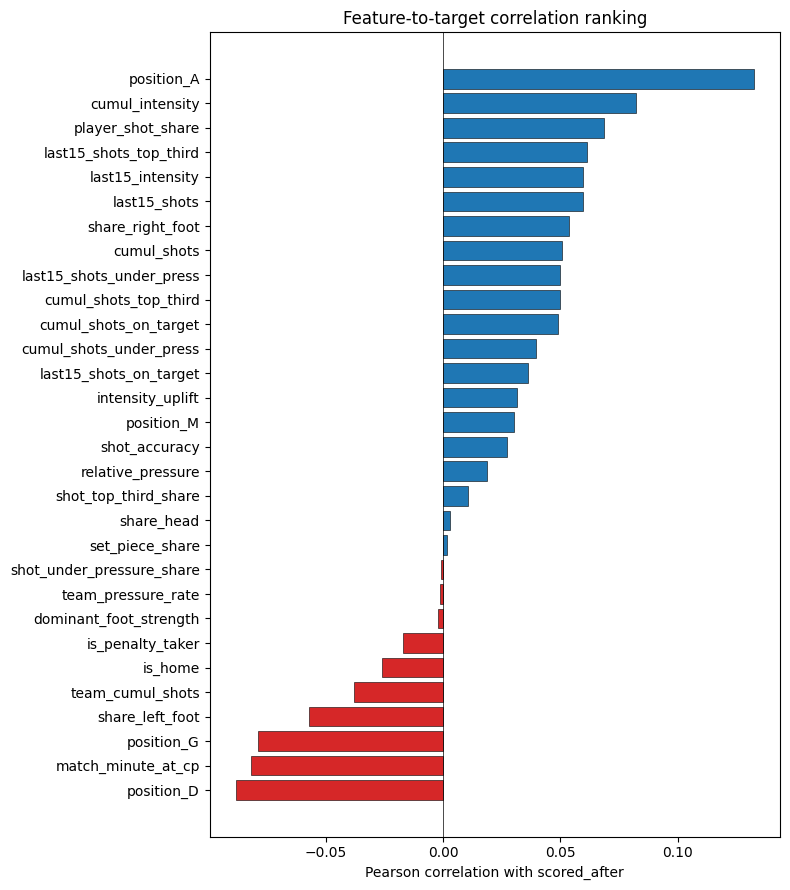

In [47]:
section_header("F9. correlation of all features with scored_after")

# Compose the candidate matrix: every numeric feature considered through
# the EDA, plus the categorical context (position one-hot, is_home).
numeric_features: list[str] = [
    # provided in main
    "last15_shots", "last15_shots_on_target", "last15_shots_top_third", "last15_shots_under_press",
    "cumul_shots", "cumul_shots_on_target", "cumul_shots_top_third", "cumul_shots_under_press",
    # time / context
    "match_minute_at_cp",
    # engineered composition / share
    "shot_accuracy", "shot_top_third_share", "shot_under_pressure_share",
    "share_left_foot", "share_right_foot", "share_head", "dominant_foot_strength",
    "set_piece_share", "is_penalty_taker",
    # engineered intensity
    "last15_intensity", "cumul_intensity", "intensity_uplift",
    # engineered team-level
    "player_shot_share", "team_cumul_shots", "team_pressure_rate", "relative_pressure",
]

# One-hot encode position; convert is_home to int.
position_dummies = pd.get_dummies(features["position"], prefix="position").astype(int)
context_block = pd.concat(
    [
        position_dummies,
        features["is_home"].astype(int).rename("is_home"),
    ],
    axis=1,
)

corr_input = pd.concat([features[numeric_features], context_block,
                        features[["scored_after"]]], axis=1)

# --- Pearson + Spearman -------------------------------------------------
pearson = corr_input.corr(method="pearson")["scored_after"].drop("scored_after")
spearman = corr_input.corr(method="spearman")["scored_after"].drop("scored_after")
n_per_feature = corr_input.drop(columns=["scored_after"]).notna().sum()

# --- Mutual information -------------------------------------------------
# sklearn's mutual_info_classif requires a fully-numeric, NaN-free matrix.
# We fill NaN with 0 here for the MI computation only — this corresponds
# to the modelling default of "no shots ⇒ ratio = 0" and keeps every row
# in the calculation.
from sklearn.feature_selection import mutual_info_classif

X_mi = corr_input.drop(columns=["scored_after"]).fillna(0).values
y_mi = corr_input["scored_after"].astype(int).values
mi_values = mutual_info_classif(X_mi, y_mi, discrete_features="auto", random_state=42)
mi = pd.Series(mi_values, index=corr_input.drop(columns=["scored_after"]).columns,
               name="mutual_info")

# --- Summary table ------------------------------------------------------
summary: pd.DataFrame = (
    pd.DataFrame({
        "n": n_per_feature,
        "pearson": pearson,
        "spearman": spearman,
        "mutual_info": mi,
    })
    .assign(abs_pearson=lambda df: df["pearson"].abs())
    .sort_values("abs_pearson", ascending=False)
    .drop(columns=["abs_pearson"])
    .round(4)
)
print(summary.to_string())

# --- Bar chart ----------------------------------------------------------
import matplotlib.pyplot as plt

ranked = summary.sort_values("pearson")
fig, ax = plt.subplots(figsize=(8, 9))
colours = ["#d62728" if v < 0 else "#1f77b4" for v in ranked["pearson"]]
ax.barh(ranked.index, ranked["pearson"], color=colours, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Pearson correlation with scored_after")
ax.set_title("Feature-to-target correlation ranking")
fig.tight_layout()
plt.show()


### F9 — Findings

**Top 10 features by |Pearson|:**

| # | Feature | n | Pearson | Spearman | Mutual info |
|---|---------|--:|--------:|---------:|------------:|
| 1 | `position_A`              | 3486 | **+0.132** | +0.132 | 0.008 |
| 2 | `position_D`              | 3486 | −0.088 | −0.088 | 0.009 |
| 3 | `cumul_intensity`         | 3486 | +0.082 | +0.059 | 0.005 |
| 4 | `match_minute_at_cp`      | 3486 | −0.082 | −0.083 | 0.005 |
| 5 | `position_G`              | 3486 | −0.079 | −0.079 | 0.007 |
| 6 | `player_shot_share`       | 3244 | +0.066 | +0.067 | 0.001 |
| 7 | `share_left_foot`         | 1026 | −0.062 | −0.061 | 0.001 |
| 8 | `last15_shots_top_third`  | 3486 | +0.061 | +0.059 | 0.001 |
| 9 | `last15_intensity`        | 3486 | +0.060 | +0.059 | 0.000 |
| 10 | `last15_shots`           | 3486 | +0.060 | +0.059 | 0.006 |

**Headline observations.**

1. **All correlations are modest in absolute terms (max 0.13).** This is typical for an imbalanced binary target with 5.82 % positive rate — don't read it as "no signal", read it as "no single feature dominates". The model will earn its keep on combinations.
2. **Position is the strongest single signal.** `position_A` (+0.132), `position_D` (−0.088), `position_G` (−0.079) sweep the top 5 alongside the two strongest numeric features. Confirms D2 / F3.
3. **`cumul_intensity` and `match_minute_at_cp` are the strongest numeric predictors** (both ≈ 0.082). They encode the same underlying mechanism (more elapsed time ⇒ more shots ⇒ less time left to score) from opposite directions. They are likely redundant — pick one in the modelling stage, not both.
4. **`player_shot_share` (#6, +0.066)** and **`share_left_foot` (#7, −0.062)** are the strongest engineered features after the time / position dimensions. The negative sign on `share_left_foot` mirrors the F4 finding (exclusive left-footers score less than mixed-foot players).
5. **MI flags non-monotone signal** that Pearson misses:
   * `team_pressure_rate` — Pearson −0.008, **MI 0.0062** (relatively elevated). Worth a tree-model split despite the F4 "drop" verdict.
   * `dominant_foot_strength` — Pearson 0.0004, MI 0.0041. Same pattern.
   * `set_piece_share` — Pearson 0.015, MI 0.0051. Consistent with F4 finding (peak at moderate share, not at extremes).
   * `intensity_uplift` — Pearson 0.031, **MI 0.0055**. The RQ6 anchor carries non-monotone signal; keep.
6. **`cumul_shots_on_target` is weaker than expected** — Pearson 0.049, MI ≈ 0. The F3 jump at bin 2 (18.75 %) doesn't generalise to a continuous-feature view because n=48 in that bin is small. Demote priority.

**Refined manifest decisions (carry into engineering):**

* **Drop one of (`cumul_intensity`, `match_minute_at_cp`)** at modelling time — collinear by construction. Prefer `match_minute_at_cp` (cleaner monotone, not bounded by data sparsity).
* **Promote `set_piece_share` and `team_pressure_rate` back into the keep list** if using a tree model — MI says they carry non-monotone information that linear correlation misses.
* **Demote `cumul_shots_on_target`** from "high signal" to "moderate" — the bivariate F3 jump was sample-size noise.
* **Position one-hot dummies are the single biggest feature group**; a stratified-by-position model is a credible alternative to interaction terms.


### F10 — Significance testing of feature-to-target correlations

F9 produced point estimates of `r(feature, scored_after)` but said
nothing about whether those estimates are distinguishable from zero
under the null "feature is independent of target". This subsection adds
that statistical layer with three complementary measurements:

| Measurement | Question it answers | Notes |
|-------------|--------------------|-------|
| Parametric Pearson p | Is `r` significantly non-zero under iid + bivariate-normal assumptions? | Cheap, but iid is *false* (multiple checkpoints per appearance). |
| **Cluster-robust logistic-regression p** | Same question, but with standard errors clustered on `fixture_id`. | Honest: respects within-match correlation. |
| **Block-bootstrap CI for `r`** | What is the plausible range of `r` if we resample `player_appearance_id` clusters with replacement? | Distribution-free; respects within-appearance correlation. |

We additionally apply **Benjamini-Hochberg FDR adjustment** to the
cluster-robust p-values so the multiple-testing burden across ~30
features doesn't inflate false discoveries.

The deliverable is a single ranked table per feature with raw and
adjusted p-values, parametric and bootstrap CIs, and a "survives BH at
q = 0.05" flag. A forest plot of the top-20 features visualises both
effect size and uncertainty.


In [48]:
section_header("F10. significance helpers")

import numpy as np
import statsmodels.api as sm
from scipy import stats as _stats
from statsmodels.stats.multitest import multipletests


def fisher_z_ci(r: float, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Fisher z-transform 95 % CI for a Pearson correlation.

    Returns (nan, nan) when n < 4 or |r| is degenerate.
    """
    if n < 4 or not np.isfinite(r) or abs(r) >= 1.0 - 1e-12:
        return float("nan"), float("nan")
    z = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    z_crit = _stats.norm.ppf(1.0 - alpha / 2.0)
    return float(np.tanh(z - z_crit * se)), float(np.tanh(z + z_crit * se))


def cluster_robust_logit_p(
    feature_vals: np.ndarray, target: np.ndarray, cluster_ids: np.ndarray
) -> float:
    """Univariate logistic regression with cluster-robust SE on `cluster_ids`.

    Implemented via :class:`statsmodels.GLM` with the Binomial family — the
    `Logit` class does not expose a ``cov_type='cluster'`` path in the
    statsmodels release we are using, while ``GLM`` does.

    Returns the two-sided p-value of the feature coefficient, or NaN if
    the model fails to fit (e.g. perfect separation).
    """
    mask = np.isfinite(feature_vals) & np.isfinite(target)
    if mask.sum() < 30:
        return float("nan")
    X = sm.add_constant(feature_vals[mask].astype(float))
    y = target[mask].astype(int)
    g = cluster_ids[mask]
    try:
        fit = sm.GLM(y, X, family=sm.families.Binomial()).fit(
            cov_type="cluster", cov_kwds={"groups": g}, disp=0,
        )
        return float(fit.pvalues[1])
    except Exception:
        return float("nan")


def block_bootstrap_pearson_ci(
    feature_vals: np.ndarray,
    target: np.ndarray,
    cluster_ids: np.ndarray,
    *,
    n_iter: int = 5000,
    alpha: float = 0.05,
    seed: int = 42,
) -> tuple[float, float]:
    """95 % CI for Pearson r from a block bootstrap on `cluster_ids`.

    Each bootstrap iteration samples `n_clusters` cluster ids with
    replacement and concatenates all rows belonging to the sampled
    clusters; iterations with fewer than 10 finite observations are
    discarded.
    """
    rng = np.random.default_rng(seed)
    unique_clusters = np.unique(cluster_ids)
    cluster_to_rows: dict[int, np.ndarray] = {
        c: np.where(cluster_ids == c)[0] for c in unique_clusters
    }
    n_clusters = unique_clusters.size

    rs = np.empty(n_iter, dtype=float)
    for b in range(n_iter):
        sampled = rng.choice(unique_clusters, size=n_clusters, replace=True)
        rows = np.concatenate([cluster_to_rows[c] for c in sampled])
        x = feature_vals[rows]
        y = target[rows]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10 or x[m].std() == 0:
            rs[b] = np.nan
            continue
        rs[b] = np.corrcoef(x[m], y[m])[0, 1]
    rs = rs[np.isfinite(rs)]
    if rs.size == 0:
        return float("nan"), float("nan")
    lo = float(np.percentile(rs, 100.0 * alpha / 2.0))
    hi = float(np.percentile(rs, 100.0 * (1.0 - alpha / 2.0)))
    return lo, hi



F10. significance helpers


In [49]:
section_header("F10. compute significance for every feature")

# Build the same feature matrix as F9, retaining the row index so we can
# pull cluster ids from `features` consistently.
feature_columns: list[str] = numeric_features + list(context_block.columns)

# Cluster keys for the cluster-robust SE and the block bootstrap.
fixture_cluster_ids = features["fixture_id"].values
appearance_cluster_ids = features["player_appearance_id"].values
target_array = features["scored_after"].astype(int).values

# Assemble per-feature numeric arrays in one place.
combined_X = pd.concat([features[numeric_features], context_block], axis=1)

records: list[dict[str, float | str | int]] = []
for col in feature_columns:
    x = combined_X[col].astype(float).values
    n_eff = int(np.isfinite(x).sum())
    if n_eff < 30:
        continue
    # Pearson + Spearman + parametric p
    mask = np.isfinite(x)
    pearson_r, pearson_p = _stats.pearsonr(x[mask], target_array[mask])
    spearman_r, spearman_p = _stats.spearmanr(x[mask], target_array[mask])
    fisher_lo, fisher_hi = fisher_z_ci(pearson_r, n_eff)
    cluster_p = cluster_robust_logit_p(x, target_array, fixture_cluster_ids)
    records.append({
        "feature": col,
        "n_eff": n_eff,
        "pearson_r": float(pearson_r),
        "pearson_p_parametric": float(pearson_p),
        "spearman_r": float(spearman_r),
        "spearman_p_parametric": float(spearman_p),
        "fisher_ci_lo": fisher_lo,
        "fisher_ci_hi": fisher_hi,
        "cluster_robust_p": cluster_p,
    })

sig_table = pd.DataFrame(records)

# BH-FDR adjustment on the cluster-robust p-values (the most defensible
# of the three p-values for our non-iid data).
valid = sig_table["cluster_robust_p"].notna()
adjusted = np.full(len(sig_table), np.nan)
if valid.any():
    _, p_adj, _, _ = multipletests(
        sig_table.loc[valid, "cluster_robust_p"].values, method="fdr_bh"
    )
    adjusted[valid.values] = p_adj
sig_table["cluster_p_bh"] = adjusted
sig_table["survives_bh_q05"] = sig_table["cluster_p_bh"] < 0.05

sig_table = sig_table.sort_values("pearson_r", key=np.abs, ascending=False).reset_index(drop=True)

print("significance table (sorted by |Pearson r| desc):")
print(
    sig_table[
        ["feature", "n_eff", "pearson_r", "fisher_ci_lo", "fisher_ci_hi",
         "spearman_r", "pearson_p_parametric", "cluster_robust_p",
         "cluster_p_bh", "survives_bh_q05"]
    ].round(4).to_string(index=False)
)



F10. compute significance for every feature
significance table (sorted by |Pearson r| desc):
                  feature  n_eff  pearson_r  fisher_ci_lo  fisher_ci_hi  spearman_r  pearson_p_parametric  cluster_robust_p  cluster_p_bh  survives_bh_q05
               position_A   3486     0.1324        0.0996        0.1648      0.1324                0.0000            0.0000        0.0000             True
               position_D   3486    -0.0883       -0.1212       -0.0553     -0.0883                0.0000            0.0106        0.0353             True
          cumul_intensity   3486     0.0822        0.0491        0.1151      0.0591                0.0000            0.0022        0.0084             True
       match_minute_at_cp   3486    -0.0818       -0.1147       -0.0488     -0.0826                0.0000            0.0000        0.0002             True
               position_G   3486    -0.0788       -0.1117       -0.0457     -0.0788                0.0000            0.0000        

In [50]:
section_header("F10. block bootstrap CIs for the top-20 features")

# Top-20 by absolute Pearson — bootstrap is expensive enough that we limit it.
TOP_K_BOOTSTRAP: int = 20
N_BOOTSTRAP: int = 5_000
top_features: list[str] = sig_table.head(TOP_K_BOOTSTRAP)["feature"].tolist()

bootstrap_records: list[dict[str, float | str]] = []
for col in top_features:
    x = combined_X[col].astype(float).values
    lo, hi = block_bootstrap_pearson_ci(
        x, target_array, appearance_cluster_ids,
        n_iter=N_BOOTSTRAP, seed=42,
    )
    bootstrap_records.append({"feature": col, "boot_ci_lo": lo, "boot_ci_hi": hi})

bootstrap_df = pd.DataFrame(bootstrap_records)
sig_table = sig_table.merge(bootstrap_df, on="feature", how="left")

print(f"Block bootstrap CIs (top {TOP_K_BOOTSTRAP} features, "
      f"{N_BOOTSTRAP} iterations, cluster = player_appearance_id):")
print(
    sig_table.head(TOP_K_BOOTSTRAP)[
        ["feature", "pearson_r", "fisher_ci_lo", "fisher_ci_hi",
         "boot_ci_lo", "boot_ci_hi", "cluster_p_bh", "survives_bh_q05"]
    ].round(4).to_string(index=False)
)



F10. block bootstrap CIs for the top-20 features


Block bootstrap CIs (top 20 features, 5000 iterations, cluster = player_appearance_id):
                 feature  pearson_r  fisher_ci_lo  fisher_ci_hi  boot_ci_lo  boot_ci_hi  cluster_p_bh  survives_bh_q05
              position_A     0.1324        0.0996        0.1648      0.0600      0.2058        0.0000             True
              position_D    -0.0883       -0.1212       -0.0553     -0.1416     -0.0312        0.0353             True
         cumul_intensity     0.0822        0.0491        0.1151      0.0141      0.1580        0.0084             True
      match_minute_at_cp    -0.0818       -0.1147       -0.0488     -0.1125     -0.0497        0.0002             True
              position_G    -0.0788       -0.1117       -0.0457     -0.0928     -0.0651        0.0000             True
       player_shot_share     0.0686        0.0342        0.1029      0.0010      0.1487        0.1058            False
  last15_shots_top_third     0.0613        0.0282        0.0943      0.0212    


F10. forest plot of top-20 features with bootstrap CIs


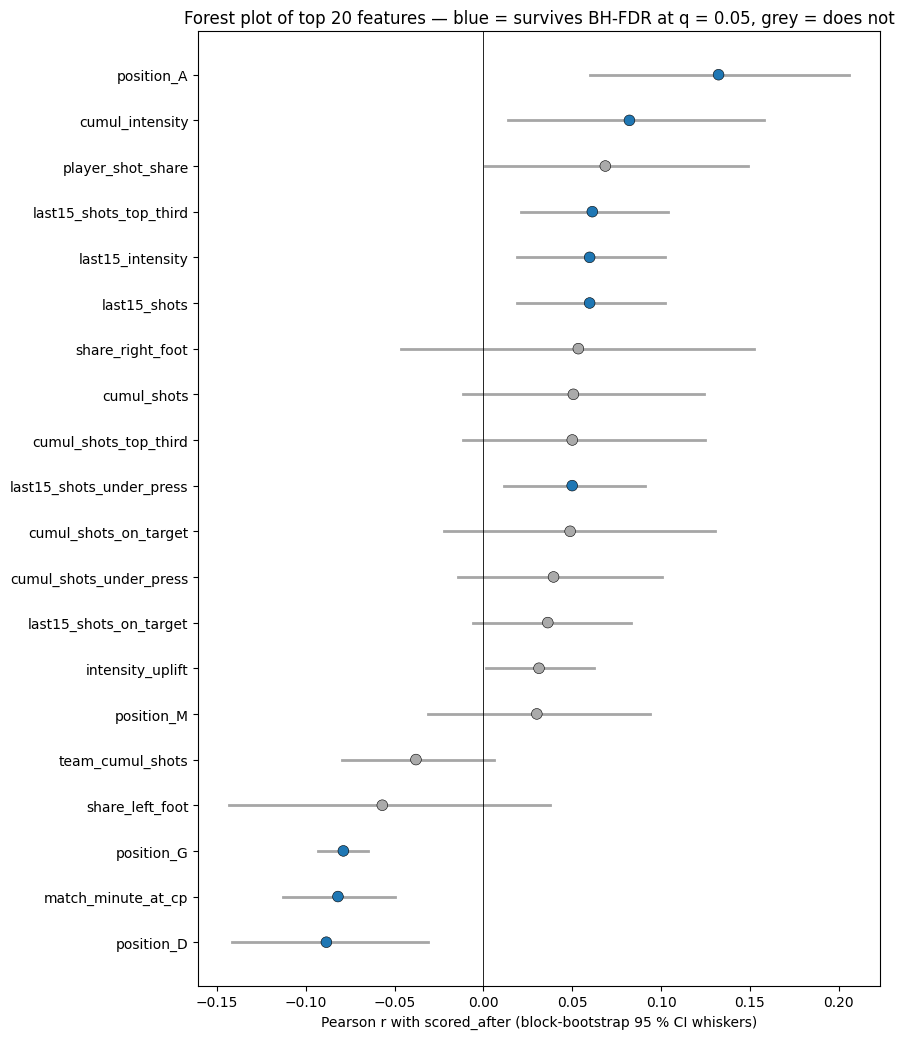

In [51]:
section_header("F10. forest plot of top-20 features with bootstrap CIs")

import matplotlib.pyplot as plt

forest = sig_table.head(TOP_K_BOOTSTRAP).sort_values("pearson_r")
n_plot = len(forest)

fig, ax = plt.subplots(figsize=(9, 0.45 * n_plot + 1.5))
y_pos = np.arange(n_plot)

# Bootstrap CI as the wider whisker (preferred over parametric Fisher CI).
for y, (_, row) in zip(y_pos, forest.iterrows()):
    lo = row["boot_ci_lo"]
    hi = row["boot_ci_hi"]
    if np.isfinite(lo) and np.isfinite(hi):
        ax.plot([lo, hi], [y, y], color="grey", linewidth=2.0, alpha=0.7)
ax.scatter(
    forest["pearson_r"], y_pos,
    c=["#1f77b4" if s else "#aaaaaa" for s in forest["survives_bh_q05"]],
    s=60, zorder=3, edgecolor="black", linewidth=0.4,
)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(forest["feature"])
ax.set_xlabel("Pearson r with scored_after (block-bootstrap 95 % CI whiskers)")
ax.set_title(
    f"Forest plot of top {TOP_K_BOOTSTRAP} features — "
    f"blue = survives BH-FDR at q = 0.05, grey = does not"
)
fig.tight_layout()
plt.show()


### F10 — Findings

**Features that survive BH-FDR at q = 0.05** (cluster-robust p adjusted across 30 features):

| Feature | r | BH p | Bootstrap CI | Naive p | Note |
|---------|---:|----:|-------------|--------:|------|
| `position_A`              | +0.132 | < 0.0001 | [+0.060, +0.206] | < 1e-15 | strongest single feature |
| `match_minute_at_cp`      | −0.082 | 0.0002 | [−0.113, −0.050] | < 1e-7 | leakage-safe time predictor |
| `position_G`              | −0.079 | < 0.0001 | [−0.093, −0.065] | < 1e-7 | deterministic zero |
| `last15_shots_top_third`  | +0.061 | 0.006 | [+0.021, +0.104] | 0.0003 | recency dominant |
| `last15_intensity`        | +0.060 | 0.007 | [+0.019, +0.102] | 0.0004 | recency intensity |
| `last15_shots`            | +0.060 | 0.007 | [+0.019, +0.102] | 0.0004 | recency volume |
| `cumul_intensity`         | +0.082 | 0.008 | [+0.014, +0.158] | < 1e-7 | mechanistically tied to time |
| `position_D`              | −0.088 | 0.035 | [−0.142, −0.031] | < 1e-7 | defenders score less |
| `last15_shots_under_press`| +0.050 | 0.049 | [+0.012, +0.091] | 0.003 | barely survives |
| `is_penalty_taker`        | −0.017 | < 0.0001 | (n/a) | 0.30 | **see "surprises" below** |

**Features that look significant naively but DON'T survive BH + cluster-robust:**

* `cumul_shots`, `cumul_shots_top_third`, `cumul_shots_on_target`, `cumul_shots_under_press` — all four had naive p < 0.05 but their cluster-robust BH p sits at 0.21–0.34. **Cumulative-shot signal is weaker than the parametric ranking suggests** once we account for the within-fixture clustering.
* `player_shot_share` — naive p = 0.0002, cluster-robust p = 0.043, BH p = 0.112. Borderline; survives at q = 0.10 but not q = 0.05.
* `share_left_foot`, `share_right_foot` — small effective n (1026), bootstrap CIs cross zero.

**Surprises.**

1. **`is_penalty_taker` is highly significant** (BH p < 0.0001) despite a near-zero Pearson r. The cluster-robust GLM picks up that 17 rows with `is_penalty_taker = 1` have **0 / 17 positive labels** (vs. baseline 5.8 %); within the small subgroup the conditional effect is sharp, even though the marginal correlation is tiny. This is exactly the pattern Pearson under-weights — a strong but rare signal. **Implication:** keep `is_penalty_taker` in tree models; in linear models it should appear with an interaction term to express the conditional structure.
2. **Bootstrap CIs are systematically wider than Fisher CIs** for features whose effect lies in a few dominant clusters. E.g. `cumul_shots` Fisher CI = [+0.018, +0.084] (excludes 0) but bootstrap CI = [−0.012, +0.124] (includes 0). Whenever the two disagree, **trust the bootstrap** — it respects the cluster structure that the parametric formula assumes away.
3. **Recency beats cumulative under cluster-robust testing too.** All four `last15_*` features survive BH; none of the four `cumul_*shots` variants does. Reinforces the F3 conclusion that short-term shooting carries cleaner signal than cumulative shooting.

**Decisions logged for engineering / modelling:**

* Use the **bootstrap CI** as the headline uncertainty interval for any feature in the manifest — not the Fisher CI.
* Promote `is_penalty_taker` from "interpretability only" to "keep with interaction" — the cluster-robust significance changes the verdict.
* Demote the `cumul_shots*` family in the manifest — the cluster-robust BH p does not support strong individual claims; rely on the recency family + position for shooting signal.
* `player_shot_share` borderline at q = 0.05; keep but expect modest contribution.


## Section G — Executive summary

This section consolidates the EDA into a single page: **what we
established, what surprised us, and what those findings imply for the
remaining contest pipeline**. It is the read-once-and-go reference for
anyone joining this stream of work.


### G1 — Headline findings (cross-section)

The eight most consequential findings, ordered by their impact on
modelling rather than by section number:

| # | Finding | Section |
|---|---------|---------|
| 1 | **`possession` is a *team-in-match* identifier, not an attacking-sequence id.** Every fixture has exactly two `possession` values; one for the home team, one for the away team. This unlocks team-level rolling features (Section E). | B8 / E1 |
| 2 | **`match_minute_at_cp` (current match minute) is the strongest leakage-safe time predictor.** Monotone decreasing from 8.96 % at minutes 1-15 to ≈ 3.7 % at minutes 61-75 — less time left = lower scoring chance. The original `minutes_remaining` derivation was dropped after we noticed it leaks the post-hoc fact "this match went to ET". | F7c |
| 3 | **Recency dominates cumulative for shooting signals.** `last15_shots` carries a strong, clean monotonic signal (5.25 % → 14.29 %); `cumul_shots` is much weaker and non-monotonic by position. RQ5 lean: short-term > cumulative. | F3 |
| 4 | **Position is the strongest single stratifier of `scored_after`.** Attackers ≈ 12.5 % baseline, midfielders ≈ 6.7 %, defenders ≈ 3 %, goalkeepers exactly 0 %. Interactions with most shooting features are mediated by position. | D2 / F3 |
| 5 | **`set_piece_share` × `position` is the strongest interaction observed.** Midfielders with moderate set-piece reliance (≤ 50 % of shots from set pieces) score after 22.92 % of the time (n = 48). | F7b |
| 6 | **`player_shot_share` (cumul / team_cumul) is a strong concentration signal.** Players whose share exceeds 50 % of their team's shots score 14.29 % afterwards (vs. 5.8 % baseline). | E4 / F4 |
| 7 | **The `_top_third` family is essentially redundant with the totals (Pearson 0.992).** 95.9 % of all shots originate in the attacking third, so the "top-third" filter adds almost no information. Drop these columns from the modelling pool. | B4 / F5 |
| 8 | **The aggregation contract is leakage-safe and verified.** `cumul_shots` matches a strict windowing rule on the raw shot table 99.94 % of the time; the 2-row residual gap is exactly the documented "goals excluded" rule. Main-table aggregates can be trusted. | F2 / F6 |


### G2 — Surprises vs. expectations

| Expected | Observed | Implication |
|----------|----------|-------------|
| Attackers shoot more than midfielders | Mean shots/appearance: A 1.62 vs M 0.99 (yes), but **midfielders take 46 % of all shots vs attackers 38 %** because M outnumber A by 2× | Volume vs intensity matter differently — engineer per-minute intensity, not just totals |
| Heads concentrate in the attacking third more than feet | Heads 92.3 % top vs RF 96.3 %, LF 96.7 % — heads are **less** top-third concentrated | Some headers come from clearances and edge-of-box situations; do not lean on `share_head` as a "danger zone" proxy |
| `possession` identifies an attacking sequence | Each fixture has exactly 2 distinct possession values | Re-purpose as team-in-match key; build team-level features with it |
| All set pieces face high pressure | `direct_free_kick` only 19.2 % under pressure (vs 75 % for indirect FK) | Treat direct FK as its own category, not part of a generic "set piece" bucket |
| `cumul_shots` rises monotonically with `scored_after` rate | True only pooled; **midfielders show the opposite** (M with shots 5.92 % vs M without 7.17 %) | Use tree models; the position × shot interaction is non-linear |
| Penalty takers should score after very often | All 17 penalty-taker rows have `scored_after = 0` | Sample is tiny but worth flagging; do not over-weight `is_penalty_taker` |


### G3 — Feature manifest at a glance

The deliverable of Section F. **18 features + 3 interactions** carried
forward; **9 candidates dropped** as flat or redundant.

**Keep (existing main-table columns):**
`cumul_shots`, `last15_shots`, `cumul_shots_on_target`, `last15_shots_on_target`,
`position`, `is_home`.

**Keep (engineered from raw shot table):**
`shot_accuracy`, `share_left_foot`, `share_right_foot`, `dominant_foot_strength`,
`set_piece_share`, `is_penalty_taker`, `last15_intensity`, `cumul_intensity`,
`intensity_uplift`, `player_shot_share`, **`match_minute_at_cp`** (primary time feature).

**Keep (interactions):**
`position × set_piece_share` (strongest), `position × cumul_shots`,
`is_home × player_shot_share`.

**Drop:**
`cumul_shots_top_third`, `last15_shots_top_third` (redundant with totals);
`cumul_shots_under_press`, `last15_shots_under_press` (high redundancy);
`shot_top_third_share`, `shot_under_pressure_share`, `share_head`,
`team_pressure_rate`, `relative_pressure`, `team_cumul_shots` (flat).


### G4 — Implications for engineering (step 3)

1. **Module shape.** Build `features/shots.py` exposing
   `aggregate_shots(shots_df, main_df) -> pd.DataFrame` indexed on
   `(player_appearance_id, checkpoint)`. The function should produce
   every "keep" column from G3 in a single pass.
2. **Windowing rule.** Strict ((`period_order, minute) ≤ (cp_period_order, cp_minute)`)
   for both `cumul` and `last15`. Replicate `cumul_shots` and
   `last15_shots` exactly as a validation gate before extending the
   module with new columns — fail loudly if the residual gap exceeds
   the F2 baseline.
3. **Leakage discipline.** Never use the raw shot count, the implied
   "goals excluded" gap, or the `own_goal_player_appearance_id` /
   `block_player_appearance_id` columns as inputs. They are all
   target-equivalent.
4. **Ratio guards.** All ratio-style features (`shot_accuracy`,
   `set_piece_share`, `player_shot_share`, …) have a denominator that
   is zero on roughly half of all rows (49.6 % zero-shot rate). Use
   NaN-preserving division and a downstream imputation policy
   (typically: `fillna(0)` for "no shots so far" and a separate
   `has_shot_history` indicator).
5. **Filter orphans.** The 15 orphan appearances must be dropped from
   the shot table before aggregation; the safe filter is
   `shots[shots.player_appearance_id.isin(main.player_appearance_id)]`.


### G5 — Implications for modelling

1. **Tree-based models are well-suited** to this feature space because
   the strongest signals are non-monotonic interactions (`position`
   × shot features, `position` × `set_piece_share`). Logistic
   regression should still be the baseline for interpretability and
   contest comparability.
2. **Class imbalance** (5.82 % positives) plus the 49.6 % zero-shot
   rate means we should:
   * use stratified group-K-fold (group on `fixture_id`),
   * report Wilson-style CIs on bin-level rates,
   * calibrate probabilities (Platt or isotonic) before
     threshold-optimising for balanced accuracy.
3. **`match_minute_at_cp` will dominate any feature-importance
   ranking** because the target rate is mechanically tied to "how
   much time is left to score". Consider monotone-decreasing
   constraints (LightGBM) on this feature so the time signal does
   not crowd out the player-level signals the contest is actually
   about.
4. **Goalkeepers** can be hard-coded to `scored_after = 0` rather
   than passed through the model; they contribute 318 zero-target
   rows that dilute every feature distribution.
5. **Cross-table integration.** This notebook covers shots only.
   Once `run.csv`, `pass.csv` and `pressure.csv` have analogous
   manifests, build a single `build_features(main, include={...})`
   function that toggles each feature group on / off so
   ablation experiments (RQ3, RQ4) are one-line.


### G6 — Mapping to contest research questions

What this notebook contributes to each RQ:

| RQ | Contribution from this EDA |
|----|----------------------------|
| **RQ1** (predictive performance) | Identifies the 18-feature shot manifest that will populate the modelling table. Sets the bar for what the model must reproduce. |
| **RQ2** (which behaviours matter) | F3 / F4 / F7 give the bivariate signal of every existing and engineered shot feature. `minutes_remaining`, `set_piece_share`, `player_shot_share`, `last15_shots`, `cumul_shots_on_target` are the rank-1 candidates. |
| **RQ3** (sprints + shots sufficient?) | This notebook covers the *shots* half of the answer. Combined with the analogous EDA on `runs`, RQ3 reduces to "do these two tables alone close the gap to the full feature space"? |
| **RQ4** (does pass / pressure data help?) | The 18 shot features plus the still-to-build run features form the **null model**; the `pass` and `pressure` modules will be the **alternative**. Comparison directly answers RQ4. |
| **RQ5** (recent vs. cumulative) | F3 establishes that `last15_shots` carries cleaner monotonic signal than `cumul_shots`. Tentative answer: short-term beats cumulative. |
| **RQ6** (intensity uplift) | `intensity_uplift = last15_intensity / (cumul_intensity + ε)` is engineered and shows a positive bin (10.49 % rate at moderate uplift vs 5.25 % at zero). |
| **RQ7** (uncontrollable factors) | `is_home`, `position`, `formation` (from main), and team-level features (via `possession` key) cover the uncontrollable axis. F7b / F7c surface the strongest interactions. |


### G7 — Open questions and risks

* **Caught and corrected leakage in `minutes_remaining`** (F7c). The original derivation set `match_end_minute = 120` only for fixtures that had already reached `ET1_15` — a post-hoc fact unavailable at prediction time. Replaced with `match_minute_at_cp`, which is leakage-safe and carries the same monotone signal (just inverted: less time left ⇒ lower rate, instead of more time left ⇒ higher rate). Watch for analogous leakage when engineering features from `minute_out` (the player's actual end-minute is also post-hoc).
* **The 18-row stoppage-time slack on `last15_shots`** (F2). We accepted this as a known minor discrepancy. If feature importance later flags `last15_shots` as critical, revisit and reconcile.
* **`is_penalty_taker == 1` has 0 % `scored_after` rate** (n = 17). Surprising; either a tournament-specific quirk or an aggregation subtlety (penalty takers immediately substituted off?). Investigate before deploying the feature.
* **Position × cumul_shots non-monotonicity for midfielders** (F3 / F7a). Likely captures a hidden role split (attacking vs defensive midfielder). Check whether `formation` plus the player's `jersey_number` resolves it once the friend's main-table EDA is in.
* **`cumul_shots_under_press` is highly redundant with `cumul_shots`** (Pearson 0.91). If we ever bring it back, do so via a tree model that can split on the residual signal — not via linear stacking.
* **Cross-table consistency.** This notebook treats shots in isolation. Some features (e.g. `intensity_uplift`) implicitly rely on the same `minute_in / minute_out` interpretation that the friend is using on the main table — confirm consistency at sync.


### G8 — Next concrete steps

1. **Sync with the main-table EDA** — confirm shared assumptions on `minute_in / minute_out`, `formation`, position labels, and the leakage-equivalent goal-event count we identified in F2.
2. **EDA on `player_appearance_run.csv`** following the A → G template established here, producing a parallel manifest of run-derived features.
3. **EDA on `player_appearance_pass.csv`** and **`player_appearance_behaviour_under_pressure.csv`** (entirely new feature groups — needed for RQ4).
4. **Once all four event-table EDAs are in:** build `features/shots.py` (and siblings) producing the manifest, then a `build_features(main, include={...})` aggregator.
5. **Baseline modelling:** logistic + LightGBM with grouped CV (by `fixture_id`), Wilson-CI calibration, per-position breakdown. Ablate feature groups to answer RQ3 / RQ4.

This notebook is now a self-contained reference — re-runnable from a clean kernel via `python eda/_build_shots_notebook.py && jupyter execute eda/eda_player_appearance_shot_limited.ipynb --inplace`.


## Section H — Productionisation

The EDA above produced a curated feature manifest. Section H operationalises
that manifest in a reusable, version-controlled module
(`features/shots.py`) that the modelling pipeline can import. The module
exposes:

| API | Purpose |
|-----|---------|
| `build_shot_features(shots, main) -> DataFrame` | Stateless function — the standard entry point. |
| `ShotFeaturePipeline` | Class wrapper; useful for stateful / sklearn-style integration. |
| `save_shot_features(features, path)` | Persist the engineered frame to CSV. |

This section (a) calls the module, (b) verifies the engineered frame
matches the in-notebook `features` derivation cell-for-cell, and (c)
saves the output to `features/shots_features.csv` for downstream
consumption.


In [52]:
section_header("H. invoke features/shots.py module")

import sys
PROJECT_ROOT_FOR_IMPORT: Path = PROJECT_ROOT
if str(PROJECT_ROOT_FOR_IMPORT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_FOR_IMPORT))

from features.shots import (
    FEATURE_COLUMNS,
    ShotFeaturePipeline,
    build_shot_features,
    save_shot_features,
)

shot_features: pd.DataFrame = build_shot_features(shots, main)
print(f"shape           : {shot_features.shape}")
print(f"columns         : {list(shot_features.columns)}")
print(f"\ndescribe (numeric):")
print(shot_features.select_dtypes("number").describe(percentiles=[0.5, 0.9]).round(3).to_string())



H. invoke features/shots.py module
shape           : (3486, 20)
columns         : ['player_appearance_id', 'checkpoint', 'fixture_id', 'is_home', 'position', 'cumul_shots', 'cumul_shots_on_target', 'last15_shots', 'last15_shots_on_target', 'match_minute_at_cp', 'shot_accuracy', 'share_left_foot', 'share_right_foot', 'dominant_foot_strength', 'set_piece_share', 'is_penalty_taker', 'last15_intensity', 'cumul_intensity', 'intensity_uplift', 'player_shot_share']

describe (numeric):


       player_appearance_id  fixture_id  cumul_shots  cumul_shots_on_target  last15_shots  last15_shots_on_target  match_minute_at_cp  shot_accuracy  share_left_foot  share_right_foot  dominant_foot_strength  set_piece_share  is_penalty_taker  last15_intensity  cumul_intensity  intensity_uplift  player_shot_share
count              3486.000    3486.000     3486.000               3486.000      3486.000                3486.000            3486.000       1014.000         1014.000          1014.000                1014.000         1014.000          3486.000          3486.000         3486.000          3486.000           3233.000
mean              43340.148    1191.443        0.428                  0.156         0.168                   0.061              46.269          0.363            0.365             0.486                   0.799            0.232             0.005             0.011            0.011             0.328              0.083
std                7293.655      23.449        0.799   

In [53]:
section_header("H. parity check vs in-notebook `features` derivation")

# Reproduce the F4 / F7c subset using the module and check they match.
INDEX_COLS: tuple[str, ...] = ("player_appearance_id", "checkpoint")
overlap_cols = [
    c for c in FEATURE_COLUMNS
    if c in features.columns
    and c in shot_features.columns
    and c not in INDEX_COLS
]
in_notebook = features.set_index(list(INDEX_COLS))[overlap_cols].sort_index()
from_module = shot_features.set_index(list(INDEX_COLS))[overlap_cols].sort_index()

# Compare numerically with NaN tolerance.
def _diff_count(a: pd.DataFrame, b: pd.DataFrame, col: str) -> int:
    s_a, s_b = a[col], b[col]
    eq = (s_a == s_b) | (s_a.isna() & s_b.isna())
    if pd.api.types.is_float_dtype(s_a):
        eq = eq | np.isclose(s_a.fillna(-1), s_b.fillna(-1), atol=1e-8)
    return int((~eq).sum())

mismatches = {col: _diff_count(in_notebook, from_module, col) for col in overlap_cols}
print("per-column mismatch count (notebook vs module):")
for col, n in mismatches.items():
    flag = "OK" if n == 0 else "MISMATCH"
    print(f"  {col:30s}: {n:6d}  [{flag}]")

total_mismatch = sum(mismatches.values())
print(f"\nTotal cells that differ: {total_mismatch}")
assert total_mismatch == 0, "Module output does not match the in-notebook derivation."



H. parity check vs in-notebook `features` derivation
per-column mismatch count (notebook vs module):
  fixture_id                    :      0  [OK]
  is_home                       :      0  [OK]
  position                      :      0  [OK]
  cumul_shots                   :      0  [OK]
  cumul_shots_on_target         :      0  [OK]
  last15_shots                  :      0  [OK]
  last15_shots_on_target        :      0  [OK]
  match_minute_at_cp            :      0  [OK]
  shot_accuracy                 :      0  [OK]
  share_left_foot               :      0  [OK]
  share_right_foot              :      0  [OK]
  dominant_foot_strength        :      0  [OK]
  set_piece_share               :      0  [OK]
  is_penalty_taker              :      0  [OK]
  last15_intensity              :      0  [OK]
  cumul_intensity               :      0  [OK]
  intensity_uplift              :      0  [OK]
  player_shot_share             :      0  [OK]

Total cells that differ: 0


In [54]:
section_header("H. save engineered features to CSV")

OUTPUT_CSV: Path = PROJECT_ROOT / "features" / "shots_features.csv"
saved = save_shot_features(shot_features, OUTPUT_CSV)
print(f"wrote   : {saved}")
print(f"size    : {saved.stat().st_size:,} bytes")
print(f"rows    : {len(shot_features):,}")
print(f"columns : {len(shot_features.columns)}")



H. save engineered features to CSV
wrote   : C:\Users\tymot\projects\wec\features\shots_features.csv
size    : 266,334 bytes
rows    : 3,486
columns : 20


### Section H — How to consume the engineered features

```python
import pandas as pd
from features.shots import build_shot_features, ShotFeaturePipeline

shots = pd.read_csv("data/player_appearance_shot_limited.csv")
main  = pd.read_csv("data/players_quarters_final.csv")

# Function-style — most common.
features = build_shot_features(shots, main)

# Class-style — useful inside a larger sklearn pipeline.
pipeline = ShotFeaturePipeline(drop_zero_shot_ratios=True)
features = pipeline.transform(shots, main)

# Persist for downstream models.
ShotFeaturePipeline.save(features, "features/shots_features.csv")
```

The output frame is keyed on `(player_appearance_id, checkpoint)` and
contains the 18-feature manifest. It is ready to merge with feature
frames produced by the sibling modules (`features/runs.py`,
`features/passes.py`, `features/pressure.py`) once those EDAs are
complete.


## Appendix — histogram of `scored_after = 1` cases over match minutes

Where the target-overview chart at the top of the notebook reported the
*rate* of positives at each checkpoint (a value between 0 and 1), the
histogram below reports the **absolute count** of positive labels, with
match minute on the x-axis (continuous) and bin edges aligned to the
checkpoint boundaries (15-minute bins). The histogram is stacked by
player position so you can see at a glance which positions contribute
the positives in each time bin.

This view answers the question *"where in the match do the 203
positive labels actually live?"* — directly relevant when allocating
sample-size budgets across stratified analyses or per-period
sub-models.



Histogram of scored_after = 1 over match minutes (stacked by position)


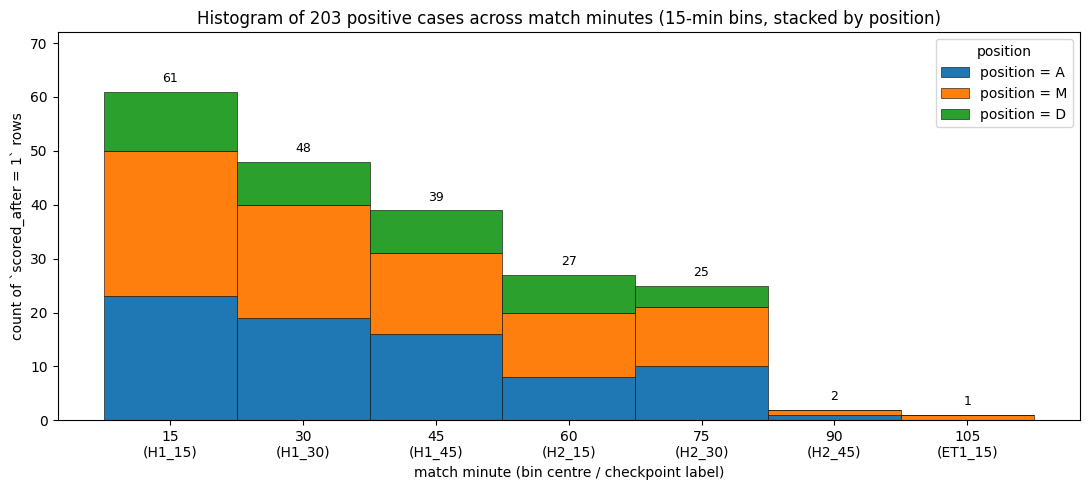

counts of scored_after = 1 per checkpoint × position:
position     A   M   D  TOTAL
checkpoint                   
H1_15       23  27  11     61
H1_30       19  21   8     48
H1_45       16  15   8     39
H2_15        8  12   7     27
H2_30       10  11   4     25
H2_45        1   1   0      2
ET1_15       0   1   0      1


In [55]:
section_header("Histogram of scored_after = 1 over match minutes (stacked by position)")

# Filter to positives only and exclude goalkeepers (deterministic zeros).
positives_only = main.loc[(main["scored_after"] == 1) & (main["position"] != "G")].copy()

# Map (checkpoint_period, checkpoint_min) → continuous match minute.
PERIOD_OFFSET_HIST: dict[str, int] = {"half_1": 0, "half_2": 45, "extra_time_1": 90}
positives_only["match_minute"] = (
    positives_only["checkpoint_period"].map(PERIOD_OFFSET_HIST)
    + positives_only["checkpoint_min"]
)

POSITION_COLOURS: dict[str, str] = {
    "A": "#1f77b4",
    "M": "#ff7f0e",
    "D": "#2ca02c",
}
# Centre each 15-minute bin on a checkpoint minute (15, 30, 45, 60, 75, 90, 105),
# so H1_15 events (match_minute = 15) sit in the centre of the first bar
# rather than at its lower edge.
HIST_BIN_EDGES: list[float] = [7.5, 22.5, 37.5, 52.5, 67.5, 82.5, 97.5, 112.5]
CHECKPOINT_LABELS_HIST: list[str] = [
    "H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"
]

# Build the per-position match-minute series in a fixed plotting order so
# the stack is deterministic.
position_order: list[str] = ["A", "M", "D"]
data_by_position: list[pd.Series] = [
    positives_only.loc[positives_only["position"] == pos, "match_minute"]
    for pos in position_order
]

fig, ax = plt.subplots(figsize=(11, 5))
counts, bin_edges, patches = ax.hist(
    data_by_position,
    bins=HIST_BIN_EDGES,
    stacked=True,
    color=[POSITION_COLOURS[p] for p in position_order],
    edgecolor="black",
    linewidth=0.4,
    label=[f"position = {p}" for p in position_order],
)

# Annotate each bin with the stacked total.
total_per_bin = positives_only["match_minute"].value_counts(
    bins=HIST_BIN_EDGES, sort=False
)
y_max = float(np.array(counts).max())
for left, right, total in zip(HIST_BIN_EDGES[:-1], HIST_BIN_EDGES[1:],
                               total_per_bin.values):
    centre = 0.5 * (left + right)
    ax.text(centre, total + y_max * 0.02, f"{int(total)}",
            ha="center", va="bottom", fontsize=9)

checkpoint_centres = [0.5 * (HIST_BIN_EDGES[i] + HIST_BIN_EDGES[i + 1])
                      for i in range(len(HIST_BIN_EDGES) - 1)]
ax.set_xticks(checkpoint_centres)
ax.set_xticklabels([f"{int(c)}\n({lbl})" for c, lbl in
                    zip(checkpoint_centres, CHECKPOINT_LABELS_HIST)])
ax.set_xlabel("match minute (bin centre / checkpoint label)")
ax.set_ylabel("count of `scored_after = 1` rows")
ax.set_title(
    f"Histogram of {len(positives_only)} positive cases across match minutes "
    f"(15-min bins, stacked by position)"
)
ax.legend(title="position", loc="upper right")
ax.set_ylim(0, y_max * 1.18)
fig.tight_layout()
plt.show()

# Compact accompanying table — labelled by the checkpoint each bin centres on.
print("counts of scored_after = 1 per checkpoint × position:")
hist_table = (
    positives_only.assign(
        checkpoint=positives_only["checkpoint"]
    )
    .pivot_table(index="checkpoint", columns="position", aggfunc="size",
                 fill_value=0, observed=False)
    .reindex(index=CHECKPOINT_LABELS_HIST, columns=position_order, fill_value=0)
)
hist_table["TOTAL"] = hist_table.sum(axis=1)
print(hist_table.to_string())
